# Fraud Detection & Risk Analysis

Notebook principal do projeto, reunindo preparação de dados, engenharia de features, regras de negócio, modelo de anomalias, validação analítica e exportação operacional.

O objetivo é disponibilizar um pipeline auditável e reutilizável para priorização de transações suspeitas, combinando sinais interpretáveis de negócio com deteção estatística de anomalias.

## 0. Guia de Utilização

Este notebook foi desenhado para documentar e executar, de forma reprodutível, o pipeline de deteção de fraude. A execução completa deve ser feita sequencialmente, de cima para baixo, garantindo que os dados são carregados, transformados, pontuados e exportados pela ordem correta.

### Modos de Execução

- `mode: 'test'`: modo analítico, recomendado para validação, calibração, backtesting e geração de outputs de análise.
- `mode: 'production'` no notebook: reservado para inspeção manual ou debug pontual.
- Produção operacional: deve ser executada através do script `production/run_production.py`, evitando correr manualmente o notebook em ambiente recorrente.

### Execução em Produção

Para execução recorrente, utilizar o script dedicado no terminal

### Opções úteis do Script

- `--ignore-last-run`: ignora o ficheiro `last_run.json` e simula uma primeira execução.
- `--first-run-hours N`: define quantas horas para trás devem ser consideradas numa primeira execução.
- `--window-days N`: altera a janela de contexto carregada para recalcular features históricas.
- `--dashboard-window-days N`: define a janela temporal exportada para o separador de dashboard no Google Sheets.

### Fluxo Produção + Feedback

1. **Modo teste (`CONFIG['mode']='test'`)**: usar para validação, calibração e geração dos artefactos em `production/`. Neste modo, o notebook lê por defeito as decisões reais do separador `fraud_review` e ajusta pesos antes de guardar novos artefactos.
2. **Produção operacional**: correr pelo terminal com `py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb"`. A produção usa os artefactos existentes, exporta dashboard/review/history e sincroniza decisões, mas não ajusta pesos nem treina o modelo.
3. **Revisão manual**: preencher no Google Sheets, separador `fraud_review`, a coluna `decision` com `fraude_confirmada`, `falso_positivo` ou `inconclusivo`.
4. **Teste rápido do feedback**: usar `py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb" --sync-review-only` para confirmar que as decisões foram lidas e guardadas em `production/review_decisions_store/`.
5. **Review de teste**: só é lida se for pedido explicitamente com `review_source='test'`; por defeito, o feedback vem sempre de `fraud_review`.

Ver tambem a seccao **22. Guia Operacional do Feedback Loop** no fim do notebook para o passo a passo completo.


## 1. Configuração

Todos os parâmetros relevantes do sistema estão centralizados no dicionário `CONFIG`: caminhos de ficheiros, thresholds, pesos das regras, parâmetros do modelo, modo de execução e opções de exportação.

Esta organização facilita a manutenção do pipeline, melhora a reprodutibilidade e evita alterações dispersas ao longo do notebook.




In [1]:
import copy as _copy 
import io 
import json as _json 
import os 
import pickle 
import re 
import smtplib 
import subprocess 
import sys 
import time 
import warnings 
import joblib 

import numpy as np 
import pandas as pd 
import pyarrow .parquet as pq 
import seaborn as sns 

from email import encoders 
from email .mime .base import MIMEBase 
from email .mime .multipart import MIMEMultipart 
from email .mime .text import MIMEText 

from google .auth .credentials import Credentials 
from google .auth .transport .requests import Request 
from google_auth_oauthlib .flow import InstalledAppFlow 

import matplotlib .pyplot as plt 
import matplotlib .ticker as mticker 
from matplotlib .lines import Line2D 
from matplotlib .patches import Patch 

from sklearn .ensemble import IsolationForest 
from sklearn .exceptions import InconsistentVersionWarning 
from sklearn .metrics import precision_recall_curve ,precision_score ,recall_score ,f1_score ,confusion_matrix ,auc 
from sklearn .pipeline import Pipeline 
from sklearn .preprocessing import RobustScaler 


In [2]:

warnings .filterwarnings ('ignore',category =FutureWarning )
warnings .filterwarnings ('ignore',category =pd .errors .PerformanceWarning )

pd .set_option ('display.max_columns',60 )
pd .set_option ('display.float_format','{:.3f}'.format )

plt .rcParams .update ({
'figure.facecolor':'white',
'axes.facecolor':'white',
'axes.grid':True ,
'grid.alpha':0.3 ,
'axes.spines.top':False ,
'axes.spines.right':False ,
'font.size':10 ,
})
warnings .filterwarnings ('ignore',category =InconsistentVersionWarning )




In [ ]:
# Configuração central
BASE_DIR =os .path .abspath (os .getcwd ())
KK_FILES_DIR =os .path .normpath (os .path .join (BASE_DIR ,'..','KK Files'))
ANALYSIS_DIR =os .path .normpath (os .path .join (BASE_DIR ,'analysis_charts'))
PRODUCTION_DIR =os .path .normpath (os .path .join (BASE_DIR ,'production'))

CONFIG ={
'paths':{
'orders':os .path .join (KK_FILES_DIR ,'analytics_marketplace_by_user_2025_secs.parquet'),
'content':os .path .join (KK_FILES_DIR ,'analytics_conteudos.parquet'),
'offers':os .path .join (KK_FILES_DIR ,'marketplace_ofertas.parquet'),
},

'rules':{
'new_account_days':2 ,
'recent_account_days':7 ,
'amount_vs_avg':5.0 ,
'amount_zscore':3.0 ,
'payment_failures_7d':10 ,
'payment_failures_3d':15 ,
'payment_failures_24h':8 ,
'multi_payment_count':4 ,
'orders_24h':5 ,
'min_merchant_orders_cancel':20 ,
},

'rule_weights':{
'rule_new_account_guest_highval':25 ,
'rule_new_account_freq_failures':15 ,
'rule_freq_guest_highval':25 ,
'rule_freq_highval_new_account':15 ,
'rule_unusual_amount_zscore':10 ,
'rule_payment_failures_24h':25 ,
'rule_payment_failures_30d':7 ,
'rule_multi_payment_window':8 ,
'rule_new_payment_method_highval':10 ,
'rule_amount_above_prev_max':20 ,
'rule_first_order_new_category_highval':20 ,
'rule_unusual_amount_category':12 ,
'rule_above_cohort_p95_highval':12 ,
'rule_mp_new_account_highval':28 ,
'rule_mp_all_items_highval':20 ,
'rule_cart_price_manipulation':30 ,
'rule_cart_stock_exceeded':10 ,
'rule_bulk_highval':15 ,
'rule_name_mismatch_mp_highval':20 ,
'rule_name_mismatch_new_account_highval':6 ,
'rule_seller_cancellations':18 ,
'rule_mp_low_commission_highval':23 ,
'rule_bnpl_new_account':23 ,
'rule_card_testing':23 ,
'rule_multi_merchant_24h':20 ,
'rule_merchant_high_cancel_rate_burst':6 ,
'rule_user_merchant_concentration':15 ,
'rule_shared_delivery_address':12 ,
'rule_retry_fast':32 ,
'rule_burst_orders_2min':22 ,
'rule_bot_round_time':15 ,
'rule_bot_velocity':35 ,
'rule_bot_multi_merchant_fast':30 ,
},

'scoring':{
'w_rules':0.50 ,
'w_ml':0.50 ,
'loyalty_cutoff':10 ,
'loyalty_max_discount':0.30 ,
'loyalty_scale':20 ,
'loyalty_max_orders_per_week':3 ,
},

'iforest':{
'n_estimators':200 ,
'contamination':0.02 ,
'random_state':42 ,
},

'temporal_split_month':'2025-09',
'validation_split_month':'2025-09',
'final_test_month':'2025-12',
'proxy_label_col':'hard_block_rule',
'save_figures':True ,
'output_prefix':os .path .join (ANALYSIS_DIR ,'kk_fraude'),
'lookback_window_days':90 ,
'mode':'test',
'production_reference_time_mode':'dataset_max',

'email':{
'enabled':True ,
'smtp_host':'smtp.gmail.com',
'smtp_port':587 ,
'sender':'YOUR_EMAIL@example.com',
'password':'YOUR_EMAIL_APP_PASSWORD',
'recipient':'YOUR_EMAIL@example.com',
},
'production_dir':PRODUCTION_DIR ,
}

RISK_LEVELS =['Baixo','Moderado','Alto','Crítico']

RISK_COLORS ={
'Baixo':'#f4a7b9',
'Moderado':'#e8637a',
'Alto':'#c0253d',
'Crítico':'#7d0a1e',
}

ACTION_MAP ={
'Baixo':'Aprovação Automatica',
'Moderado':'Monitorização',
'Alto':'Revisão Manual',
'Crítico':'Bloqueio Automático',
}

RULE_LABELS ={
'rule_new_account_guest_highval':'Conta recente + guest + alto valor',
'rule_new_account_freq_failures':'Conta recente + frequência + falhas',
'rule_freq_guest_highval':'Frequência elevada + guest + alto valor',
'rule_freq_highval_new_account':'Frequência elevada + alto valor + conta recente',
'rule_unusual_amount_zscore':'Desvio elevado do padrão pessoal',
'rule_payment_failures_24h':'Falhas de pagamento nas últimas 24h',
'rule_payment_failures_30d':'Falhas de pagamento nos últimos 30 dias',
'rule_multi_payment_window':'Múltiplos métodos de pagamento em 24h',
'rule_new_payment_method_highval':'Método de pagamento novo + alto valor',
'rule_unusual_amount_category':'Valor anómalo face à categoria',
'rule_above_cohort_p95_highval':'Acima do p95 do cohort + alto valor',
'rule_amount_above_prev_max':'Valor muito acima do máximo histórico',
'rule_first_order_new_category_highval':'Primeira compra + categoria nova + alto valor',
'rule_first_order_new_store_highval':'Primeira compra + merchant novo + alto valor',
'rule_mp_new_account_highval':'Conta recente + marketplace + alto valor',
'rule_mp_all_items_highval':'Todos os items MP + alto valor',
'rule_cart_price_manipulation':'Preco do carrinho alterado',
'rule_cart_stock_exceeded':'Stock excedido no carrinho',
'rule_bulk_highval':'Quantidade elevada + alto valor',
'rule_name_mismatch_mp_highval':'Nome entrega diferente + MP + alto valor',
'rule_name_mismatch_new_account_highval':'Nome entrega diferente + conta recente + alto valor',
'rule_seller_cancellations':'Seller com histórico de cancelamentos',
'rule_mp_low_commission_highval':'Comissão MP anormalmente baixa + alto valor',
'rule_bnpl_new_account':'BNPL em conta recente',
'rule_retry_fast':'Retry bot: falha + nova ordem <60s',
'rule_card_testing':'Card testing: ordem mínima + alto valor <3min',
'rule_bot_velocity':'Velocidade bot: ordem <30s + conta nova',
'rule_bot_multi_merchant_fast':'Carding: multi-merchant <10min',
'rule_dormant_reactivation':'Conta dormida reativada',
'rule_multi_merchant_24h':'Múltiplos merchants em 24h',
'rule_new_merchant_high_volume':'Merchant novo com volume alto no primeiro dia',
'rule_merchant_high_cancel_rate_burst':'Merchant com alta taxa de cancelamento + burst 24h',
'rule_user_merchant_concentration':'Utilizador concentrado num único merchant',
'rule_shared_delivery_address':'Endereco de entrega partilhado por vários utilizadores',
}

# Garantir pastas de saída
os .makedirs (ANALYSIS_DIR ,exist_ok =True )
os .makedirs (PRODUCTION_DIR ,exist_ok =True )

DASHBOARD_COLS =[
'id_order_seller','createdAt','year_month',
'customer_on_purchase_userId',
'total_amount','payment_method_method','order_status',
'rules_score','rules_triggered_count','triggered_rules',
'ml_anomaly_score','ml_is_anomaly',
'risk_score','risk_level','recommended_action','hard_block_rule',
]



## 2. Funções Auxiliares

Nesta secção são definidas as funções de suporte utilizadas ao longo do pipeline, incluindo carregamento de dados, inspeção exploratória, utilitários de formatação e rotinas de apoio a exportação.

O objetivo é manter a lógica principal mais legível e reutilizável.




In [4]:
def load_data (config ,lookback_days =None ):

#Colunas necessarias para o modelo
    ORDERS_COLS =[
    'id_order_seller','order_id','createdAt','year_month','year',
    'order_status','is_paid',
    'billing_address_country','billing_address_city','billing_address_zip_code',
    'delivery_address_country','delivery_address_city','delivery_address_zip_code',
    'products_price','shippings_price','total_amount',
    'payment_method_method','customer_on_purchase_userId',
    'customer_on_purchase_isGuest','customer_on_purchase_email',
    'cancel_date','product_id','store_id','store_name',
    'model','categoria_pai','categoria_filha',
    'user_created_at',
    ]

    def read_file (path ,cols =None ):
        if path .endswith ('.parquet'):
            table =pq .read_table (path ,columns =cols )
            return table .to_pandas (ignore_metadata =True )
        elif path .endswith ('.csv'):
            return pd .read_csv (path ,usecols =cols )
        else :
            return pd .read_excel (path ,usecols =cols )

    paths =config ['paths']
    df_orders =read_file (paths ['orders'])
    df_content =read_file (paths ['content'])
    df_offers =read_file (paths ['offers'])

    #Filtro de janela temporal
    if lookback_days is not None :
        df_orders ['createdAt']=pd .to_datetime (df_orders ['createdAt'],utc =True ,errors ='coerce')
        before =len (df_orders )
        has_dates =df_orders ['createdAt'].notna ().any ()

        use_dataset_max_anchor =(
        config .get ('mode')=='production'
        and config .get ('production_reference_time_mode')=='dataset_max'
        and has_dates 
        )

        if use_dataset_max_anchor :
            reference_ts =df_orders ['createdAt'].max ()
            print (f'[PRODUCTION] Janela temporal ancorada na última data do ficheiro: {reference_ts }')
        else :
            reference_ts =pd .Timestamp .now (tz ='UTC')

        cutoff =reference_ts -pd .Timedelta (days =lookback_days )
        df_window =df_orders [df_orders ['createdAt']>=cutoff ].copy ()

        if len (df_window )==0 and has_dates and not use_dataset_max_anchor :
            anchor_ts =df_orders ['createdAt'].max ()
            cutoff =anchor_ts -pd .Timedelta (days =lookback_days )
            df_window =df_orders [df_orders ['createdAt']>=cutoff ].copy ()
            print (f'Janela de {lookback_days }d sem dados face a agora; a usar âncora no max createdAt ({anchor_ts }).')

        df_orders =df_window 
        print (f'Janela de {lookback_days }d: {before :,} -> {len (df_orders ):,} encomendas')

    print (f'Orders: {df_orders .shape [0 ]:>10,} linhas  x  {df_orders .shape [1 ]} colunas')
    print (f'Content: {df_content .shape [0 ]:>10,} linhas  x  {df_content .shape [1 ]} colunas')
    print (f'Offers: {df_offers .shape [0 ]:>10,} linhas  x  {df_offers .shape [1 ]} colunas')

    return df_orders ,df_content ,df_offers 


In [5]:
def inspect (df ,name ):
    print (f'Dataset: {name }  |  {df .shape [0 ]:,} linhas  x  {df .shape [1 ]} colunas')

    summary =pd .DataFrame ({
    'dtype':df .dtypes ,
    'nulos':df .isnull ().sum (),
    'nulos_%':(df .isnull ().mean ()*100 ).round (1 ),
    'unicos':df .nunique (),})

    display (summary )


> **Nota sobre fontes opcionais**
>
> `df_content` e `df_offers` funcionam como fontes de enriquecimento ao nível do produto e da oferta. Quando não estão disponíveis, o pipeline continua funcional com base na informação principal das encomendas.




## 3. Pré-processamento

O pré-processamento assegura a limpeza e normalização dos dados em bruto, incluindo tipos de dados, valores em falta, derivação de campos base e criação de chaves de ligação entre tabelas.

Esta etapa estabelece uma base consistente para a construção de features e reduz o risco de propagação de erros para fases posteriores.




In [6]:
def preprocess_orders (df ):
    df =df .copy ()

    # Datas
    date_cols =['createdAt','user_created_at','delivered_date','cancel_date']
    for col in date_cols :
        if col in df .columns :
            df [col ]=pd .to_datetime (df [col ],errors ='coerce',utc =True )

            # Bools
    bool_map ={
    True :1 ,
    False :0 ,
    1 :1 ,
    0 :0 ,
    'TRUE':1 ,
    'FALSE':0 ,
    'true':1 ,
    'false':0 ,
    'True':1 ,
    'False':0 ,
    }

    for col in ['is_paid','customer_on_purchase_isGuest']:
        if col in df .columns :
            df [col ]=df [col ].map (bool_map ).fillna (0 ).astype (int )

            # Numéricos
    for col in ['total_amount','products_price','shippings_price','commission_amount','commission_rate','store_amount']:
        if col in df .columns :
            df [col ]=pd .to_numeric (df [col ],errors ='coerce')

            # Geo
    geo_cols =[
    'billing_address_country','delivery_address_country',
    'billing_address_city','delivery_address_city',
    'billing_address_zip_code','delivery_address_zip_code',
    ]

    for col in geo_cols :
        if col in df .columns :
            df [col ]=(df [col ].astype (str ).str .strip ().str .upper ().replace ({'NAN':np .nan ,'':np .nan ,'NONE':np .nan }))

            # failed = falha técnica, success = ordem bem sucedida
    if 'order_status'in df .columns :
        df ['is_failure']=(df ['order_status']=='failed').astype (int )
        df ['is_success']=(df ['order_status']=='success').astype (int )
    else :
        df ['is_failure']=0 
        df ['is_success']=1 

        # Threshold de alto valor 
    p90 =df ['total_amount'].quantile (0.90 )
    df ['is_high_value_order']=(df ['total_amount']>p90 ).astype (int )

    # Chave de identidade com fallback para guests
    df ['user_key']=df ['customer_on_purchase_userId'].astype (str )
    mask_missing =df ['customer_on_purchase_userId'].isna ()
    df .loc [mask_missing ,'user_key']=('guest_'+df .loc [mask_missing ,'customer_on_purchase_email'].fillna ('unknown').astype (str ))

    # Ordenação cronológica por utilizador 
    df =df .sort_values (['user_key','createdAt'],na_position ='last').reset_index (drop =True )

    print (f'Pré-processamento concluído.  Shape: {df .shape }')
    print (f'Período: {df ["createdAt"].min ()}  a  {df ["createdAt"].max ()}')
    print (f'Threshold de alto valor (p90): {p90 :.2f} EUR')
    print (f'Orders success: {df ["is_success"].sum ():,}  |  Orders failed: {df ["is_failure"].sum ():,}')
    return df 

In [7]:
def split_full_vs_window (df ,config ):
    """
    df_full: todos os dados, para calcular features acumuladas
    df_window: apenas os últimos N dias, para window features
    """
    lookback_days =config .get ('lookback_window_days',90 )

    max_date =df ['createdAt'].max ()
    cutoff_date =max_date -pd .Timedelta (days =lookback_days )

    df_full =df .copy ()
    df_window =df [df ['createdAt']>=cutoff_date ].copy ()

    print (f'Data mais recente: {max_date .date ()}')
    print (f'Cutoff janela ({lookback_days }d): {cutoff_date .date ()}')
    print (f'Dataset completo: {len (df_full ):,} ordens')
    print (f'Dataset janela: {len (df_window ):,} ordens' f'({len (df_window )/len (df_full )*100 :.1f}% do total)')

    return df_full ,df_window 


## 4. Feature Engineering

A engenharia de features traduz o comportamento transacional em variáveis analíticas úteis para deteção de fraude. As features encontram-se organizadas em blocos funcionais, como tempo, histórico, frequência, merchant, carrinho e sinais de identidade.

Esta estrutura permite combinar sinais explícitos com padrões mais subtis de risco e anomalia.




In [8]:
def add_temporal_features (df ):
    """
    Features de data e hora da transação.
    
    """

    df =df .copy ()
    df ['order_hour']=df ['createdAt'].dt .hour 
    df ['order_weekday']=df ['createdAt'].dt .dayofweek 
    df ['is_night_order']=((df ['order_hour']>=0 )&(df ['order_hour']<6 )).astype (int )
    df ['is_weekend']=(df ['order_weekday']>=5 ).astype (int )

    #Features de segundo/minuto
    if df ['createdAt'].dt .second .max ()>0 :
        df ['order_second']=df ['createdAt'].dt .second 
        df ['order_minute']=df ['createdAt'].dt .minute 

        #Segundo redondo
        df ['is_round_second']=df ['order_second'].isin ([0 ,30 ]).astype (int )

        #Segundos desde a ordem anterior do mesmo utilizador
        _prev_ts =df .groupby ('user_key')['createdAt'].shift (1 )
        df ['seconds_since_prev_order']=((df ['createdAt']-_prev_ts ).dt .total_seconds ()).clip (lower =0 ).fillna (9999 )

    else :
        df ['order_second']=0 
        df ['order_minute']=0 
        df ['is_round_second']=0 
        df ['seconds_since_prev_order']=9999 

    return df 

In [9]:
def add_identity_features (df ):
    """
    Features de identidade: email, guest, idade da conta.
    
    """

    df =df .copy ()

    SUSPICIOUS_DOMAINS =[
    'tempmail','mailinator','guerrillamail','throwam','yopmail',
    'trashmail','fakeinbox','sharklasers','maildrop','10minutemail',
    'disposablemail','temp-mail','tmpmail','dispostable','mailnull',
    'getairmail','filzmail','throwam','spamgourmet',]


    def email_pattern_score (email ):
        """
        score de 0-1 para detetar emails gerados automaticamente.
        
        """

        if pd .isna (email )or '@'not in str (email ):return 0.5 

        prefix =str (email ).split ('@')[0 ].lower ()
        prefix =prefix .replace ('*','')

        if len (prefix )==0 :return 0.5 

        score =0.0 
        if sum (c .isdigit ()for c in prefix )/len (prefix )>0.4 :score +=0.35 
        if re .search (r'[a-z]{2,}\d{3,}',prefix ):score +=0.25 
        if len (prefix )<4 :score +=0.20 
        if len (set (prefix ))/len (prefix )<0.5 :score +=0.20 

        return min (score ,1.0 )

    if 'user_created_at'in df .columns :
        df ['account_age_days']=(df ['createdAt']-df ['user_created_at']).dt .days .clip (lower =0 )

    else :
        df ['account_age_days']=np .nan 

    df ['is_guest']=df .get ('customer_on_purchase_isGuest',pd .Series (0 ,index =df .index ))

    if 'customer_on_purchase_email'in df .columns :
        emails =df ['customer_on_purchase_email'].astype (str )

        df ['email_domain']=emails .str .extract (r'@([\w\.\-]+)')

        pattern ='|'.join (SUSPICIOUS_DOMAINS )

        df ['suspicious_email_domain']=(df ['email_domain'].str .contains (pattern ,case =False ,na =False )).astype (int )
        df ['email_pattern_score']=emails .apply (email_pattern_score )
        df ['is_apple_relay']=(df ['email_domain'].str .contains ('privaterelay.appleid',na =False )).astype (int )
    else :
        df ['suspicious_email_domain']=0 
        df ['email_pattern_score']=0.5 
        df ['is_apple_relay']=0 

    return df 


In [10]:
def add_geo_features (df ):
    """
    Inconsistencias geograficas billing vs delivery.
    Nulos são tratados como ausência de informação

    """
    df =df .copy ()

    bill_c =df .get ('billing_address_country')
    dlvr_c =df .get ('delivery_address_country')
    bill_z =df .get ('billing_address_zip_code')
    dlvr_z =df .get ('delivery_address_zip_code')
    bill_city =df .get ('billing_address_city')
    dlvr_city =df .get ('delivery_address_city')

    if bill_c is not None and dlvr_c is not None :
        df ['missing_country_info']=(bill_c .isna ()|dlvr_c .isna ()).astype (int )
        df ['billing_shipping_match_country']=np .where (df ['missing_country_info']==1 ,np .nan ,(bill_c ==dlvr_c ).astype (float ))
        df ['cross_border_order']=np .where (df ['missing_country_info']==1 ,np .nan ,(bill_c !=dlvr_c ).astype (float ))
    else :
        df ['missing_country_info']=1 
        df ['billing_shipping_match_country']=np .nan 
        df ['cross_border_order']=np .nan 

    if bill_city is not None and dlvr_city is not None :
        df ['missing_city_info']=(bill_city .isna ()|dlvr_city .isna ()).astype (int )
        df ['billing_shipping_match_city']=np .where (df ['missing_city_info']==1 ,np .nan ,(bill_city ==dlvr_city ).astype (float ))
    else :
        df ['missing_city_info']=1 
        df ['billing_shipping_match_city']=np .nan 

    if bill_z is not None and dlvr_z is not None :
        df ['billing_shipping_match_zip']=np .where ((bill_z .isna ()|dlvr_z .isna ()),np .nan ,(bill_z ==dlvr_z ).astype (float ))
    else :
        df ['billing_shipping_match_zip']=np .nan 

    return df 


In [11]:
def add_historical_features (df ):

    df =df .sort_values (['user_key','createdAt']).copy ()

    if df .empty :
        empty_defaults ={
        'prev_total_orders':0 ,
        'prev_total_spend':0.0 ,
        'prev_avg_order_amount':0.0 ,
        'prev_std_order_amount':0.0 ,
        'prev_payment_failure_count':0 ,
        'prev_failure_rate':0.0 ,
        'prev_unique_payment_methods':0 ,
        'is_new_payment_method':0 ,
        'is_new_store':0 ,
        'prev_order_date':pd .NaT ,
        'hours_since_prev_order':np .nan ,
        'is_first_order':0 ,
        'prev_failures_1d':0 ,
        'prev_failures_3d':0 ,
        'prev_failures_7d':0 ,
        'prev_failures_30d':0 ,
        'prev_payment_methods_30d':0 ,
        'prev_payment_methods_24h':0 ,
        'amount_zscore_user':0.0 ,
        'order_amount_vs_avg':1.0 ,
        }
        for k ,v in empty_defaults .items ():
            df [k ]=v 
        return df 

        #Contagem de ordens anteriores
    df ['prev_total_orders']=df .groupby ('user_key').cumcount ()

    #Acumulados históricos
    df ['prev_total_spend']=df .groupby ('user_key')['total_amount'].transform (lambda s :s .cumsum ()-s )
    df ['prev_avg_order_amount']=df .groupby ('user_key')['total_amount'].transform (lambda s :s .expanding ().mean ().shift (1 ))
    df ['prev_std_order_amount']=df .groupby ('user_key')['total_amount'].transform (lambda s :s .expanding ().std ().shift (1 ))

    #Falhas acumuladas
    df ['prev_payment_failure_count']=df .groupby ('user_key')['is_failure'].transform (lambda s :s .cumsum ()-s )
    df ['prev_failure_rate']=(df ['prev_payment_failure_count']/df ['prev_total_orders'].replace (0 ,np .nan )).fillna (0 )

    #Métodos de pagamento
    if 'payment_method_method'in df .columns :
        df ['_pm_first']=df .groupby (['user_key','payment_method_method'])['createdAt'].transform ('min')
        df ['is_new_payment_method']=(df ['createdAt']==df ['_pm_first']).astype (int )
        df .loc [df ['prev_total_orders']==0 ,'is_new_payment_method']=0 
        df ['prev_unique_payment_methods']=(
        df .groupby ('user_key')['is_new_payment_method']
        .transform (lambda s :s .cumsum ().shift (1 ).fillna (0 ))
        .astype (int )
        )
        df =df .drop (columns =['_pm_first'])
    else :
        df ['prev_unique_payment_methods']=0 
        df ['is_new_payment_method']=0 

        #Lojas novas
    if 'store_id'in df .columns :
        df ['_store_first']=df .groupby (['user_key','store_id'])['createdAt'].transform ('min')
        df ['is_new_store']=(df ['createdAt']==df ['_store_first']).astype (int )
        df .loc [df ['prev_total_orders']==0 ,'is_new_store']=0 
        df =df .drop (columns =['_store_first'])
    else :
        df ['is_new_store']=0 

        # Datas e primeira ordem
    df ['prev_order_date']=df .groupby ('user_key')['createdAt'].shift (1 )
    df ['hours_since_prev_order']=(df ['createdAt']-df ['prev_order_date']).dt .total_seconds ()/3600 
    df ['is_first_order']=(df ['prev_total_orders']==0 ).astype (int )

    #Falhas em janela temporal
    if 'is_failure'in df .columns :
        def _failures_rolling (g ):
            g2 =g .set_index ('createdAt').sort_index ()
            f1d =g2 ['is_failure'].rolling ('1D',closed ='left').sum ().fillna (0 )
            f3d =g2 ['is_failure'].rolling ('3D',closed ='left').sum ().fillna (0 )
            f7d =g2 ['is_failure'].rolling ('7D',closed ='left').sum ().fillna (0 )
            f30d =g2 ['is_failure'].rolling ('30D',closed ='left').sum ().fillna (0 )
            return pd .DataFrame ({'f1d':f1d .values ,'f3d':f3d .values ,'f7d':f7d .values ,'f30d':f30d .values })

        _fail_res =df .groupby ('user_key',group_keys =False ).apply (_failures_rolling ).reset_index (drop =True )
        if len (_fail_res )==len (df )and set (['f1d','f3d','f7d','f30d']).issubset (_fail_res .columns ):
            df ['prev_failures_1d']=_fail_res ['f1d'].values 
            df ['prev_failures_3d']=_fail_res ['f3d'].values 
            df ['prev_failures_7d']=_fail_res ['f7d'].values 
            df ['prev_failures_30d']=_fail_res ['f30d'].values 
        else :
            df ['prev_failures_1d']=0 
            df ['prev_failures_3d']=0 
            df ['prev_failures_7d']=0 
            df ['prev_failures_30d']=0 
    else :
        df ['prev_failures_1d']=0 
        df ['prev_failures_3d']=0 
        df ['prev_failures_7d']=0 
        df ['prev_failures_30d']=0 

        #Métodos distintos nos últimos 30d
    if 'payment_method_method'in df .columns :
        df =df .sort_values (['user_key','createdAt']).reset_index (drop =True )
        _window_ns =30 *86400 *10 **9 
        _window_24h_ns =1 *86400 *10 **9 

        def _pm_dict_rolling (g ):
            times =g ['createdAt'].values .astype (np .int64 )
            methods =g ['payment_method_method'].values 
            last_use ={}
            result =np .zeros (len (g ),dtype =np .int32 )
            for i ,(t ,m )in enumerate (zip (times ,methods )):
                window_start =t -_window_ns 
                result [i ]=sum (1 for lt in last_use .values ()if lt >=window_start )
                last_use [m ]=t 
            return pd .Series (result ,index =range (len (g )))

        def _pm_dict_rolling_24h (g ):
            times =g ['createdAt'].values .astype (np .int64 )
            methods =g ['payment_method_method'].values 
            last_use ={}
            result =np .zeros (len (g ),dtype =np .int32 )
            for i ,(t ,m )in enumerate (zip (times ,methods )):
                window_start =t -_window_24h_ns 
                result [i ]=sum (1 for lt in last_use .values ()if lt >=window_start )
                last_use [m ]=t 
            return pd .Series (result ,index =range (len (g )))

        df ['prev_payment_methods_30d']=df .groupby ('user_key',group_keys =False ).apply (_pm_dict_rolling ).values 
        df ['prev_payment_methods_24h']=df .groupby ('user_key',group_keys =False ).apply (_pm_dict_rolling_24h ).values 
    else :
        df ['prev_payment_methods_30d']=0 
        df ['prev_payment_methods_24h']=0 

        #Z-scores
    df ['amount_zscore_user']=((df ['total_amount']-df ['prev_avg_order_amount'])/df ['prev_std_order_amount'].replace (0 ,np .nan ).clip (lower =1e-2 )).replace ([np .inf ,-np .inf ],np .nan ).fillna (0 ).clip (-10 ,10 )
    df ['order_amount_vs_avg']=(df ['total_amount']/df ['prev_avg_order_amount'].replace (0 ,np .nan )).fillna (1 ).clip (0 ,20 )

    return df 


In [12]:
def add_frequency_features (df ,windows_hours =None ):
    if windows_hours is None :
        windows_hours =[24 ,168 ]

    df =df .sort_values (['user_key','createdAt']).copy ()
    df ['_one']=1.0 

    col_names =[f'num_orders_{wh }h'for wh in windows_hours ]

    def _freq_rolling (g ):
        g2 =g .set_index ('createdAt').sort_index ()
        res ={}
        for wh ,cn in zip (windows_hours ,col_names ):
            res [cn ]=g2 ['_one'].rolling (f'{wh }h',closed ='left').sum ().fillna (0 ).values 
        return pd .DataFrame (res )

    _res =df .groupby ('user_key',group_keys =False ).apply (_freq_rolling ).reset_index (drop =True )

    for cn in col_names :df [cn ]=_res [cn ].values 

    df =df .drop (columns =['_one'],errors ='ignore')

    return df 

In [13]:
def add_category_features (df ):
    df =df .copy ().sort_values ('createdAt').reset_index (drop =True )

    if 'categoria_pai'not in df .columns :
        df ['amount_vs_category_avg']=1.0 
        df ['amount_category_zscore']=0.0 
        return df 

    cat_stats =(df .groupby ('categoria_pai')['total_amount'].expanding ().agg (['mean','std']).shift (1 ).reset_index (level =0 ,drop =True ))

    df ['cat_avg_amount']=cat_stats ['mean'].fillna (df ['total_amount'])
    df ['cat_std_amount']=cat_stats ['std'].fillna (0 )
    df ['amount_vs_category_avg']=(df ['total_amount']/df ['cat_avg_amount'].replace (0 ,np .nan )).fillna (1 ).clip (0 ,10 )
    df ['amount_category_zscore']=((df ['total_amount']-df ['cat_avg_amount'])/df ['cat_std_amount'].replace (0 ,np .nan )).fillna (0 ).clip (-5 ,5 )

    df =df .drop (columns =['cat_avg_amount','cat_std_amount'])

    return df 



In [14]:
def add_extended_historical_features (df ):

    df =df .sort_values (['user_key','createdAt']).reset_index (drop =True )

    #rolling_sum_amount_24h + stats expandidos
    df =df .sort_values (['user_key','createdAt']).reset_index (drop =True )

    def _ext_rolling (g ):
        g2 =g .set_index ('createdAt').sort_index ()
        amt =g2 ['total_amount'].values 
        n =len (amt )
        roll24 =g2 ['total_amount'].rolling ('24h',closed ='left',min_periods =1 ).sum ().fillna (0 ).values 
        cum_s =np .concatenate ([[0 ],np .cumsum (amt [:-1 ])])
        cum_s2 =np .concatenate ([[0 ],np .cumsum ((amt [:-1 ])**2 )])
        cnt =np .arange (n ,dtype =float )
        with np .errstate (invalid ='ignore',divide ='ignore'):
            prev_mean =np .where (cnt >0 ,cum_s /cnt ,np .nan )
            prev_var =np .where (cnt >1 ,(cum_s2 -cum_s **2 /cnt )/(cnt -1 ),np .nan )

        prev_std =np .sqrt (np .maximum (prev_var ,0 ))
        prev_max =np .concatenate ([[np .nan ],np .maximum .accumulate (amt [:-1 ])])

        return pd .DataFrame ({
        'rolling_sum_amount_24h':roll24 ,
        '_prev_mean':prev_mean ,
        '_prev_std':prev_std ,
        '_prev_max':prev_max ,
        })

    _ext =df .groupby ('user_key',group_keys =False ).apply (_ext_rolling ).reset_index (drop =True )
    df ['rolling_sum_amount_24h']=_ext ['rolling_sum_amount_24h'].values 
    df ['amount_mad_zscore_user']=((df ['total_amount']-_ext ['_prev_mean'])/(_ext ['_prev_std'].replace (0 ,np .nan )*1.4826 )).fillna (0 ).clip (-10 ,10 )
    df ['amount_vs_prev_max_user']=(df ['total_amount']/_ext ['_prev_max'].replace (0 ,np .nan )).fillna (1 ).clip (0 ,20 )

    del _ext 

    #delta_amount_prev_utilizador e ratio_amount_prev_user
    df ['prev_order_amount']=df .groupby ('user_key')['total_amount'].shift (1 )
    df ['delta_amount_prev_user']=df ['total_amount']-df ['prev_order_amount'].fillna (df ['total_amount'])
    df ['ratio_amount_prev_user']=(df ['total_amount']/df ['prev_order_amount'].replace (0 ,np .nan )).fillna (1 ).clip (0 ,20 )

    #Card testing: ordem anterior de valor quase-zero seguida de alto valor
    df ['prev_order_was_tiny']=(df ['prev_order_amount']<10.0 ).fillna (0 ).astype (int )
    df =df .drop (columns =['prev_order_amount'])

    #interarrival_cv_user
    df ['prev_order_date_ext']=df .groupby ('user_key')['createdAt'].shift (1 )
    df ['days_since_prev']=(df ['createdAt']-df ['prev_order_date_ext']).dt .days .clip (lower =0 )

    roll_std =df .groupby ('user_key')['days_since_prev'].transform (lambda s :s .rolling (5 ,min_periods =2 ).std ())
    roll_mean =df .groupby ('user_key')['days_since_prev'].transform (lambda s :s .rolling (5 ,min_periods =2 ).mean ())
    df ['interarrival_cv_user']=(roll_std /roll_mean .replace (0 ,np .nan )).fillna (0 ).shift (1 ).fillna (0 )
    df =df .drop (columns =['prev_order_date_ext','days_since_prev'])

    return df 


In [15]:
def add_cohort_features (df ):
    """
    Compara o valor da ordem com o p95 do cohort de utilizadores com maturidade semelhante
    """
    df =df .copy ()

    bins =[-1 ,0 ,2 ,5 ,10 ,20 ,np .inf ]
    labels =['0','1-2','3-5','6-10','11-20','20+']
    df ['cohort_orders']=pd .cut (df ['prev_total_orders'],bins =bins ,labels =labels )

    #p95 calculado so sobre a primeira metade cronológica do dataset
    cutoff =df ['createdAt'].quantile (0.5 )
    cohort_stats =(df [df ['createdAt']<=cutoff ].groupby ('cohort_orders',observed =True )['total_amount'].quantile (0.95 ).reset_index ())
    cohort_stats .columns =['cohort_orders','cohort_p95_amount']

    df =df .merge (cohort_stats ,on ='cohort_orders',how ='left')

    #Fallback: se cohort não tiver dados suficientes usa o p95 global
    global_p95 =df ['total_amount'].quantile (0.95 )
    df ['cohort_p95_amount']=df ['cohort_p95_amount'].fillna (global_p95 )

    df ['amount_vs_cohort_p95']=(df ['total_amount']/df ['cohort_p95_amount'].replace (0 ,np .nan )).fillna (1 ).clip (0 ,10 )

    df ['is_above_cohort_p95']=(df ['amount_vs_cohort_p95']>1 ).astype (int )
    df =df .drop (columns =['cohort_p95_amount'])

    return df 

In [16]:
def add_merchant_features (df ):
    """
    Atividade anómala ao nível do seller e concentração do gasto por utilizador.
    """

    if 'store_id'not in df .columns :
        df ['merchant_tx_count_24h']=0 
        df ['merchant_amount_sum_24h']=0.0 
        df ['user_merchant_share_30d']=0.0 
        df ['is_first_time_category']=0 
        return df 

        #merchant_tx_count_24h e merchant_amount_sum_24h
    df =df .sort_values (['store_id','createdAt']).copy ()

    #Combina tx_count_24h e amount_sum_24h num único apply por store
    def _merchant_24h (g ):
        g2 =g .set_index ('createdAt').sort_index ()
        ones =pd .Series (1.0 ,index =g2 .index )
        return pd .DataFrame ({
        'merchant_tx_count_24h':ones .rolling ('1D',closed ='left').sum ().fillna (0 ).values ,
        'merchant_amount_sum_24h':g2 ['total_amount'].rolling ('1D',closed ='left').sum ().fillna (0 ).values ,})

    _mres =df .groupby ('store_id',group_keys =False ).apply (_merchant_24h ).reset_index (drop =True )

    df ['merchant_tx_count_24h']=_mres ['merchant_tx_count_24h'].values 
    df ['merchant_amount_sum_24h']=_mres ['merchant_amount_sum_24h'].values 
    del _mres 

    #user_merchant_share_30d
    df =df .sort_values (['user_key','store_id','createdAt']).reset_index (drop =True )
    df ['_spend_store_30d']=(df .groupby (['user_key','store_id'],group_keys =False ).apply (lambda g :g .set_index ('createdAt')['total_amount'].rolling ('30D',closed ='left').sum ().fillna (0 ).reset_index (drop =True ))).values 
    df =df .sort_values (['user_key','createdAt']).reset_index (drop =True )
    df ['_spend_total_30d']=(df .groupby ('user_key',group_keys =False ).apply (lambda g :g .set_index ('createdAt')['total_amount'].rolling ('30D',closed ='left').sum ().fillna (0 ).reset_index (drop =True ))).values 
    df ['user_merchant_share_30d']=(df ['_spend_store_30d']/df ['_spend_total_30d'].replace (0 ,np .nan )).fillna (0 ).clip (0 ,1 )
    df =df .drop (columns =['_spend_store_30d','_spend_total_30d'])

    #is_first_time_category
    if 'categoria_pai'in df .columns :
        df =df .sort_values (['user_key','createdAt']).copy ()
        df =df .sort_values (['user_key','createdAt'])
        df ['is_first_time_category']=(df .groupby (['user_key','categoria_pai']).cumcount ()==0 ).astype (int )

    else :
        df ['is_first_time_category']=0 

        #merchants distintos visitados pelo utilizador em 24h
    df =df .sort_values (['user_key','createdAt']).copy ()

    #distinct_merchants_24h: rolling por utilizador (sem cross-merge O(n^2))
    df =df .sort_values (['user_key','createdAt']).reset_index (drop =True )
    _win_ns =86400 *10 **9 # 24h em ns

    def _distinct_merch_24h (g ):
        times =g ['createdAt'].values .astype (np .int64 )
        stores =g ['store_id'].values 
        result =np .zeros (len (g ),dtype =np .int32 )

        for i in range (len (g )):
            mask =(times >=times [i ]-_win_ns )&(times <times [i ])
            result [i ]=len (np .unique (stores [mask ]))
        return pd .Series (result ,index =range (len (g )))

    df ['distinct_merchants_24h']=(df .groupby ('user_key',group_keys =False ).apply (_distinct_merch_24h )).values 

    #se está ordem e no dia de estreia do merchant
    merchant_first_date =df .groupby ('store_id')['createdAt'].transform ('min').dt .normalize ()
    df ['is_merchant_first_day']=(df ['createdAt'].dt .normalize ()==merchant_first_date ).astype (int )

    #taxa de cancelamento global do merchant
    if 'cancel_date'in df .columns :
        cancel_stats =df .groupby ('store_id')['cancel_date'].agg (merchant_cancel_rate =lambda x :x .notna ().mean (),merchant_tx_count =lambda x :len (x ))
        df =df .join (cancel_stats ,on ='store_id')

    else :
        df ['merchant_cancel_rate']=0.0 
        df ['merchant_tx_count']=0 

        #nr de utilizadores distintos no mesmo zip de entrega
    if 'delivery_address_zip_code'in df .columns :
        has_city ='delivery_address_city'in df .columns 
        has_zip ='delivery_address_zip_code'in df .columns 
        if has_city and has_zip :
            df ['_delivery_key']=(df ['delivery_address_city'].astype (str ).str .strip ().str .upper ()+'_'+df ['delivery_address_zip_code'].astype (str ).str .strip ())
            df ['shared_delivery_zip_users']=(df .groupby ('_delivery_key')['user_key'].transform ('nunique').fillna (1 ).astype (int ))
            df =df .drop (columns =['_delivery_key'])
        else :
            df ['shared_delivery_zip_users']=(
            df .groupby ('delivery_address_zip_code')['user_key'].transform ('nunique').fillna (1 ).astype (int )
            if 'delivery_address_zip_code'in df .columns else 
            df ['user_key'].map (lambda x :1 ))

    return df 



In [17]:
def add_cart_and_order_features (df ):
    """
    Features de carrinho e comportamento do seller.
    Usa as colunas reais do parquet onde existem.
    """
    df =df .sort_values (['store_id','createdAt']).copy ()

    #Quantidade total do carrinho
    if 'shopping_cart_items'in df .columns :
        cart =df ['shopping_cart_items'].fillna ('[]').astype (str )
        qty_matches =cart .str .extractall (r'"quantity":\s*(\d+)')[0 ].astype (int )

        if len (qty_matches )>0 :
            df ['cart_total_quantity']=qty_matches .groupby (level =0 ).sum ().reindex (df .index ,fill_value =1 )
        else :
            df ['cart_total_quantity']=df ['n_items']
    else :
        df ['cart_total_quantity']=df ['n_items']

        #Cancelamentos do seller nos últimos 30 dias
    if 'cancel_date'in df .columns and 'store_id'in df .columns :

    #Apenas ordens bem sucedidas com cancel posterior
        df ['_cancelled']=(df ['cancel_date'].notna ()&(df .get ('is_success',pd .Series (0 ,index =df .index ))==1 )).astype (float )
        df =df .sort_values (['store_id','createdAt']).reset_index (drop =True )
        df ['prev_seller_cancellations']=(df .groupby ('store_id',group_keys =False ).apply (lambda g :g .set_index ('createdAt')['_cancelled'].rolling ('30D',closed ='left').sum ().fillna (0 ).reset_index (drop =True ))).values .astype (int )
        df ['_one']=1.0 
        df ['prev_seller_orders_30d']=(df .groupby ('store_id',group_keys =False ).apply (lambda g :g .set_index ('createdAt')['_one'].rolling ('30D',closed ='left').sum ().fillna (0 ).reset_index (drop =True ))).values .astype (int )
        df ['rolling_cancel_rate_30d']=(df ['prev_seller_cancellations']/df ['prev_seller_orders_30d'].replace (0 ,np .nan )).fillna (0.0 )
        df =df .drop (columns =['_cancelled','_one'])
    else :
        df ['prev_seller_cancellations']=0 
        df ['prev_seller_orders_30d']=0 
        df ['rolling_cancel_rate_30d']=0.0 

        #Mismatch de nomes: delivery vs customer
    cust_col =next ((c for c in ['customer_on_purchase_name','customer_name']if c in df .columns ),None )
    delivery_col =next ((c for c in ['delivery_address_name','delivery_name','shipping_name']if c in df .columns ),None )

    if cust_col and delivery_col :
        b =df [cust_col ].astype (str ).str .strip ().str .lower ()
        d =df [delivery_col ].astype (str ).str .strip ().str .lower ()
        df ['delivery_name_mismatch']=(b !=d ).astype (int )
        df ['billing_delivery_name_mismatch']=(b !=d ).astype (int )
        print (f'name_mismatch: {cust_col } vs {delivery_col }')

    else :
        df ['delivery_name_mismatch']=0 
        df ['billing_delivery_name_mismatch']=0 

        #Marketplace: commission_business_model (MP / DUO)
    if 'commission_business_model'in df .columns :
        bm =df ['commission_business_model'].astype (str ).str .upper ().str .strip ()
        df ['is_mp_order']=bm .isin (['MP','DUO']).astype (int )#qualquer item MP
        df ['cart_all_mp']=(bm =='MP').astype (int )#100% MP
        print ('is_mp_order / cart_all_mp: commission_business_model')

    else :
        df ['is_mp_order']=0 
        df ['cart_all_mp']=0 

        #Comissão baixa
    if 'commission_rate'in df .columns :
        df ['commission_rate']=pd .to_numeric (df ['commission_rate'],errors ='coerce')
        p25 =df .loc [df ['commission_rate']>0 ,'commission_rate'].quantile (0.25 )
        df ['mp_low_commission']=((df ['commission_rate']>0 )&(df ['commission_rate']<p25 )).astype (int )

        print (f'  mp_low_commission: commission_rate p25={p25 :.3f}')

    elif 'commission_amount'in df .columns and 'total_amount'in df .columns :
        df ['_com_rate']=(pd .to_numeric (df ['commission_amount'],errors ='coerce')/df ['total_amount'].replace (0 ,np .nan )).fillna (0 )
        p25 =df .loc [df ['_com_rate']>0 ,'_com_rate'].quantile (0.25 )
        df ['mp_low_commission']=((df ['_com_rate']>0 )&(df ['_com_rate']<p25 )).astype (int )
        df =df .drop (columns =['_com_rate'])

        print (f'  mp_low_commission: commission_amount/total_amount p25={p25 :.4f}')
    else :
        df ['mp_low_commission']=0 

        #Preco alterado no carrinho
    if 'shopping_cart_items'in df .columns :
        cart =df ['shopping_cart_items'].fillna ('[]').astype (str )
        df ['cart_price_changed']=cart .str .contains (r'["\']price_has_changed["\']:\s*[Tt]rue',regex =True ).astype (int )

        diff_matches =cart .str .extractall (r'["\']back_end_and_front_end_price_difference["\']:\s*(-?[\d.]+)')[0 ].astype (float )

        if len (diff_matches )>0 :
            df ['cart_price_diff']=diff_matches .abs ().groupby (level =0 ).sum ().reindex (df .index ,fill_value =0 )
        else :
            df ['cart_price_diff']=0.0 

        print ('cart_price_changed / cart_price_diff: shopping_cart_items')

    elif 'products_price'in df .columns :
        df ['cart_price_diff']=(df ['total_amount']-df ['products_price']).abs ()
        df ['cart_price_changed']=(df ['cart_price_diff']>0.01 ).astype (int )
    else :
        df ['cart_price_changed']=0 
        df ['cart_price_diff']=0.0 

        #Stock excedido
    if 'shopping_cart_items'in df .columns :
        cart =df ['shopping_cart_items'].fillna ('[]').astype (str )
        df ['cart_stock_exceeded']=(cart .str .contains (r'["\']quantity_limit_exceeded["\']:\s*[Tt]rue',regex =True )|cart .str .contains (r'["\']stock_limit_exceeded["\']:\s*[Tt]rue',regex =True )).astype (int )
        print ('  cart_stock_exceeded: shopping_cart_items')
    else :
        df ['cart_stock_exceeded']=0 

    return df 

## 5. Funções de Scoring

Esta secção reúne a lógica central do sistema de decisão: aplicação das regras, cálculo dos scores, integração com o modelo de machine learning, processamento em produção e componentes de feedback loop.

Ao concentrar aqui as funções nucleares, o notebook separa claramente a definição da lógica da sua execução prática.




## 5.1 Regras de Deteção de Fraude

As regras funcionam como sinais explícitos e interpretáveis de risco. Cada regra devolve `0` ou `1` e o score de regras é depois combinado com o score do modelo ML.

### Definições Base

| Conceito | Definição |
|---|---|
| `highval` | Ordem no top 1% de `total_amount` dentro da categoria |
| Conta nova | `account_age_days < 2` |
| Conta recente | `account_age_days < 7` |
| Falha de pagamento | `order_status == 'failed'` |
| BNPL | Klarna, Floapay3x ou Floapay4x |

### Bloco 1: Conta Nova

| Regra | Peso | Condição |
|---|---:|---|
| `rule_new_account_guest_highval` | 25 | Conta recente + guest + alto valor |
| `rule_new_account_freq_failures` | 15 | Conta recente + frequência 24h + falhas 7d |
| `rule_freq_highval_new_account` | 15 | Frequência 24h + alto valor + conta recente |

### Bloco 2: Frequência e Velocidade

| Regra | Peso | Condição |
|---|---:|---|
| `rule_freq_guest_highval` | 25 | Frequência 24h + guest + alto valor |
| `rule_multi_merchant_24h` | 20 | Múltiplos merchants em 24h |
| `rule_multi_payment_window` | 8 | Múltiplos métodos de pagamento em 24h |
| `rule_burst_orders_2min` | 22 | Burst de ordens em menos de 2 minutos |
| `rule_bot_velocity` | 35 | Ordem muito rápida com sinais de conta recente |
| `rule_bot_multi_merchant_fast` | 30 | Multi-merchant em menos de 10 minutos |
| `rule_retry_fast` | 32 | Falha seguida de nova ordem em menos de 60s |

### Bloco 3: Valor Anómalo

| Regra | Peso | Condição |
|---|---:|---|
| `rule_unusual_amount_zscore` | 10 | Desvio forte face ao histórico do utilizador |
| `rule_unusual_amount_category` | 12 | Valor muito acima da média da categoria |
| `rule_above_cohort_p95_highval` | 12 | Acima do p95 do cohort + alto valor |
| `rule_amount_above_prev_max` | 20 | Muito acima do máximo histórico do utilizador |

### Bloco 4: Pagamento

| Regra | Peso | Condição |
|---|---:|---|
| `rule_payment_failures_24h` | 25 | Muitas falhas de pagamento em 24h |
| `rule_payment_failures_30d` | 7 | Falhas recentes + alto valor |
| `rule_new_payment_method_highval` | 10 | Método novo + alto valor |
| `rule_bnpl_new_account` | 23 | BNPL + conta recente + alto valor |
| `rule_card_testing` | 23 | Ordem mínima seguida de alto valor em pouco tempo |

### Bloco 5: Marketplace e Merchant

| Regra | Peso | Condição |
|---|---:|---|
| `rule_mp_new_account_highval` | 28 | Marketplace + conta recente + alto valor |
| `rule_mp_all_items_highval` | 20 | Todos os items MP + alto valor |
| `rule_mp_low_commission_highval` | 23 | Comissão MP baixa + alto valor |
| `rule_name_mismatch_mp_highval` | 20 | Nome entrega diferente + MP + alto valor |
| `rule_name_mismatch_new_account_highval` | 6 | Nome entrega diferente + conta recente + alto valor |
| `rule_seller_cancellations` | 18 | Seller com histórico de cancelamentos |
| `rule_merchant_high_cancel_rate_burst` | 6 | Merchant com cancelamento alto + burst 24h |
| `rule_user_merchant_concentration` | 15 | User muito concentrado num único merchant |
| `rule_shared_delivery_address` | 12 | Endereco partilhado por muitos utilizadores |

In [18]:
def apply_rules (df ,config ):
    df =df .copy ()
    C =config ['rules']

    def col (name ,default =0 ):
        return df .get (name ,pd .Series (default ,index =df .index ))

    age =col ('account_age_days',999 ).fillna (999 )
    guest =col ('is_guest')
    highval =col ('is_high_value_order')
    freq_24h =col ('num_orders_24h')
    fail_7d =col ('prev_failures_7d')
    fail_3d =col ('prev_failures_3d')
    fail_1d =col ('prev_failures_1d')
    amt_z =col ('amount_zscore_user').abs ()
    new_pay =col ('is_new_payment_method')
    pay_24h =col ('prev_payment_methods_24h')

    # Conta nova e frequência
    df ['rule_new_account_guest_highval']=((age <C ['recent_account_days'])&(guest ==1 )&(highval ==1 )).astype (int )
    df ['rule_new_account_freq_failures']=((age <C ['recent_account_days'])&(freq_24h >=C ['orders_24h'])&(fail_7d >=C ['payment_failures_7d'])).astype (int )
    df ['rule_freq_guest_highval']=((freq_24h >=C ['orders_24h'])&(guest ==1 )&(highval ==1 )).astype (int )
    df ['rule_freq_highval_new_account']=((freq_24h >=C ['orders_24h'])&(highval ==1 )&(age <C ['recent_account_days'])).astype (int )

    # Valor
    df ['rule_unusual_amount_zscore']=((amt_z >=C ['amount_zscore'])&(col ('prev_total_orders',0 )>=5 )).astype (int )
    df ['rule_unusual_amount_category']=(col ('amount_vs_category_avg',1 )>=5 ).astype (int )
    df ['rule_above_cohort_p95_highval']=((col ('amount_vs_cohort_p95',1 )>=1.5 )&(highval ==1 )).astype (int )
    df ['rule_amount_above_prev_max']=((col ('amount_vs_prev_max_user',1 )>=4 )&(col ('prev_total_orders',0 )>=5 )).astype (int )

    # Falhas de pagamento
    df ['rule_payment_failures_24h']=(fail_1d >=C ['payment_failures_24h']).astype (int )
    df ['rule_payment_failures_30d']=((fail_3d >=C ['payment_failures_3d'])&(highval ==1 )).astype (int )
    df ['rule_multi_payment_window']=(pay_24h >=C ['multi_payment_count']).astype (int )
    df ['rule_new_payment_method_highval']=((new_pay ==1 )&(highval ==1 )&(age <90 )&(col ('prev_total_orders',0 )>0 )).astype (int )

    # Primeira compra e hard block
    df ['rule_first_order_new_category_highval']=((df .get ('is_first_order',pd .Series (0 ,index =df .index ))==1 )&(df .get ('is_first_time_category',pd .Series (0 ,index =df .index ))==1 )&(highval ==1 )).astype (int )
    df ['hard_block_rule']=(((guest ==1 )|(age <=1 ))&(fail_1d >=C ['payment_failures_24h'])&(highval ==1 )).astype (int )

    # Marketplace, cart e mismatch
    is_mp =col ('is_mp_order')
    cart_allmp =col ('cart_all_mp')
    cart_qty =col ('cart_total_quantity',1 )
    name_mm =col ('delivery_name_mismatch')
    prev_sc =col ('prev_seller_cancellations',0 )
    mp_lowcom =col ('mp_low_commission')

    df ['rule_mp_new_account_highval']=((is_mp ==1 )&(age <=1 )&(highval ==1 )).astype (int )
    df ['rule_mp_all_items_highval']=((cart_allmp ==1 )&(highval ==1 )&((age <=1 )|(guest ==1 ))).astype (int )
    df ['rule_bulk_highval']=((cart_qty >=10 )&(highval ==1 )).astype (int )
    df ['rule_cart_price_manipulation']=((col ('cart_price_changed')==1 )|(col ('cart_price_diff',0.0 )>10.00 )).astype (int )
    df ['rule_cart_stock_exceeded']=(col ('cart_stock_exceeded')==1 ).astype (int )
    df ['rule_name_mismatch_mp_highval']=((name_mm ==1 )&(is_mp ==1 )&(highval ==1 )).astype (int )
    df ['rule_name_mismatch_new_account_highval']=((name_mm ==1 )&(age <C ['recent_account_days'])&(highval ==1 )).astype (int )
    df ['rule_seller_cancellations']=((col ('rolling_cancel_rate_30d',0 )>0.40 )&(prev_sc >=5 )&(col ('prev_seller_orders_30d',0 )>=10 )).astype (int )
    df ['rule_mp_low_commission_highval']=((mp_lowcom ==1 )&(highval ==1 )).astype (int )

    # BNPL
    bnpl_methods =['KLARNA','FLOAPAY4X','FLOAPAY3X']
    is_bnpl =df .get ('payment_method_method',pd .Series ('',index =df .index )).isin (bnpl_methods )
    df ['rule_bnpl_new_account']=(is_bnpl &(age <=1 )&(highval ==1 )).astype (int )

    # Velocidade temporal
    secs =col ('seconds_since_prev_order',9999 )
    round_sec =col ('is_round_second',0 )

    df ['rule_card_testing']=((col ('prev_order_was_tiny',0 )==1 )&(highval ==1 )&(secs <=180 )).astype (int )
    df ['rule_dormant_reactivation']=((col ('prev_total_orders',0 )>=20 )&(col ('hours_since_prev_order',0 )>90 *24 )).astype (int )
    df ['rule_multi_merchant_24h']=(col ('distinct_merchants_24h',0 )>=5 ).astype (int )
    df ['rule_new_merchant_high_volume']=((col ('is_merchant_first_day',0 )==1 )&(col ('merchant_tx_count_24h',0 )>=5 )).astype (int )

    merchant_high_cancel =((col ('merchant_cancel_rate',0 )>0.85 )&(col ('merchant_tx_count',0 )>=50 ))
    df ['rule_merchant_high_cancel_rate_burst']=(merchant_high_cancel &(freq_24h >=C ['orders_24h'])).astype (int )

    df ['rule_user_merchant_concentration']=((col ('user_merchant_share_30d',0 )>0.9 )&(col ('prev_total_orders',0 )>=5 )&(col ('is_new_store',0 )==0 )&(highval ==1 )).astype (int )
    df ['rule_shared_delivery_address']=((col ('shared_delivery_zip_users',1 )>=30 )&(highval ==1 )).astype (int )
    df ['rule_retry_fast']=((col ('prev_failures_1d',0 )>=1 )&(secs <=60 )&(secs >0 )&(highval ==1 )).astype (int )
    df ['rule_burst_orders_2min']=((secs <120 )&(secs >0 )&(col ('num_orders_24h',0 )>=3 )).astype (int )
    df ['rule_bot_round_time']=((round_sec ==1 )&((age <C ['recent_account_days'])|(guest ==1 ))&(highval ==1 )).astype (int )
    df ['rule_bot_velocity']=((secs <=30 )&(secs >0 )&((guest ==1 )|(age <C ['new_account_days']))).astype (int )
    df ['rule_bot_multi_merchant_fast']=((secs <=600 )&(secs >0 )&(col ('distinct_merchants_24h',0 )>=3 )&((guest ==1 )|(age <C ['recent_account_days']))).astype (int )

    weights =config ['rule_weights']
    rule_cols =[r for r in weights if r in df .columns ]

    df ['rules_score_raw']=sum (df [r ]*weights [r ]for r in rule_cols )

    if '_rules_score_p1'in config and '_rules_score_p99'in config :
        p1_rules =config ['_rules_score_p1']
        p99_rules =config ['_rules_score_p99']
    else :
        p1_rules =df ['rules_score_raw'].quantile (0.01 )
        p99_rules =df ['rules_score_raw'].quantile (0.99 )
        config ['_rules_score_p1']=float (p1_rules )
        config ['_rules_score_p99']=float (p99_rules )
        print (f'rules_score calibrado: p1={p1_rules :.3f}, p99={p99_rules :.3f}')

    df ['rules_score']=((df ['rules_score_raw']-p1_rules )/(p99_rules -p1_rules +1e-9 )*100 ).clip (0 ,100 )
    df ['rules_triggered_count']=df [rule_cols ].sum (axis =1 )

    def get_triggered (row ):
        triggered =[RULE_LABELS .get (r ,r )for r in rule_cols if row .get (r ,0 )==1 ]
        return ' | '.join (triggered )if triggered else 'Sem regras ativadas'

    df ['triggered_rules']=df .apply (get_triggered ,axis =1 )
    return df ,rule_cols 

In [19]:
def apply_anomaly_model (df ,feature_cols ,pipeline ,medians ,p1 ,p99 ):
    """
    Aplica pipeline já treinado a novo dataframe (teste / futuro)
    O escalonamento usa p1/p99 do treino.
    """

    X =df [feature_cols ].copy ()
    X =X .fillna (medians )

    X_scaled =pipeline .named_steps ['scaler'].transform (X )
    raw_scores =pipeline .named_steps ['model'].score_samples (X_scaled )

    scaled =np .clip (1 -(raw_scores -p1 )/(p99 -p1 +1e-9 ),0 ,1 )

    df_out =df .copy ()
    df_out ['ml_anomaly_score']=(scaled *100 ).round (1 )
    df_out ['ml_is_anomaly']=(pipeline .named_steps ['model'].predict (X_scaled )==-1 ).astype (int )

    return df_out ,X ,X_scaled 



In [20]:
def fit_anomaly_model (df ,feature_cols ,config ):
    """
    Treina Isolation Forest num dataframe de treino
    
    """
    IF_CFG =config ['iforest']

    X =df [feature_cols ].copy ()
    medians =X .median ()
    X =X .fillna (medians )

    pipeline =Pipeline ([
    ('scaler',RobustScaler ()),
    ('model',IsolationForest (
    n_estimators =IF_CFG ['n_estimators'],
    contamination =IF_CFG ['contamination'],
    random_state =IF_CFG ['random_state'],
    n_jobs =-1 ,))])

    pipeline .fit (X )

    X_scaled =pipeline .named_steps ['scaler'].transform (X )
    raw_scores =pipeline .named_steps ['model'].score_samples (X_scaled )

    p1 =np .percentile (raw_scores ,1 )
    p99 =np .percentile (raw_scores ,99 )

    scaled =np .clip (1 -(raw_scores -p1 )/(p99 -p1 +1e-9 ),0 ,1 )

    df_out =df .copy ()
    df_out ['ml_anomaly_score']=(scaled *100 ).round (1 )
    df_out ['ml_is_anomaly']=(pipeline .predict (X )==-1 ).astype (int )

    print (f'Isolation Forest treinado (contamination={IF_CFG ["contamination"]})')
    print (f'Anomalias detectadas no treino: {df_out ["ml_is_anomaly"].sum ():,}  ' f'({df_out ["ml_is_anomaly"].mean ()*100 :.1f}%)')

    return df_out ,pipeline ,medians ,p1 ,p99 ,X ,X_scaled 

In [21]:
def feature_sensitivity (pipeline ,X_scaled ,feature_names ,n_repeats =3 ):
    model =pipeline .named_steps ['model']
    base =model .score_samples (X_scaled ).mean ()
    out ={}

    for i ,feat in enumerate (feature_names ):
        deltas =[]
        for _ in range (n_repeats ):
            Xp =X_scaled .copy ()
            np .random .shuffle (Xp [:,i ])
            deltas .append (abs (model .score_samples (Xp ).mean ()-base ))
        out [feat ]=np .mean (deltas )

    return (pd .DataFrame .from_dict (out ,orient ='index',columns =['sensitivity']).sort_values ('sensitivity',ascending =True ))



In [22]:

def classify_risk (score ):
    if score <30 :return 'Baixo'
    elif score <60 :return 'Moderado'
    elif score <80 :return 'Alto'
    else :return 'Crítico'

In [23]:
def combine_scores (df ,config ):
    """
    Score final = combinação ponderada + context adjustment.

    1. Score base = w_rules * rules_score + w_ml * ml_anomaly_score
    2. Utilizadores fidelizados (> N ordens passadas) recebem desconto
    3. hard_block_rule forca score >= 90
    4. Se um dos motores bate 100 mas a combinação não chega a Alto, o caso sobe para Revisão Manual
    """
    df =df .copy ()
    S =config ['scoring']

    df ['risk_score']=(S ['w_rules']*df ['rules_score']+S ['w_ml']*df ['ml_anomaly_score']).clip (0 ,100 )

    #Desconto gradual por volume; anulado se ritmo de encomendas for suspeito
    orders_l =df .get ('prev_total_orders',pd .Series (0 ,index =df .index )).fillna (0 )
    loyal =orders_l >S ['loyalty_cutoff']
    if loyal .any ():
        age_weeks =(df .loc [loyal ,'account_age_days'].fillna (7 ).clip (lower =7 )/7 )
        orders_l_loyal =orders_l .loc [loyal]
        velocity_ok =(orders_l_loyal /age_weeks )<=S ['loyalty_max_orders_per_week']
        loyalty_span =max (S ['loyalty_scale']-S ['loyalty_cutoff'],1 )
        order_factor =np .clip ((orders_l_loyal -S ['loyalty_cutoff'])/loyalty_span ,0 ,1 )
        discount =np .where (velocity_ok ,order_factor *S ['loyalty_max_discount'],0 )
        df .loc [loyal ,'risk_score']=(df .loc [loyal ,'risk_score']*(1 -discount )).clip (0 ,100 )

    #Override hard block
    hb =df .get ('hard_block_rule',pd .Series (0 ,index =df .index ))==1 
    df .loc [hb ,'risk_score']=df .loc [hb ,'risk_score'].clip (lower =90 )

    df ['risk_score']=df ['risk_score'].clip (0 ,100 ).round (1 )

    df ['risk_level']=df ['risk_score'].apply (classify_risk )
    df ['recommended_action']=df ['risk_level'].map (ACTION_MAP )

    # Salvaguarda: um motor extremo não pode ficar apenas em monitorização
    extreme_single_model =(
    ((df ['ml_anomaly_score']>=100 )|(df ['rules_score']>=100 ))
    &df ['risk_level'].isin (['Baixo','Moderado'])
    &(~hb )
    )
    df .loc [extreme_single_model ,'recommended_action']='Revisão Manual'

    df .loc [hb ,'recommended_action']='Bloqueio Automático'

    return df 


In [24]:
def print_diagnostics (df ):
    total =len (df )

    print (f' Total de transações analisadas       : {total :,}')

    print ()

    for lvl in RISK_LEVELS :
        n =(df ['risk_level']==lvl ).sum ()
        p =n /total *100 
        amt =df .loc [df ['risk_level']==lvl ,'total_amount'].sum ()
        print (f' {lvl :<12}  {n :>8,}  ({p :5.1f}%)  {amt /1000 :>10.1f} k EUR')

    print ()

    p_auto =(df ['risk_level']=='Baixo').mean ()*100 
    p_manual =df ['risk_level'].isin (['Alto','Crítico']).mean ()*100 
    p_block =(df ['risk_level']=='Crítico').mean ()*100 
    hb =df .get ('hard_block_rule',pd .Series (0 ,index =df .index )).sum ()
    anom =df ['ml_is_anomaly'].sum ()

    print (f'Aprovação automática : {p_auto :.1f}%')
    print (f'Revisão manual + bloqueio : {p_manual :.1f}%')
    print (f'Bloqueio automático : {p_block :.1f}%')
    print (f'Hard block rules disparadas : {hb :,}')
    print (f'Anomalias detectadas pelo ML : {anom :,}  ({anom /total *100 :.1f}%)')
    print (f'Risk score médio : {df ["risk_score"].mean ():.1f}')
    print (f'Mediana do risk score : {df ["risk_score"].median ():.1f}')
    print (f'Risk score p95 : {df ["risk_score"].quantile (0.95 ):.1f}')

In [25]:
def export_outputs (df ,config ):
    prefix =config ['output_prefix']
    total =len (df )

    df =df .copy ()
    for col in df .select_dtypes (include =['datetimetz']).columns :
        df [col ]=df [col ].dt .tz_localize (None )

    output_cols =[c for c in DASHBOARD_COLS if c in df .columns ]

    df [output_cols ].to_excel (f'{prefix }_full_results.xlsx',index =False )
    print (f'Exportado: {prefix }_full_results.xlsx  ({total :,} linhas)')

    alerts =df [df ['risk_level'].isin (['Alto','Crítico'])][output_cols ].sort_values ('risk_score',ascending =False )
    alerts .to_excel (f'{prefix }_alerts.xlsx',index =False )
    print (f'Exportado: {prefix }_alerts.xlsx ({len (alerts ):,} alertas)')

    summary =(
    df .groupby ('risk_level').agg (
    n_transações =('risk_score','count'),
    pct_total =('risk_score',lambda x :round (len (x )/total *100 ,1 )),
    avg_risk_score =('risk_score',lambda x :round (x .mean (),1 )),
    total_amount_k =('total_amount',lambda x :round (x .sum ()/1000 ,1 )),
    ).reindex (RISK_LEVELS )
    )

    summary ['ação']=[ACTION_MAP [l ]for l in summary .index ]
    summary .to_excel (f'{prefix }_summary.xlsx')
    print (f'Exportado: {prefix }_summary.xlsx')

    df .nlargest (50 ,'risk_score')[output_cols ].to_excel (f'{prefix }_top50.xlsx',index =False )
    print (f'Exportado: {prefix }_top50.xlsx')

In [26]:
def send_alert_email (alerts_df ,config ,run_label =''):
    """
    Envia email operacional da run.
    - Se houver alertas Alto/Crítico, envia resumo + anexo.
    - Se não houver alertas e send_no_alerts_email=True, envia email de confirmação.
    """

    ecfg =config .get ('email',{})

    if not ecfg .get ('enabled',False ):
        print ('Email desativado (enabled: False)')
        return 

    send_empty =ecfg .get ('send_no_alerts_email',True )
    alerts_df =alerts_df .copy ()
    label =run_label or pd .Timestamp .now ().strftime ('%Y-%m-%d %H:%M')

    user_col =next ((c for c in ['user_key','customer_on_purchase_userId']if c in alerts_df .columns ),None )
    n_users =alerts_df [user_col ].astype (str ).nunique ()if (user_col and len (alerts_df )>0 )else 0 
    n_orders =len (alerts_df )
    n_alto =int ((alerts_df ['risk_level']=='Alto').sum ())if 'risk_level'in alerts_df .columns else 0 
    n_critico =int ((alerts_df ['risk_level']=='Crítico').sum ())if 'risk_level'in alerts_df .columns else 0 
    n_review =int ((alerts_df ['recommended_action']=='Revisão Manual').sum ())if ('recommended_action'in alerts_df .columns and len (alerts_df )>0 )else n_alto 
    n_block =int ((alerts_df ['recommended_action']=='Bloqueio Automático').sum ())if ('recommended_action'in alerts_df .columns and len (alerts_df )>0 )else n_critico 

    if n_orders ==0 and not send_empty :
        print ('Sem alertas para enviar por email.')
        return 

    if n_orders ==0 :
        subject =f'[FRAUDE RUN] Sem alertas Alto/Crítico -- {label }'
        body_html =(
        '<html><body>'
        '<p style="font-family:Arial,sans-serif;">'
        f'A execução de <strong>{label }</strong> terminou sem alertas <strong>Alto</strong> ou <strong>Crítico</strong>.'
        '</p>'
        '<p style="font-family:Arial,sans-serif;">'
        'Isto significa apenas que, nesta janela, não foram encontrados casos a exigir revisão manual ou bloqueio automático.'
        '</p>'
        '</body></html>'
        )

        msg =MIMEMultipart ('mixed')
        msg ['Subject']=subject 
        msg ['From']=ecfg ['sender']
        msg ['To']=ecfg ['recipient']
        msg .attach (MIMEText (body_html ,'html'))

        try :
            with smtplib .SMTP (ecfg ['smtp_host'],ecfg ['smtp_port'])as server :
                server .starttls ()
                server .login (ecfg ['sender'],ecfg ['password'])
                server .sendmail (ecfg ['sender'],ecfg ['recipient'],msg .as_string ())
            print (f'Email enviado para {ecfg ["recipient"]}  (sem alertas Alto/Crítico)')
        except Exception as e :
            print (f'Erro ao enviar email: {e }')
        return 

    if n_users >0 :
        subject =f'[FRAUDE ALERT] {n_users } users com risco elevado -- {label }'
    else :
        subject =f'[FRAUDE ALERT] {n_orders } alertas de risco elevado -- {label }'

    cols_body =[
    'createdAt','customer_on_purchase_userId','id_order_seller',
    'total_amount','risk_score','risk_level','recommended_action','triggered_rules',
    ]
    cols_body =[c for c in cols_body if c in alerts_df .columns ]
    top =alerts_df [cols_body ].head (20 )

    headers_html =''.join (
    f'<th style="padding:4px 8px;background:#2c2c2c;color:#fff;border:1px solid #555;">{c }</th>'
    for c in cols_body )

    rows_html =''
    for _ ,row in top .iterrows ():
        rows_html +='<tr>'+''.join (
        f'<td style="padding:4px 8px;border:1px solid #ddd;">{v }</td>'
        for v in row .values )+'</tr>'

    users_text =f'<strong>{n_users }</strong> users afetados'if n_users >0 else 'utilizadores não disponíveis'
    body_html =(
    '<html><body>'
    '<p style="font-family:Arial,sans-serif;">'
    f'Detetados {users_text } e <strong>{n_orders }</strong> orders sinalizadas na execução de <strong>{label }</strong>.'
    '</p>'
    '<p style="font-family:Arial,sans-serif;">'
    f'<strong style="color:#c0253d;">Revisão manual:</strong> {n_review } orders | <strong style="color:#7d0a1e;">Bloqueio automático:</strong> {n_block } orders | <strong>Alto:</strong> {n_alto } | <strong>Crítico:</strong> {n_critico }'
    '</p>'
    f'<p style="font-family:Arial,sans-serif;">A mostrar as primeiras {len (top )} linhas. O anexo segue em duas tabs: <strong>Revisao_Manual</strong> e <strong>Bloqueio_Automatico</strong>.</p>'
    '<table style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px;">'
    f'<thead><tr>{headers_html }</tr></thead>'
    f'<tbody>{rows_html }</tbody>'
    '</table></body></html>'
    )

    attach_df =alerts_df .copy ()
    for col in attach_df .select_dtypes (include =['datetimetz']).columns :
        attach_df [col ]=attach_df [col ].dt .tz_localize (None )

    review_df =attach_df [attach_df .get ('recommended_action',pd .Series ('',index =attach_df .index ))=='Revisão Manual'].copy ()
    blocked_df =attach_df [attach_df .get ('recommended_action',pd .Series ('',index =attach_df .index ))=='Bloqueio Automático'].copy ()

    if len (review_df )==0 :
        review_df =attach_df .iloc [0 :0 ].copy ()
    if len (blocked_df )==0 :
        blocked_df =attach_df .iloc [0 :0 ].copy ()

    excel_buffer =io .BytesIO ()
    with pd .ExcelWriter (excel_buffer ,engine ='openpyxl')as writer :
        review_df .to_excel (writer ,sheet_name ='Revisao_Manual',index =False )
        blocked_df .to_excel (writer ,sheet_name ='Bloqueio_Automatico',index =False )
    excel_buffer .seek (0 )
    filename =f'alerts_{pd .Timestamp .now ().strftime ("%Y%m%d_%H%M")}.xlsx'

    msg =MIMEMultipart ('mixed')
    msg ['Subject']=subject 
    msg ['From']=ecfg ['sender']
    msg ['To']=ecfg ['recipient']
    msg .attach (MIMEText (body_html ,'html'))

    part =MIMEBase ('application','octet-stream')
    part .set_payload (excel_buffer .read ())
    encoders .encode_base64 (part )
    part .add_header ('Content-Disposition',f'attachment; filename="{filename }"')
    msg .attach (part )

    try :
        with smtplib .SMTP (ecfg ['smtp_host'],ecfg ['smtp_port'])as server :
            server .starttls ()
            server .login (ecfg ['sender'],ecfg ['password'])
            server .sendmail (ecfg ['sender'],ecfg ['recipient'],msg .as_string ())
        print (f'Email enviado para {ecfg ["recipient"]}  ({n_users if n_users >0 else n_orders } no resumo, anexo: {filename })')
    except Exception as e :
        print (f'Erro ao enviar email: {e }')


## 6. Produção - Execução Horária

A função `run_hourly_production` implementa o fluxo operacional do sistema: carrega uma janela recente de dados, recalcula features, identifica apenas novas encomendas, aplica regras e modelo, calcula o score final e atualiza os ficheiros de saída.

Os resultados de produção são guardados por mês em `production/results_by_month/`, evitando reler e reescrever um parquet acumulado de grande dimensão a cada execução. A dashboard continua a exportar apenas a janela recente configurada e a revisão manual usa um índice local pequeno para deduplicar casos já enviados.

In [ ]:
def run_hourly_production (config ):
    """
    Execução horária em produção:
    1. Sincroniza decisões da review sheet para histórico local, sem ajustar pesos em produção
    2. Carrega janela deslizante de 32 dias (cobre todos os rolling windows de 30D)
    3. Corre feature engineering no subset (rapido, ~30-50k linhas)
    4. Filtra so as ordens novas desde o ultimo run
    5. Aplica regras + modelo ML + score final
    6. Guarda resultados por mes e atualiza last_run.json
    """

    PROD_DIR =config .get ('production_dir','production')
    os .makedirs (PROD_DIR ,exist_ok =True )
    MODEL_PATH =os .path .join (PROD_DIR ,'if_pipeline.pkl')
    MEDIANS_PATH =os .path .join (PROD_DIR ,'train_médians.pkl')
    PERCNT_PATH =os .path .join (PROD_DIR ,'train_percentiles.pkl')
    RULES_PERCNT_PATH =os .path .join (PROD_DIR ,'rules_percentiles.pkl')
    LASTRUN_PATH =os .path .join (PROD_DIR ,'last_run.json')

    if not os .path .exists (MODEL_PATH ):
        print ('[PRODUCTION] Modelo não encontrado. Corre primeiro em modo testeee para treinar o modelo.')
        return 

    WINDOW_DAYS =int (config .get ('production_window_days',32 ))
    DASHBOARD_SCOPE ='ultima_execucao_producao'
    HISTORY_WINDOW_DAYS =90

    feedback_ready =all (name in globals ()for name in ['creds','SHEET_ID','gspread','read_review_decisions'])
    if feedback_ready :
        try :
            print ('[FEEDBACK] A sincronizar decisões da review sheet para histórico local...')
            _gc_feedback =gspread .authorize (creds )
            df_feedback =read_review_decisions (_gc_feedback ,SHEET_ID ,config =config )
            print (f'[FEEDBACK] {len (df_feedback ):,} decisões sincronizadas. Pesos/modelo de produção mantidos inalterados.')
        except Exception as exc :
            print (f'[FEEDBACK] Não foi possível sincronizar feedback: {exc }')
    else :
        print ('[FEEDBACK] Sem credenciais/funções de Sheets neste contexto. Feedback não sincronizado nesta execução.')

    print (f'[PRODUCTION] A carregar últimos {WINDOW_DAYS } dias...')

    df_orders ,df_content ,df_offers =load_data (config ,lookback_days =WINDOW_DAYS )

    if len (df_orders )==0 :
        print ('[PRODUCTION] Sem dados na janela ativa. Nada a processar.')
        return 

    if 'product_id'in df_orders .columns and 'product_id'in df_content .columns :
        content_cols =[c for c in ['product_id','categoria_pai','categoria_filha']if c in df_content .columns ]
        content_join =df_content [content_cols ].drop_duplicates ('product_id')
        df_orders =df_orders .merge (content_join ,on ='product_id',how ='left',suffixes =('','_content'))

    df =preprocess_orders (df_orders )

    agg_dict =dict (
    createdAt =('createdAt','first'),
    year_month =('year_month','first'),
    customer_on_purchase_userId =('customer_on_purchase_userId','first'),
    customer_on_purchase_email =('customer_on_purchase_email','first'),
    user_key =('user_key','first'),
    customer_on_purchase_isGuest =('customer_on_purchase_isGuest','first'),
    user_created_at =('user_created_at','first'),
    order_status =('order_status','first'),
    is_paid =('is_paid','first'),
    is_failure =('is_failure','first'),
    cancel_date =('cancel_date','first'),
    billing_address_country =('billing_address_country','first'),
    billing_address_city =('billing_address_city','first'),
    billing_address_zip_code =('billing_address_zip_code','first'),
    delivery_address_country =('delivery_address_country','first'),
    delivery_address_city =('delivery_address_city','first'),
    delivery_address_zip_code =('delivery_address_zip_code','first'),
    payment_method_method =('payment_method_method','first'),
    model =('model','first'),
    store_id =('store_id','first'),
    categoria_pai =('categoria_pai','first'),
    total_amount =('total_amount','sum'),
    n_items =('product_id','count'),
    is_high_value_order =('is_high_value_order','first'),
    )
    for _col ,_agg in [
    ('commission_business_model','first'),
    ('commission_amount','sum'),
    ('commission_rate','first'),
    ('store_amount','sum'),
    ('shopping_cart_items','first'),
    ('delivery_address_name','first'),
    ('customer_on_purchase_name','first'),
    ('products_price','sum'),
    ('id_order_seller','first'),
    ]:
        if _col in df .columns :
            agg_dict [_col ]=(_col ,_agg )

    df_order =df .groupby ('order_id').agg (**agg_dict ).reset_index ()
    if 'categoria_pai'in df_order .columns and df_order ['categoria_pai'].notna ().any ():
        _global_p99 =df_order ['total_amount'].quantile (0.99 )
        _cat_p99 =df_order .groupby ('categoria_pai')['total_amount'].transform (lambda x :x .quantile (0.99 )if len (x )>=30 else _global_p99 )
        df_order ['is_high_value_order']=(df_order ['total_amount']>_cat_p99 ).astype (int )
    else :
        p99 =df_order ['total_amount'].quantile (0.99 )
        df_order ['is_high_value_order']=(df_order ['total_amount']>p99 ).astype (int )

    df =df_order .copy ()

    print ('[PRODUCTION] Feature engineering...')
    df =add_temporal_features (df )
    df =add_identity_features (df )
    df =add_geo_features (df )
    df =add_historical_features (df )
    df =add_frequency_features (df )
    df =add_category_features (df )
    df =add_extended_historical_features (df )
    df =add_cohort_features (df )
    df =add_merchant_features (df )
    df =add_cart_and_order_features (df )

    FIRST_RUN_HOURS =int (config .get ('production_first_run_hours',2 ))
    IGNORE_LAST_RUN =bool (config .get ('production_ignore_last_run',False ))

    if (not IGNORE_LAST_RUN )and os .path .exists (LASTRUN_PATH ):
        with open (LASTRUN_PATH )as _f :
            last_run =pd .Timestamp (_json .load (_f )['timestamp'],tz ='UTC')
        df_new =df [df ['createdAt']>last_run ].copy ()
        print (f'[PRODUCTION] Encomendas desde {last_run }: {len (df_new ):,}')
    else :
        df_new =df [df ['createdAt']>=df ['createdAt'].max ()-pd .Timedelta (hours =FIRST_RUN_HOURS )].copy ()
        print (f'[PRODUCTION] Primeira execução: {len (df_new ):,} encomendas nas últimas {FIRST_RUN_HOURS }h')

    if len (df_new )==0 :
        print ('[PRODUCTION] Sem encomendas novas. Nada a fazer.')
        return 

    if os .path .exists (RULES_PERCNT_PATH ):
        _rp1 ,_rp99 =joblib .load (RULES_PERCNT_PATH )
        config ['_rules_score_p1']=_rp1 
        config ['_rules_score_p99']=_rp99 
    df_new ,_ =apply_rules (df_new ,config )

    IF_PIPELINE =joblib .load (MODEL_PATH )
    TRAIN_MEDIANS =joblib .load (MEDIANS_PATH )
    TRAIN_P1 ,TRAIN_P99 =joblib .load (PERCNT_PATH )
    df_new ,_ ,_ =apply_anomaly_model (df_new ,ML_FEATURES ,IF_PIPELINE ,TRAIN_MEDIANS ,TRAIN_P1 ,TRAIN_P99 )

    df_new =combine_scores (df_new ,config )

    alerts =df_new [df_new ['risk_level'].isin (['Crítico','Alto'])]
    send_alert_email (alerts ,config )

    out_cols =[c for c in DASHBOARD_COLS if c in df_new .columns ]
    df_export =df_new [out_cols ].copy ()

    for col in df_export .select_dtypes (include =['datetimetz']).columns :
        df_export [col ]=df_export [col ].dt .tz_localize (None )

    reference_ts =pd .to_datetime (df_new ['createdAt'],errors ='coerce',utc =True ).max ()
    df_existing_recent =_load_production_results_window (config ,days =HISTORY_WINDOW_DAYS ,reference_ts =reference_ts )
    written_paths =_append_production_results_by_month (df_export ,config )
    df_dashboard_base =_dedupe_result_rows (pd .concat ([df_existing_recent ,df_export ],ignore_index =True ))

    sheets_ready =all (name in globals ()for name in ['creds','SHEET_ID','SHEET_TAB','set_with_dataframe','gspread'])
    if sheets_ready :
        try :
            _df_gs =df_export .copy ()
            for _c in _df_gs .select_dtypes (include =['datetime64[ns]','datetimetz']).columns :
                _df_gs [_c ]=_df_gs [_c ].dt .strftime ('%Y-%m-%d %H:%M:%S')
            if 'triggered_rules'in _df_gs .columns :
                _df_gs ['triggered_rules']=_df_gs ['triggered_rules'].apply (lambda x :', '.join (x )if isinstance (x ,list )else str (x ))

            _gc_prod =gspread .authorize (creds )
            _sh_prod =_gc_prod .open_by_key (SHEET_ID )
            try :
                _ws_prod =_sh_prod .worksheet (SHEET_TAB )
                _ws_prod .clear ()
            except gspread .exceptions .WorksheetNotFound :
                _ws_prod =_sh_prod .add_worksheet (title =SHEET_TAB ,rows =1 ,cols =1 )
            _run_ts =pd .Timestamp .now (tz ='Europe/Lisbon').strftime ('%Y-%m-%d %H:%M:%S %Z')
            set_with_dataframe (_ws_prod ,_df_gs ,row =1 ,include_index =False )
            print (f'[GSHEETS] {len (_df_gs ):,} linhas exportadas para "{SHEET_TAB }" (última execução de produção; atualizado em {_run_ts })')

            if 'write_alerts_to_review_sheet'in globals ():
                write_alerts_to_review_sheet (df_new [df_new ['risk_level'].isin (['Alto','Crítico'])].copy (),_gc_prod ,SHEET_ID ,config =config )

            if 'write_review_history_sheet'in globals ():
                write_review_history_sheet (df_new .copy (),df_existing_recent .copy (),_gc_prod ,SHEET_ID ,config =config )
        except Exception as _e :
            print (f'[GSHEETS] Erro na exportação: {_e }')
    else :
        print ('[GSHEETS] Exportação ignorada: credenciais/objetos de Sheets não inicializados neste contexto.')

    with open (LASTRUN_PATH ,'w')as _f :
        _json .dump ({'timestamp':str (df_new ['createdAt'].max ())},_f )

    n_crit =(df_new ['risk_level']=='Crítico').sum ()
    n_alto =(df_new ['risk_level']=='Alto').sum ()
    n_mod =(df_new ['risk_level']=='Moderado').sum ()
    print (f'[PRODUCTION] {len (df_new ):,} encomendas pontuadas e guardadas em {len (written_paths )} ficheiro(s) mensal(is).')
    print (f' Crítico: {n_crit :,}  Alto: {n_alto :,}  Moderado: {n_mod :,}')
    print (f' Último timestamp: {df_new ["createdAt"].max ()}')



## 7. Feedback Loop e Retreino

O feedback loop permite incorporar a revisão humana dos casos sinalizados, registando decisões e convertendo essas decisões em informação útil para calibrar regras, pesos e parâmetros do modelo.




In [30]:
# Feedback Loop: Review Sheet + Ajuste de Pesos
import unicodedata

REVIEW_TAB_BASE ='fraud_review'
REVIEW_DECISIONS =['fraude_confirmada','falso_positivo','inconclusivo']
REVIEW_PENDING_DECISION ='pending'
REVIEW_FRAUD_TYPES =['bot','card_testing','account_takeover','cartao_roubado','roubo_identidade','outro']
DEFAULT_SHEET_ID ='YOUR_GOOGLE_SHEET_ID'
MIN_SAMPLES_ADJUST =10 #número mínimo de revisões por regra para ajustar peso
MAX_WEIGHT_CHANGE =0.25 #max 25% por ciclo
ORIGINAL_WEIGHTS_FILE =os .path .join (CONFIG .get ('production_dir','production'),'original_weights.json')


def _normalise_risk_level_label (value ):
    text =str (value ).strip ()
    plain =unicodedata .normalize ('NFD',text )
    plain =''.join (ch for ch in plain if unicodedata .category (ch )!='Mn').lower ()
    aliases ={
    'baixo':'Baixo',
    'moderado':'Moderado',
    'alto':'Alto',
    'critico':'Crítico',
    }
    return aliases .get (plain,text )


def _current_run_added_at ():
    return pd .Timestamp .now (tz ='Europe/Lisbon').strftime ('%Y-%m-%d %H:%M:%S %Z')

def _review_mode_suffix (config =None ):
    cfg =config or CONFIG
    mode =str (cfg .get ('mode','test')).strip ().lower ()
    return '_teste'if mode =='test'else ''


REVIEW_COLS =[
'user_id','order_id_flag','data_ordem_flag','run_added_at','in_review_history','score_total',
'nivel_risco','montante','regras_ativas',
'decision','tipo_fraude','reviewer','notas',
]


def _feedback_store_dir (config =None):
    cfg = config or CONFIG 
    prod_dir = cfg .get ('production_dir','production')
    suffix =_review_mode_suffix (cfg )
    path = os .path .join (prod_dir ,f'review_decisions_store{suffix}')
    os .makedirs (path ,exist_ok =True)
    return path 


def _feedback_year_path (year ,config =None):
    return os .path .join (_feedback_store_dir (config),f'review_decisions_{int (year )}.parquet')

def _list_feedback_year_paths (config =None ):
    folder =_feedback_store_dir (config )
    paths = sorted ([os .path .join (folder ,f )for f in os .listdir (folder)if f .startswith ('review_decisions_')and f .endswith ('.parquet')])
    return paths 


def _normalise_review_decisions_df (df ):
    if df is None or len (df )==0 :
        return pd.DataFrame (columns =REVIEW_COLS +['review_year'])

    out =df .copy ()
    for col in REVIEW_COLS :
        if col not in out .columns :
            out [col ]=''

    out ['data_ordem_flag']=out ['data_ordem_flag'].astype (str )
    out ['run_added_at']=out ['run_added_at'].astype (str )
    out ['nivel_risco']=out ['nivel_risco'].apply (_normalise_risk_level_label )
    parsed_dt =pd .to_datetime (out ['data_ordem_flag'],errors ='coerce')
    out ['review_year']=parsed_dt .dt .year .fillna (pd .Timestamp .now ().year ).astype (int )
    return out [REVIEW_COLS +['review_year']].copy ()


def _merge_review_decisions (existing_df ,new_df ):
    existing_df =_normalise_review_decisions_df (existing_df )
    new_df =_normalise_review_decisions_df (new_df )
    merged =pd.concat ([existing_df ,new_df ],ignore_index =True )
    merged =merged.drop_duplicates (subset =['user_id','order_id_flag','decision'],keep ='last')
    return merged 


def _sync_review_decisions_to_yearly_store (df_decisions ,config =None ):
    df_decisions =_normalise_review_decisions_df (df_decisions )
    if df_decisions.empty :
        return 

    for year ,chunk in df_decisions .groupby ('review_year'):
        path = _feedback_year_path (year ,config =config )
        if os .path .exists (path ):
            existing =pd .read_parquet (path )
        else :
            existing =pd .DataFrame (columns =REVIEW_COLS +['review_year'])
        merged =_merge_review_decisions (existing ,chunk )
        merged.to_parquet (path ,index =False )


def _load_all_review_decisions (config =None ):
    frames =[]
    for path in _list_feedback_year_paths (config =config ):
        try :
            frames.append (pd .read_parquet (path ))
        except Exception :
            continue 

    if not frames :
        return pd .DataFrame (columns =REVIEW_COLS +['review_year'])

    merged =pd .concat (frames ,ignore_index =True )
    merged =_merge_review_decisions (pd .DataFrame (columns =REVIEW_COLS +['review_year']),merged )
    return merged 


def get_review_tab_name (config =None):
    cfg =config or CONFIG 
    mode =str (cfg .get ('mode','test')).strip ().lower ()
    return f'{REVIEW_TAB_BASE}_teste'if mode =='test'else REVIEW_TAB_BASE 


def _review_read_config (config =None ,review_source ='production'):
    cfg =dict (config or CONFIG )
    source =str (review_source or 'production').strip ().lower ()
    if source in ['production','prod','fraud_review']:
        cfg ['mode']='production'
    elif source in ['test','teste','fraud_review_teste']:
        cfg ['mode']='test'
    else :
        raise ValueError ("review_source deve ser 'production' ou 'test'.")
    return cfg 


def _get_google_sheets_client_for_feedback (sheet_id =None ):
    global gspread ,creds ,SHEET_ID 
    import gspread as _gspread 
    gspread =_gspread 
    SHEET_ID =sheet_id or globals ().get ('SHEET_ID',DEFAULT_SHEET_ID )
    credentials_path ='google_oauth_credentials.json'
    token_path ='google_token.json'
    scopes =[
        'https://www.googleapis.com/auth/spreadsheets',
        'https://www.googleapis.com/auth/drive.file',
    ]
    creds =globals ().get ('creds',None )
    if creds is None and os .path .exists (token_path ):
        try :
            with open (token_path ,'rb')as _t :
                creds =pickle .load (_t )
        except Exception :
            print ('[AUTH] Token local invalido ou placeholder. Sera necessario autenticar novamente.')
            creds =None 
    if not creds or not creds .valid :
        if creds and creds .expired and creds .refresh_token :
            creds .refresh (Request ())
        else :
            flow =InstalledAppFlow .from_client_secrets_file (credentials_path ,scopes )
            creds =flow .run_local_server (port =0 )
        with open (token_path ,'wb')as _t :
            pickle .dump (creds ,_t )
    return gspread .authorize (creds ),SHEET_ID 


def _normalise_review_decision_value (value ):
    text =str (value ).strip ().lower ().replace ('-','_').replace (' ','_')
    aliases ={
        '':'pending',
        'nan':'pending',
        'none':'pending',
        'pending':'pending',
        'pendente':'pending',
        'fraudeconfirmada':'fraude_confirmada',
        'fraude_confirmada':'fraude_confirmada',
        'falso_positivo':'falso_positivo',
        'falsopositivo':'falso_positivo',
        'inconclusivo':'inconclusivo',
    }
    return aliases .get (text ,text )


def _apply_review_sheet_guidance (ws ):
    try :
        sheet_id =getattr (ws ,'id',None )or ws ._properties .get ('sheetId')
        decision_col =REVIEW_COLS .index ('decision')
        fraud_type_col =REVIEW_COLS .index ('tipo_fraude')
        requests =[
        {
            'repeatCell':{
                'range':{'sheetId':sheet_id ,'startRowIndex':0 ,'endRowIndex':1 ,'startColumnIndex':decision_col ,'endColumnIndex':decision_col +1 },
                'cell':{'note':'Valores validos: '+', '.join (REVIEW_DECISIONS )},
                'fields':'note',
            }
        },
        {
            'repeatCell':{
                'range':{'sheetId':sheet_id ,'startRowIndex':0 ,'endRowIndex':1 ,'startColumnIndex':fraud_type_col ,'endColumnIndex':fraud_type_col +1 },
                'cell':{'note':'Opcional. Valores sugeridos: '+', '.join (REVIEW_FRAUD_TYPES )},
                'fields':'note',
            }
        },
        {
            'setDataValidation':{
                'range':{'sheetId':sheet_id ,'startRowIndex':1 ,'endRowIndex':10000 ,'startColumnIndex':decision_col ,'endColumnIndex':decision_col +1 },
                'rule':{
                    'condition':{'type':'ONE_OF_LIST','values':[{'userEnteredValue':v }for v in REVIEW_DECISIONS ]},
                    'strict':True,
                    'showCustomUi':True,
                },
            }
        },
        {
            'setDataValidation':{
                'range':{'sheetId':sheet_id ,'startRowIndex':1 ,'endRowIndex':10000 ,'startColumnIndex':fraud_type_col ,'endColumnIndex':fraud_type_col +1 },
                'rule':{
                    'condition':{'type':'ONE_OF_LIST','values':[{'userEnteredValue':v }for v in REVIEW_FRAUD_TYPES ]},
                    'strict':False,
                    'showCustomUi':True,
                },
            }
        },
        ]
        ws .spreadsheet .batch_update ({'requests':requests })
    except Exception as exc :
        print (f'[REVIEW] Não foi possível aplicar dropdowns/notas na sheet: {exc }')


def _get_review_sheet(gc, sheet_id, config=None):
    review_tab = get_review_tab_name(config)
    sh = gc.open_by_key(sheet_id)

    try:
        ws = sh.worksheet(review_tab)
    except gspread.exceptions.WorksheetNotFound:
        ws = sh.add_worksheet(title=review_tab, rows=2, cols=len(REVIEW_COLS))
        ws.append_row(REVIEW_COLS)
        _apply_review_sheet_guidance (ws )
        print(f'[REVIEW] Separador {review_tab!r} criado.')
        return ws

    current_headers = ws.row_values(1)
    if current_headers != REVIEW_COLS:
        existing_rows = ws.get_all_records()
        migrated_rows = []

        for row in existing_rows:
            migrated =[]
            for col in REVIEW_COLS:
                if col =='order_id_flag':
                    value =row .get ('order_id_flag',row .get ('order_id',''))
                elif col =='data_ordem_flag':
                    value =row .get ('data_ordem_flag',row .get ('data_ordem',''))
                elif col =='run_added_at':
                    value =row .get ('run_added_at','')
                else :
                    value =row .get (col ,'')
                if col =='nivel_risco':
                    value =_normalise_risk_level_label (value )
                migrated .append (value )
            if any (str (v ).strip ()for v in migrated ):
                migrated_rows .append (migrated )

        ws.clear()
        ws.append_row(REVIEW_COLS)

        if migrated_rows:
            ws.append_rows(migrated_rows, value_input_option='RAW')

        print(f'[REVIEW] Cabeçalho do separador {review_tab!r} atualizado/preservado com run_added_at.')

    _apply_review_sheet_guidance (ws )
    return ws


def _production_results_dir (config =None ):
    cfg =config or CONFIG 
    path =os .path .join (cfg .get ('production_dir','production'),'results_by_month')
    os .makedirs (path ,exist_ok =True )
    return path 


def _production_result_month_path (month ,config =None ):
    month =str (month ).replace ('-','_')
    return os .path .join (_production_results_dir (config ),f'fraud_prod_results_{month }.parquet')


def _legacy_production_results_path (config =None ):
    cfg =config or CONFIG 
    return os .path .join (cfg .get ('production_dir','production'),'fraud_prod_results.parquet')


def _legacy_results_migration_marker_path (config =None ):
    cfg =config or CONFIG 
    return os .path .join (cfg .get ('production_dir','production'),'legacy_results_migrated_to_monthly.txt')


def _result_id_col (df ):
    for col in ['id_order_seller','order_id']:
        if col in df .columns :
            return col 
    return None 


def _dedupe_result_rows (df ):
    if df is None or len (df )==0 :
        return pd .DataFrame ()if df is None else df 
    out =df .copy ()
    id_col =_result_id_col (out )
    if id_col :
        out =out .drop_duplicates (subset =[id_col ],keep ='last')
    elif 'createdAt'in out .columns and 'customer_on_purchase_userId'in out .columns :
        out =out .drop_duplicates (subset =['createdAt','customer_on_purchase_userId','total_amount'],keep ='last')
    return out 


def _migrate_legacy_results_to_monthly_once (config =None ):
    legacy_path =_legacy_production_results_path (config =config )
    marker_path =_legacy_results_migration_marker_path (config =config )
    if os .path .exists (marker_path )or not os .path .exists (legacy_path ):
        return 
    try :
        legacy =pd .read_parquet (legacy_path )
    except Exception as exc :
        print (f'[PRODUCTION] Não foi possível migrar parquet legado: {exc }')
        return 
    if legacy is None or len (legacy )==0 :
        with open (marker_path ,'w')as _f :
            _f .write ('empty legacy parquet')
        return 
    legacy =legacy .copy ()
    if 'createdAt'in legacy .columns :
        created =pd .to_datetime (legacy ['createdAt'],errors ='coerce')
        legacy ['_result_month']=created .dt .strftime ('%Y-%m').fillna (pd .Timestamp .now ().strftime ('%Y-%m'))
    else :
        legacy ['_result_month']=pd .Timestamp .now ().strftime ('%Y-%m')
    written =[]
    for month ,chunk in legacy .groupby ('_result_month',dropna =False ):
        path =_production_result_month_path (month ,config =config )
        chunk =chunk .drop (columns =['_result_month'])
        existing =pd .read_parquet (path )if os .path .exists (path )else pd .DataFrame (columns =chunk .columns )
        merged =_dedupe_result_rows (pd .concat ([existing ,chunk ],ignore_index =True ))
        merged .to_parquet (path ,index =False )
        written .append (path )
    with open (marker_path ,'w')as _f :
        _f .write (f'migrated {len (legacy )} rows from {os .path .basename (legacy_path )}')
    print (f'[PRODUCTION] Parquet legado migrado para {len (written )} ficheiro(s) mensal(is).')


def _append_production_results_by_month (df_new ,config =None ):
    _migrate_legacy_results_to_monthly_once (config =config )
    if df_new is None or len (df_new )==0 :
        return []
    out =df_new .copy ()
    if 'createdAt'in out .columns :
        created =pd .to_datetime (out ['createdAt'],errors ='coerce')
        out ['_result_month']=created .dt .strftime ('%Y-%m').fillna (pd .Timestamp .now ().strftime ('%Y-%m'))
    else :
        out ['_result_month']=pd .Timestamp .now ().strftime ('%Y-%m')
    written =[]
    for month ,chunk in out .groupby ('_result_month',dropna =False ):
        path =_production_result_month_path (month ,config =config )
        chunk =chunk .drop (columns =['_result_month'])
        existing =pd .read_parquet (path )if os .path .exists (path )else pd .DataFrame (columns =chunk .columns )
        merged =_dedupe_result_rows (pd .concat ([existing ,chunk ],ignore_index =True ))
        merged .to_parquet (path ,index =False )
        written .append (path )
    print (f'[PRODUCTION] Resultados guardados por mês: {", ".join (os .path .basename (p )for p in written )}')
    return written 


def _list_production_result_paths (config =None ):
    folder =_production_results_dir (config )
    return sorted (os .path .join (folder ,f )for f in os .listdir (folder )if f .startswith ('fraud_prod_results_')and f .endswith ('.parquet'))


def _load_production_results_window (config =None ,days =90 ,reference_ts =None ):
    _migrate_legacy_results_to_monthly_once (config =config )
    paths =_list_production_result_paths (config =config )
    frames =[]
    ref =pd .Timestamp (reference_ts )if reference_ts is not None and not pd .isna (reference_ts )else None 
    if ref is not None and ref .tzinfo is None :
        ref =ref .tz_localize ('UTC')
    cutoff =ref -pd .Timedelta (days =days )if ref is not None else None 
    for path in paths :
        try :
            df_part =pd .read_parquet (path )
        except Exception :
            continue 
        if 'createdAt'in df_part .columns and cutoff is not None :
            created =pd .to_datetime (df_part ['createdAt'],errors ='coerce',utc =True )
            df_part =df_part [created >=cutoff ].copy ()
        if len (df_part )>0 :
            frames .append (df_part )
    if not frames :
        return pd .DataFrame ()
    return _dedupe_result_rows (pd .concat (frames ,ignore_index =True ))


def _review_sent_index_path (config =None ):
    cfg =config or CONFIG 
    suffix =_review_mode_suffix (cfg )
    return os .path .join (cfg .get ('production_dir','production'),f'review_sent_index{suffix}.parquet')


def _normalise_review_sent_index (df ):
    cols =['user_id','order_id_flag','first_sent_at','review_tab']
    if df is None or len (df )==0 :
        return pd .DataFrame (columns =cols )
    out =df .copy ()
    for col in cols :
        if col not in out .columns :
            out [col ]=''
    out ['user_id']=out ['user_id'].astype (str )
    out ['order_id_flag']=out ['order_id_flag'].astype (str )
    out =out .drop_duplicates (subset =['user_id','order_id_flag'],keep ='last')
    return out [cols ].copy ()


def _load_review_sent_index (config =None ,ws =None ):
    path =_review_sent_index_path (config )
    if os .path .exists (path ):
        try :
            loaded =_normalise_review_sent_index (pd .read_parquet (path ))
            if ws is not None and 'review_tab'in loaded .columns :
                loaded =loaded [loaded ['review_tab'].astype (str ).isin (['',ws .title ])].copy ()
            return loaded
        except Exception :
            pass 
    if ws is not None :
        try :
            rows =ws .get_all_records ()
            if rows :
                boot =pd .DataFrame (rows )
                if {'user_id','order_id_flag'}.issubset (boot .columns ):
                    boot =boot [['user_id','order_id_flag']].copy ()
                    boot ['first_sent_at']=''
                    boot ['review_tab']=ws .title 
                    boot =_normalise_review_sent_index (boot )
                    boot .to_parquet (path ,index =False )
                    print (f'[REVIEW] Índice local inicializado a partir da sheet ({len (boot ):,} casos).')
                    return boot 
        except Exception as exc :
            print (f'[REVIEW] Não foi possível inicializar índice local pela sheet: {exc }')
    return _normalise_review_sent_index (pd .DataFrame ())


def _save_review_sent_index (df ,config =None ):
    path =_review_sent_index_path (config )
    idx =_normalise_review_sent_index (df )
    idx .to_parquet (path ,index =False )
    return path 


def _update_review_sent_index (rows ,review_tab ,config =None ):
    if not rows :
        return 
    current =_load_review_sent_index (config =config )
    if 'review_tab'in current .columns :
        current =current [current ['review_tab'].astype (str ).isin (['',review_tab ])].copy ()
    now_txt =pd .Timestamp .now ().strftime ('%Y-%m-%d %H:%M:%S')
    new_idx =pd .DataFrame ([{'user_id':str (row [0 ]),'order_id_flag':str (row [1 ]),'first_sent_at':now_txt ,'review_tab':review_tab }for row in rows ])
    merged =_normalise_review_sent_index (pd .concat ([current ,new_idx ],ignore_index =True ))
    _save_review_sent_index (merged ,config =config )



CURRENT_RUN_LABEL ='Current Run'


def _manual_review_history_path (config =None ):
    cfg =config or CONFIG
    suffix =_review_mode_suffix (cfg )
    return os .path .join (cfg .get ('production_dir','production'),f'manual_review_history{suffix}.parquet')


def _review_run_state_path (config =None ):
    cfg =config or CONFIG
    suffix =_review_mode_suffix (cfg )
    return os .path .join (cfg .get ('production_dir','production'),f'manual_review_run_state{suffix}.json')


def _load_review_run_state (config =None ):
    path =_review_run_state_path (config )
    if not os .path .exists (path ):
        return {}
    try :
        import json as _json_local
        with open (path ,'r',encoding ='utf-8')as _f :
            return _json_local .load (_f )
    except Exception :
        return {}


def _save_review_run_state (run_added_at ,config =None ):
    path =_review_run_state_path (config )
    os .makedirs (os .path .dirname (path ),exist_ok =True )
    import json as _json_local
    with open (path ,'w',encoding ='utf-8')as _f :
        _json_local .dump ({'last_current_run_at':run_added_at },_f ,ensure_ascii =False ,indent =2 )
    return path


def _normalise_review_sheet_df (df ):
    if df is None or len (df )==0 :
        return pd .DataFrame (columns =REVIEW_COLS )
    out =df .copy ()
    for col in REVIEW_COLS :
        if col not in out .columns :
            out [col ]=''
    out ['user_id']=out ['user_id'].astype (str )
    out ['order_id_flag']=out ['order_id_flag'].astype (str )
    out ['data_ordem_flag']=out ['data_ordem_flag'].astype (str )
    out ['run_added_at']=out ['run_added_at'].astype (str )
    out ['nivel_risco']=out ['nivel_risco'].apply (_normalise_risk_level_label )
    out ['decision']=out ['decision'].apply (_normalise_review_decision_value )
    return out [REVIEW_COLS ].copy ()


def _read_review_sheet_rows (ws ):
    try :
        rows =ws .get_all_records ()
    except Exception :
        rows =[]
    return _normalise_review_sheet_df (pd .DataFrame (rows ))


def _replace_current_run_markers (df ,previous_run_at ):
    out =_normalise_review_sheet_df (df )
    if previous_run_at :
        mask =out ['run_added_at'].astype (str ).str .strip ().eq (CURRENT_RUN_LABEL )
        out .loc [mask ,'run_added_at']=previous_run_at
    return out


def _archive_manual_review_rows (df ,config =None ):
    rows =_normalise_review_sheet_df (df )
    if rows .empty :
        return _manual_review_history_path (config )
    path =_manual_review_history_path (config )
    if os .path .exists (path ):
        try :
            existing =_normalise_review_sheet_df (pd .read_parquet (path ))
        except Exception :
            existing =pd .DataFrame (columns =REVIEW_COLS )
    else :
        existing =pd .DataFrame (columns =REVIEW_COLS )
    merged =pd .concat ([existing ,rows ],ignore_index =True )
    merged =_normalise_review_sheet_df (merged )
    merged =merged .drop_duplicates (subset =['user_id','order_id_flag'],keep ='last')
    os .makedirs (os .path .dirname (path ),exist_ok =True )
    merged .to_parquet (path ,index =False )
    return path


def _pending_review_rows (df ):
    out =_normalise_review_sheet_df (df )
    decision =out ['decision'].astype (str ).str .strip ().replace ('',REVIEW_PENDING_DECISION )
    return out [decision ==REVIEW_PENDING_DECISION ].copy ()



def _review_history_user_ids (gc ,sheet_id ):
    try :
        sh =gc .open_by_key (sheet_id )
        ws_hist =sh .worksheet (REVIEW_HISTORY_TAB )
        rows =ws_hist .get_all_records ()
        if not rows :
            return set ()
        df_hist =pd .DataFrame (rows )
        if 'customer_on_purchase_userId'not in df_hist .columns :
            return set ()
        return set (df_hist ['customer_on_purchase_userId'].dropna ().astype (str ))
    except Exception as exc :
        print (f'[REVIEW] Não foi possível ler {REVIEW_HISTORY_TAB!r} para marcar histórico: {exc }')
        return set ()


def _mark_review_history_membership (df ,history_user_ids ):
    out =_normalise_review_sheet_df (df )
    if len (out )==0 :
        return out
    out ['in_review_history']=out ['user_id'].astype (str ).isin (history_user_ids ).map ({True :'Sim',False :'Não'})
    return out


def _rewrite_review_sheet (ws ,df ):
    out =_normalise_review_sheet_df (df )
    ws .clear ()
    ws .append_row (REVIEW_COLS )
    if len (out )>0 :
        ws .append_rows (out [REVIEW_COLS ].fillna ('').astype (str ).values .tolist (),value_input_option ='RAW')
    _apply_review_sheet_guidance (ws )
    return len (out )


def write_alerts_to_review_sheet (df_alerts ,gc ,sheet_id ,config =None ):
    """
    Mantém fraud_review como fila operacional: pendentes + casos da run atual.
    O histórico completo das linhas de review fica em manual_review_history.parquet.
    """
    ws =_get_review_sheet (gc ,sheet_id ,config =config )
    review_tab =ws .title
    run_added_at =_current_run_added_at ()
    previous_run_at =_load_review_run_state (config ).get ('last_current_run_at','')
    history_user_ids =_review_history_user_ids (gc ,sheet_id )

    existing_sheet =_read_review_sheet_rows (ws )
    existing_sheet =_replace_current_run_markers (existing_sheet ,previous_run_at )
    _archive_manual_review_rows (existing_sheet ,config =config )
    decided_existing =existing_sheet [existing_sheet ['decision'].astype (str ).str .strip ().isin (REVIEW_DECISIONS )].copy ()
    if len (decided_existing )>0 :
        _sync_review_decisions_to_yearly_store (decided_existing ,config =config )

    pending_rows =_mark_review_history_membership (_pending_review_rows (existing_sheet ),history_user_ids )
    sent_index =_load_review_sent_index (config =config ,ws =ws )
    existing_ids ={(str (r ['user_id']),str (r ['order_id_flag']))for _ ,r in sent_index .iterrows ()}
    existing_ids |= {(str (r ['user_id']),str (r ['order_id_flag']))for _ ,r in existing_sheet .iterrows ()}

    rows =[]
    if df_alerts is not None and len (df_alerts )>0 :
        df_cases =df_alerts .copy ()
        user_col =next ((c for c in ['user_key','customer_on_purchase_userId']if c in df_cases .columns ),None )
        id_col =next ((c for c in ['id_order_seller','order_id']if c in df_cases .columns ),None )
        if user_col is None :
            print ('[REVIEW] user_id não encontrado. Sem novos casos para review.')
        else :
            df_cases =df_cases [df_cases [user_col ].notna ()].copy ()
            if len (df_cases )>0 :
                df_cases ['_review_user_id']=df_cases [user_col ].astype (str )
                df_cases ['_review_order_id']=df_cases [id_col ].astype (str )if id_col else ''
                df_cases ['_review_score']=pd .to_numeric (df_cases .get ('risk_score',0 ),errors ='coerce').fillna (0 )
                df_cases ['_review_createdAt']=pd .to_datetime (df_cases ['createdAt'],errors ='coerce')if 'createdAt'in df_cases .columns else pd .NaT
                df_cases =df_cases .sort_values (['_review_user_id','_review_score','_review_createdAt'],ascending =[True ,False ,False ])
                df_cases =df_cases .drop_duplicates (subset =['_review_user_id','_review_order_id'],keep ='first')
                for _ ,row in df_cases .iterrows ():
                    review_user_id =str (row .get ('_review_user_id',''))
                    oid =str (row .get ('_review_order_id',''))if id_col else ''
                    if (review_user_id ,oid )in existing_ids :
                        continue
                    rules_str =row .get ('triggered_rules','')
                    if isinstance (rules_str ,list ):
                        rules_str =', '.join (rules_str )
                    ts =row .get ('createdAt','')
                    if hasattr (ts ,'strftime'):
                        ts =ts .strftime ('%Y-%m-%d %H:%M')
                    risk_label =_normalise_risk_level_label (row .get ('risk_level',row .get ('nivel_risco','')))
                    in_history ='Sim'if review_user_id in history_user_ids else 'Não'
                    rows .append ([review_user_id ,oid ,str (ts ),CURRENT_RUN_LABEL ,in_history ,round (float (row .get ('risk_score',row .get ('final_score',row .get ('score',0 )))),1 ),risk_label ,round (float (row .get ('total_amount',0 )),2 ),str (rules_str ),REVIEW_PENDING_DECISION,'','',''])
                    existing_ids .add ((review_user_id ,oid ))

    new_rows =_mark_review_history_membership (pd .DataFrame (rows ,columns =REVIEW_COLS ),history_user_ids )
    if len (new_rows )>0 :
        _archive_manual_review_rows (new_rows ,config =config )
        _update_review_sent_index (rows ,review_tab ,config =config )

    queue =_normalise_review_sheet_df (pd .concat ([pending_rows ,new_rows ],ignore_index =True ))
    if len (queue )>0 :
        queue ['_sort_created']=pd .to_datetime (queue ['data_ordem_flag'],errors ='coerce')
        queue ['_is_current']=queue ['run_added_at'].astype (str ).eq (CURRENT_RUN_LABEL ).astype (int )
        queue =queue .sort_values (['_is_current','_sort_created'],ascending =[False ,False ]).drop (columns =['_sort_created','_is_current'])
    visible_rows =_rewrite_review_sheet (ws ,queue )
    _save_review_run_state (run_added_at ,config =config )

    print (f'[REVIEW] {len (new_rows )} novos casos; {visible_rows } pendentes visíveis em {review_tab!r}. Histórico interno: {_manual_review_history_path (config )}')


REVIEW_HISTORY_TAB ='fraud_review_history'


def _risk_rank (level ):
    return {'Baixo':0 ,'Moderado':1 ,'Alto':2 ,'Crítico':3 }.get (str (level ),-1 )


def _risk_max (series ):
    values =[str (v )for v in series .dropna ().tolist ()if str (v )!='']
    if not values :
        return ''
    return max (values ,key =_risk_rank )


def _build_history_comment (label ,row ):
    if label =='escalada_recente':
        return 'Escalada recente face ao histórico dos últimos 30 dias.'
    if label =='recorrente_critico':
        return 'User com reincidencia recente e histórico crítico anterior.'
    if label =='recorrente_recente':
        return 'User com múltiplos flags nos últimos 90 dias.'
    if label =='primeira_vez_critico':
        return 'Primeira vez critica sem histórico flagged recente.'
    if label =='reativado_apos_pausa':
        return 'Voltou a ser sinalizado após período sem flags nos últimos 30 dias.'
    return 'User com histórico recente de flags relevantes.'


def build_review_history_summary (df_current ,df_history ,history_window_days =90 ):
    cols =[
    'customer_on_purchase_userId',
    'current_createdAt',
    'current_order_id_flag',
    'current_risk_score',
    'current_risk_level',
    'current_recommended_action',
    'prev_30d_max_risk_level',
    'prev_30d_flagged_orders',
    'prev_90d_max_risk_level',
    'prev_90d_flagged_orders',
    'ever_critical_before',
    'last_flagged_at',
    'risk_trend_label',
    'history_comment',
    ]

    if df_current is None or len (df_current )==0 :
        return pd .DataFrame (columns =cols )

    current =df_current .copy ()
    if 'customer_on_purchase_userId'not in current .columns :
        return pd .DataFrame (columns =cols )

    current ['createdAt']=pd .to_datetime (current .get ('createdAt'),errors ='coerce',utc =True )
    current ['is_guest']=pd .to_numeric (current .get ('is_guest',0 ),errors ='coerce').fillna (0 ).astype (int )
    current =current [
    (current ['is_guest']==0 )
    &(current .get ('recommended_action','').isin (['Revisão Manual','Bloqueio Automático']))
    &current ['customer_on_purchase_userId'].notna ()
    ].copy ()

    if current .empty :
        return pd .DataFrame (columns =cols )

    current ['_risk_rank']=current .get ('risk_level','').map (_risk_rank )
    current ['_risk_score_num']=pd .to_numeric (current .get ('risk_score',0 ),errors ='coerce').fillna (0 )
    current =current .sort_values (['customer_on_purchase_userId','_risk_rank','_risk_score_num','createdAt'],ascending =[True ,False ,False ,False ])
    current =current .drop_duplicates (subset =['customer_on_purchase_userId'],keep ='first')

    history =df_history .copy ()if df_history is not None else pd .DataFrame ()
    if history .empty :
        return pd .DataFrame (columns =cols )

    if 'customer_on_purchase_userId'not in history .columns :
        return pd .DataFrame (columns =cols )

    history ['createdAt']=pd .to_datetime (history .get ('createdAt'),errors ='coerce',utc =True )
    history =history [history ['customer_on_purchase_userId'].notna ()].copy ()
    history =history [history .get ('recommended_action','').isin (['Revisão Manual','Bloqueio Automático'])].copy ()

    if history .empty :
        return pd .DataFrame (columns =cols )

    rows =[]
    for _ ,cur in current .iterrows ():
        user_id =cur ['customer_on_purchase_userId']
        cur_ts =cur ['createdAt']
        if pd .isna (cur_ts ):
            continue 

        user_hist =history [history ['customer_on_purchase_userId']==user_id ].copy ()
        if user_hist .empty :
            continue 

        user_hist =user_hist [user_hist ['createdAt']<cur_ts ].copy ()
        if user_hist .empty :
            continue 

        last_flagged_at =user_hist ['createdAt'].max ()
        if pd .isna (last_flagged_at )or last_flagged_at <(cur_ts -pd .Timedelta (days =history_window_days )):
            continue 

        hist_30 =user_hist [user_hist ['createdAt']>=cur_ts -pd .Timedelta (days =30 )].copy ()
        hist_90 =user_hist [user_hist ['createdAt']>=cur_ts -pd .Timedelta (days =90 )].copy ()

        prev_30d_max =_risk_max (hist_30 .get ('risk_level',pd .Series (dtype =object )))if len (hist_30 )else ''
        prev_90d_max =_risk_max (hist_90 .get ('risk_level',pd .Series (dtype =object )))if len (hist_90 )else ''
        prev_30d_count =int (len (hist_30 ))
        prev_90d_count =int (len (hist_90 ))
        ever_critical_before =bool ((user_hist .get ('risk_level',pd .Series (dtype =object ))=='Crítico').any ())

        current_level =str (cur .get ('risk_level',''))
        if _risk_rank (current_level )>_risk_rank (prev_30d_max )and prev_30d_count >0 :
            label ='escalada_recente'
        elif ever_critical_before and prev_90d_count >=2 :
            label ='recorrente_critico'
        elif prev_90d_count >=2 :
            label ='recorrente_recente'
        elif prev_30d_count ==0 and prev_90d_count >0 :
            label ='reativado_apos_pausa'
        elif current_level =='Crítico'and not ever_critical_before :
            label ='primeira_vez_critico'
        else :
            label ='historico_recente'

        rows .append ({
        'customer_on_purchase_userId':user_id ,
        'current_createdAt':cur_ts .tz_localize (None )if hasattr (cur_ts ,'tz_localize')else cur_ts ,
        'current_order_id_flag':cur .get ('id_order_seller',cur .get ('order_id','')),
        'current_risk_score':round (float (cur .get ('risk_score',0 )),1 ),
        'current_risk_level':current_level ,
        'current_recommended_action':cur .get ('recommended_action',''),
        'prev_30d_max_risk_level':prev_30d_max ,
        'prev_30d_flagged_orders':prev_30d_count ,
        'prev_90d_max_risk_level':prev_90d_max ,
        'prev_90d_flagged_orders':prev_90d_count ,
        'ever_critical_before':int (ever_critical_before ),
        'last_flagged_at':last_flagged_at .tz_localize (None )if hasattr (last_flagged_at ,'tz_localize')else last_flagged_at ,
        'risk_trend_label':label ,
        'history_comment':_build_history_comment (label ,cur ),
        })

    return pd .DataFrame (rows ,columns =cols )


def write_review_history_sheet (df_current ,df_history ,gc ,sheet_id ,config =None ):
    cols =[
    'customer_on_purchase_userId',
    'current_createdAt',
    'current_order_id_flag',
    'current_risk_score',
    'current_risk_level',
    'current_recommended_action',
    'prev_30d_max_risk_level',
    'prev_30d_flagged_orders',
    'prev_90d_max_risk_level',
    'prev_90d_flagged_orders',
    'ever_critical_before',
    'last_flagged_at',
    'risk_trend_label',
    'history_comment',
    ]

    cfg =config or CONFIG 
    if str (cfg .get ('mode','test')).strip ().lower ()!='production':
        return 

    df_hist =build_review_history_summary (df_current ,df_history ,history_window_days =90 )
    if df_hist .empty :
        df_hist =pd .DataFrame (columns =cols )

    sh =gc .open_by_key (sheet_id )
    try :
        ws =sh .worksheet (REVIEW_HISTORY_TAB )
        ws .clear ()
    except gspread .exceptions .WorksheetNotFound :
        ws =sh .add_worksheet (title =REVIEW_HISTORY_TAB ,rows =2 ,cols =len (cols ))

    set_with_dataframe (ws ,df_hist ,include_index =False )
    print (f'[REVIEW_HISTORY] {len (df_hist ):,} utilizadores com histórico recente exportados para {REVIEW_HISTORY_TAB!r}.')

def read_review_decisions (gc ,sheet_id ,config =None ,review_source ='production'):
    """
    Lê decisões preenchidas pelos analistas, sincroniza-as para ficheiros anuais
    e devolve o historico consolidado. Por defeito le fraud_review; usar
    review_source='test' para ler fraud_review_teste explicitamente.
    """
    read_cfg =_review_read_config (config ,review_source =review_source )
    ws =_get_review_sheet (gc ,sheet_id ,config =read_cfg )
    df_sheet =pd .DataFrame (ws .get_all_records ())

    if not df_sheet .empty and 'decision'in df_sheet .columns :
        df_sheet ['decision']=df_sheet ['decision'].apply (_normalise_review_decision_value )
        df_sheet =df_sheet [df_sheet ['decision'].isin (REVIEW_DECISIONS )].copy ()
    else :
        df_sheet =pd .DataFrame (columns =REVIEW_COLS )

    if not df_sheet .empty :
        _sync_review_decisions_to_yearly_store (df_sheet ,config =read_cfg )

    df =_load_all_review_decisions (config =read_cfg )
    if df .empty :
        return pd .DataFrame (columns =REVIEW_COLS )

    fraude =(df ['decision']=='fraude_confirmada').sum ()
    fp =(df ['decision']=='falso_positivo').sum ()
    inc =(df ['decision']=='inconclusivo').sum ()
    print (f'[REVIEW] {len (df )} decisões válidas no histórico anual: fraude={fraude }  falso_positivo={fp }  inconclusivo={inc }')

    return df [REVIEW_COLS ].copy ()


def update_weights_from_feedback (config ,gc ,sheet_id ,review_source ='production'):
    """
    Lê decisões da review sheet e ajusta os pesos das regras por lift.
    Por defeito le fraud_review, mesmo em modo testee. Para usar a sheet de teste,
    chama com review_source='test'.

    Para cada regra com >= MIN_SAMPLES_ADJUST revisões (excl. inconclusivos):
        precision_regra = confirmadas / (confirmadas + falsos_positivos)
        taxa_global     = total_confirmadas / total_revisoes
        lift            = precision_regra / taxa_global
        fator           = clamp(lift, 1-MAX_WEIGHT_CHANGE, 1+MAX_WEIGHT_CHANGE)
        novo_peso       = clamp(round(peso_atual * fator), orig//2, orig*2)
    """
    import json as _json 
    from collections import defaultdict 

    df_rev =read_review_decisions (gc ,sheet_id ,config =config ,review_source =review_source )
    reviewed =df_rev [df_rev ['decision'].isin (['fraude_confirmada','falso_positivo'])]

    if len (reviewed )<MIN_SAMPLES_ADJUST :
        print (f'[WEIGHTS] {len (reviewed )} decisões válidas - mínimo é {MIN_SAMPLES_ADJUST }. Sem ajustes.')
        return config ['rule_weights'].copy ()

    if not os .path .exists (ORIGINAL_WEIGHTS_FILE ):
        with open (ORIGINAL_WEIGHTS_FILE ,'w')as _f :
            _json .dump (config ['rule_weights'],_f ,indent =2 )
        print (f'[WEIGHTS] Pesos originais guardados em {ORIGINAL_WEIGHTS_FILE }')
    with open (ORIGINAL_WEIGHTS_FILE )as _f :
        original_weights =_json .load (_f )

    total_rev =len (reviewed )
    total_fraud =(reviewed ['decision']=='fraude_confirmada').sum ()
    overall_rate =total_fraud /total_rev if total_rev >0 else 0.01 

    confirmed_by_rule =defaultdict (int )
    fp_by_rule =defaultdict (int )
    label_to_rule ={label :rule for rule ,label in RULE_LABELS .items ()}
    valid_rules =set (config ['rule_weights'].keys ())

    for _ ,row in reviewed .iterrows ():
        raw_rules =[r .strip ()for r in re .split (r'\s*[|,]\s*',str (row .get ('regras_ativas','')))if r .strip ()]
        rules =[label_to_rule .get (r ,r )for r in raw_rules ]
        rules =[r for r in rules if r in valid_rules ]

        for rule in rules :
            if row ['decision']=='fraude_confirmada':
                confirmed_by_rule [rule ]+=1 
            else :
                fp_by_rule [rule ]+=1 

    weights =dict (config ['rule_weights'])
    summary =[]

    for rule ,orig_w in original_weights .items ():
        n_conf =confirmed_by_rule .get (rule ,0 )
        n_fp =fp_by_rule .get (rule ,0 )
        n_total =n_conf +n_fp 

        if n_total <MIN_SAMPLES_ADJUST :
            continue 

        precision =n_conf /n_total 
        lift =precision /overall_rate if overall_rate >0 else 1.0 
        factor =max (1 -MAX_WEIGHT_CHANGE ,min (1 +MAX_WEIGHT_CHANGE ,lift ))
        old_w =weights .get (rule ,orig_w )
        new_w =int (round (old_w *factor ))
        new_w =max (orig_w //2 ,min (orig_w *2 ,new_w ))

        if new_w !=old_w :
            weights [rule ]=new_w 
            summary .append (f'  {rule }: {old_w } -> {new_w }  (lift={lift :.2f}, n={n_total })')

    config ['rule_weights']=weights 

    if summary :
        print ('[WEIGHTS] Pesos ajustados:')
        for s in summary :print (s )
    else :
        print ('[WEIGHTS] Nenhum peso alterado (lift ~1.0 ou amostras insuficientes).')
    return weights 


def save_review_decision (order_id ,decision ,fraud_type ='',analyst ='',notes ='',config =CONFIG ):
    """
    Regista decisão manualmente em ficheiro anual (alternativa ao preenchimento direto na sheet).
    """

    if decision not in REVIEW_DECISIONS :
        raise ValueError (f'decision deve ser um de {REVIEW_DECISIONS }')

    if fraud_type not in REVIEW_FRAUD_TYPES +['']:
        raise ValueError (f'tipo_fraude deve ser um de {REVIEW_FRAUD_TYPES }')

    row =pd .DataFrame ([{
    'user_id':'',
    'order_id_flag':str (order_id ),
    'data_ordem_flag':str (pd .Timestamp .now ().strftime ('%Y-%m-%d %H:%M')),
    'run_added_at':_current_run_added_at (),
    'in_review_history':'Não',
    'score_total':'',
    'nivel_risco':'',
    'montante':'',
    'regras_ativas':'',
    'decision':decision ,
    'tipo_fraude':fraud_type ,
    'reviewer':analyst ,
    'notas':notes ,
    }])

    _sync_review_decisions_to_yearly_store (row ,config =config )
    print (f'[FEEDBACK] {order_id } -> {decision }')


def retrain_with_feedback (df_train_base ,ml_features ,config ):
    """
    Re-treina o IsolationForest excluindo fraudes confirmadas e inconclusivos.
    Ajusta contamination com base na taxa observada nas revisões anuais consolidadas.
    """
    PROD_DIR =config .get ('production_dir','production')
    df_fb =_load_all_review_decisions (config =config )

    if df_fb .empty :
        print ('[RETRAIN] Sem feedback - treino standard.')
        return fit_anomaly_model (df_train_base ,ml_features ,config )

    excl =set (df_fb [df_fb ['decision'].isin (['fraude_confirmada','inconclusivo'])]['order_id_flag'].astype (str ))
    reviewed =df_fb [df_fb ['decision'].isin (['fraude_confirmada','falso_positivo'])].copy ()
    id_col ='id_order_seller'if 'id_order_seller'in df_train_base .columns else 'order_id'
    df_train =df_train_base [~df_train_base [id_col ].astype (str ).isin (excl )].copy ()

    if len (reviewed )>=10 :
        obs_rate =(reviewed ['decision']=='fraude_confirmada').mean ()
        orig_cont =config ['iforest']['contamination']
        new_cont =round (min (max (0.7 *orig_cont +0.3 *obs_rate ,0.01 ),0.20 ),3 )
        config ={**config ,'iforest':{**config ['iforest'],'contamination':new_cont }}
        print (f'[RETRAIN] contamination: {orig_cont } -> {new_cont } (obs={obs_rate :.1%}, n={len (reviewed )})')

    print (f'[RETRAIN] {len (excl )} encomendas excluídas do treino.')
    result =fit_anomaly_model (df_train ,ml_features ,config )

    for path ,obj in [
    (os .path .join (PROD_DIR ,'if_pipeline.pkl'),result [1 ]),
    (os .path .join (PROD_DIR ,'train_médians.pkl'),result [2 ]),
    (os .path .join (PROD_DIR ,'train_percentiles.pkl'),(result [3 ],result [4 ])),
    ]:
        joblib .dump (obj ,path )

    print (f'[RETRAIN] Modelo guardado em {PROD_DIR }/')

    return result 


## 8. Carregamento de Dados

Nesta fase são lidos os ficheiros de origem, efetuados os joins necessários entre tabelas e aplicada a janela temporal definida para análise.



In [31]:
df_orders ,df_content ,df_offers =load_data (CONFIG )

Orders:    600,502 linhas  x  64 colunas
Content:    562,775 linhas  x  40 colunas
Offers:  1,000,000 linhas  x  43 colunas


In [32]:
inspect (df_orders ,'Orders')

Dataset: Orders  |  600,502 linhas  x  64 colunas


,dtype,nulos,nulos_%,unicos
id_order_seller,object,0,0.000,523656
createdAt,"datetime64[ns, UTC]",0,0.000,445218
year_month,object,0,0.000,12
year,int64,0,0.000,1
order_status,object,0,0.000,2
...,...,...,...,...
commission_amount_no_iva,float64,0,0.000,10128
categoria_pai,object,0,0.000,16
categoria_filha,object,0,0.000,1381
user_created_at,object,2397,0.400,2261


In [33]:
# Distribuições das variáveis chave
print (df_orders ['order_status'].value_counts ())

print (df_orders ['payment_method_method'].value_counts ())

print (df_orders ['customer_on_purchase_isGuest'].value_counts ())

print (df_orders ['billing_address_country'].value_counts ().head (10 ))

print (df_orders ['total_amount'].describe (percentiles =[.25 ,.5 ,.75 ,.9 ,.95 ,.99 ]))

order_status
success    343722
failed     256780
Name: count, dtype: int64
payment_method_method
MBWAY        231615
KLARNA       107349
MB            88917
FLOAPAY4X     71606
CC            51338
FLOAPAY3X     45016
APPLEPAY       4190
PIX             471
Name: count, dtype: int64
customer_on_purchase_isGuest
False    586884
True      13618
Name: count, dtype: int64
billing_address_country
Portugal    600502
Name: count, dtype: int64
count   600502.000
mean       183.287
std        306.967
min          0.690
25%         22.390
50%         43.800
75%        208.590
90%        564.999
95%        872.000
99%       1349.000
max      19782.000
Name: total_amount, dtype: float64


In [34]:
#Joins
if 'product_id'in df_orders .columns and 'product_id'in df_content .columns :
    content_cols =['product_id','categoria_pai','categoria_filha']
    content_cols =[c for c in content_cols if c in df_content .columns ]
    content_join =df_content [content_cols ].drop_duplicates ('product_id')
    df_orders =df_orders .merge (content_join ,on ='product_id',how ='left',suffixes =('','_content'))
else :
    print ('Join com df_content ignorado, as colunas não foram encontradas.')

In [35]:
df =preprocess_orders (df_orders )

Pre-processamento concluido.  Shape: (600502, 70)
Periodo: 2025-01-01 00:09:57+00:00  a  2025-12-31 23:44:23+00:00
Threshold alto valor (p90): 565.00 EUR
Ordens success: 343,722  |  Ordens failed: 256,780


In [36]:
#Agregação ao nível de orderid
df_order =df .groupby ('order_id').agg (
createdAt =('createdAt','first'),
year_month =('year_month','first'),
customer_on_purchase_userId =('customer_on_purchase_userId','first'),
customer_on_purchase_email =('customer_on_purchase_email','first'),
user_key =('user_key','first'),
customer_on_purchase_isGuest =('customer_on_purchase_isGuest','first'),
user_created_at =('user_created_at','first'),
order_status =('order_status','first'),
is_paid =('is_paid','first'),
is_failure =('is_failure','first'),
cancel_date =('cancel_date','first'),
billing_address_country =('billing_address_country','first'),
billing_address_city =('billing_address_city','first'),
billing_address_zip_code =('billing_address_zip_code','first'),
delivery_address_country =('delivery_address_country','first'),
delivery_address_city =('delivery_address_city','first'),
delivery_address_zip_code =('delivery_address_zip_code','first'),
payment_method_method =('payment_method_method','first'),
model =('model','first'),
store_id =('store_id','first'),
categoria_pai =('categoria_pai','first'),
total_amount =('total_amount','sum'),# soma dos itens
n_items =('product_id','count'),# quantos itens na ordem
is_high_value_order =('is_high_value_order','first'),
).reset_index ()

#Colunas opcionais  incluidas se existirem no parquet
for _col ,_agg in [
('commission_business_model','first'),
('commission_amount','sum'),
('commission_rate','first'),
('store_amount','sum'),
('shopping_cart_items','first'),
('delivery_address_name','first'),
('customer_on_purchase_name','first'),
('products_price','sum'),
]:
    if _col in df .columns :
        df_order [_col ]=df .groupby ('order_id')[_col ].transform (_agg ).groupby (df ['order_id']).first ().reindex (df_order ['order_id']).values 

        #Recalcula is_high_value_order: top 2% por categoria (mais preciso que p90 global)
if 'categoria_pai'in df_order .columns and df_order ['categoria_pai'].notna ().any ():
    _global_p98 =df_order ['total_amount'].quantile (0.98 )
    _cat_p98 =df_order .groupby ('categoria_pai')['total_amount'].transform (lambda x :x .quantile (0.98 )if len (x )>=30 else _global_p98 )
    df_order ['is_high_value_order']=(df_order ['total_amount']>_cat_p98 ).astype (int )
    n_highval =df_order ['is_high_value_order'].sum ()

    print (f'is_high_value_order: top 2% por categoria  ({n_highval :,} ordens = {n_highval /len (df_order )*100 :.1f}%)')

else :
    p98 =df_order ['total_amount'].quantile (0.98 )
    df_order ['is_high_value_order']=(df_order ['total_amount']>p98 ).astype (int )
    print (f'is_high_value_order: p98 global  ({p98 :.2f} EUR)')

print (f'Linhas originais:  {len (df ):,}')
print (f'Ordens unicas: {len (df_order ):,}')

#Substitui df pelo agregado
df =df_order .copy ()
print (f'\nNovo shape: {df .shape }')

is_high_value_order: top 2% por categoria  (10,469 ordens = 2.0%)
Linhas originais:  600,502
Ordens unicas: 523,656

Novo shape: (523656, 33)


## 9. Construção das Features

Depois de consolidado o dataset base, as funções de feature engineering são executadas de forma sequencial para gerar as variáveis utilizadas nas regras e no modelo.




In [37]:

feature_pipeline =[
add_temporal_features ,
add_identity_features ,
add_geo_features ,
add_historical_features ,
add_frequency_features ,
add_category_features ,
add_extended_historical_features ,
add_cohort_features ,
add_merchant_features ,
add_cart_and_order_features ,
]

print ('Feature engineering:')
t_total =time .time ()

for fn in feature_pipeline :
    t0 =time .time ()
    df =fn (df )
    print (f'  {fn .__name__ :<42} {time .time ()-t0 :5.1f}s')

print (f'  {"TOTAL":<42} {time .time ()-t_total :5.1f}s')

#Janela de scoring dos últimos 90 dias
lookback =CONFIG .get ('lookback_window_days',90 )
max_date =df ['createdAt'].max ()
cutoff =max_date -pd .Timedelta (days =lookback )
df_score =df [df ['createdAt']>=cutoff ].copy ()

print (f'\nJanela de scoring ({lookback } dias): {len (df_score ):,} transações')
print (f'Dataset completo para treino ML:   {len (df ):,} transações')

Feature engineering:
  add_temporal_features                        1.6s
  add_identity_features                        8.3s
  add_geo_features                             2.7s
  add_historical_features                    1230.4s
  add_frequency_features                     695.9s
  add_category_features                        3.7s
  add_extended_historical_features           745.5s
  add_cohort_features                          2.3s
  add_merchant_features                      1136.9s
name_mismatch: customer_on_purchase_name vs delivery_address_name
is_mp_order / cart_all_mp: commission_business_model
  mp_low_commission: commission_rate p25=0.065
cart_price_changed / cart_price_diff: shopping_cart_items
  cart_stock_exceeded: shopping_cart_items
  add_cart_and_order_features                131.1s
  TOTAL                                      3958.5s

Janela de scoring (90 dias): 128,698 transações
Dataset completo para treino ML:   523,656 transações


In [38]:
FEATURE_COLS =[
'account_age_days','is_guest','is_first_order',
'billing_shipping_match_country','billing_shipping_match_city',
'cross_border_order',
'prev_total_orders','prev_avg_order_amount','prev_std_order_amount',
'order_amount_vs_avg','amount_zscore_user',
'amount_mad_zscore_user','amount_vs_prev_max_user',
'delta_amount_prev_user','ratio_amount_prev_user',
'rolling_sum_amount_24h','interarrival_cv_user',
'prev_failures_1d','prev_failures_3d','prev_failures_7d','prev_failures_30d',
'prev_unique_payment_methods','is_new_payment_method',
'prev_payment_methods_30d','prev_payment_methods_24h',
'num_orders_24h','num_orders_168h',
'hours_since_prev_order',
'amount_vs_category_avg','amount_category_zscore',
'amount_vs_cohort_p95','is_above_cohort_p95',
'merchant_tx_count_24h','merchant_amount_sum_24h',
'user_merchant_share_30d','is_first_time_category',
'email_pattern_score','suspicious_email_domain',
'is_high_value_order',
'is_mp_order','cart_all_mp','cart_total_quantity',
'cart_price_changed','cart_price_diff','cart_stock_exceeded',
'delivery_name_mismatch','billing_delivery_name_mismatch',
'prev_seller_cancellations','mp_low_commission',
]

FEATURE_COLS =[c for c in FEATURE_COLS if c in df .columns ]

print (f'{len (FEATURE_COLS )} features criadas\n')

display (df [FEATURE_COLS ].describe (percentiles =[.25 ,.5 ,.75 ,.9 ,.99 ]).T [['count','mean','std','min','50%','90%','99%','max']].round (3 ))

49 features criadas



,count,mean,std,min,50%,90%,99%,max
account_age_days,521618.000,552.999,642.378,0.000,274.000,1638.000,2146.000,2259.000
is_guest,523656.000,0.023,0.151,0.000,0.000,0.000,1.000,1.000
is_first_order,523656.000,0.391,0.488,0.000,0.000,1.000,1.000,1.000
billing_shipping_match_country,523656.000,0.998,0.043,0.000,1.000,1.000,1.000,1.000
billing_shipping_match_city,523656.000,0.965,0.184,0.000,1.000,1.000,1.000,1.000
cross_border_order,523656.000,0.002,0.043,0.000,0.000,0.000,0.000,1.000
prev_total_orders,523656.000,16.624,118.789,0.000,1.000,13.000,413.000,2268.000
prev_avg_order_amount,319125.000,239.109,397.384,3.400,53.900,712.640,1798.000,23790.000
prev_std_order_amount,233263.000,138.631,250.689,0.000,23.256,441.353,1093.834,19207.828
order_amount_vs_avg,523656.000,1.154,1.390,0.001,1.000,1.614,6.341,20.000


## 10. Aplicação das Regras

Nesta secção são aplicadas as regras de negócio e calculado o respetivo score agregado. 

Como as regras são parametrizáveis no `CONFIG`, a sua calibração pode ser ajustada sem alterar a estrutura principal do pipeline.



In [39]:
df ,RULE_COLS =apply_rules (df ,CONFIG )

rules_score calibrado: p1=0.000, p99=62.000


In [40]:
print ('Regras aplicadas.')
print (f'Hard blocks: {df ["hard_block_rule"].sum ():,}')
print (f'Transações com >= 1 regra: {(df ["rules_triggered_count"]>0 ).sum ():,}  ' f'({(df ["rules_triggered_count"]>0 ).mean ()*100 :.1f}%)')

Regras aplicadas.
Hard blocks: 126
Transações com >= 1 regra: 41,972  (8.0%)


## 11. Modelo ML - Isolation Forest

O Isolation Forest complementa as regras de negócio através de uma abordagem não supervisionada à deteção de anomalias. Em vez de procurar apenas padrões conhecidos, o modelo identifica transações que se afastam do comportamento esperado.




In [41]:
ML_FEATURES =[
'total_amount',
'account_age_days',
'order_amount_vs_avg',
'amount_zscore_user',
'amount_mad_zscore_user',
'amount_vs_prev_max_user',
'delta_amount_prev_user',
'ratio_amount_prev_user',
'rolling_sum_amount_24h',
'interarrival_cv_user',
'amount_vs_category_avg',
'amount_category_zscore',
'amount_vs_cohort_p95',
'is_above_cohort_p95',
'num_orders_24h',
'num_orders_168h',
'prev_failures_1d',
'prev_failures_3d',
'prev_failures_7d',
'prev_failures_30d',
'prev_payment_methods_30d',
'prev_payment_methods_24h',
'merchant_tx_count_24h',
'merchant_amount_sum_24h',
'user_merchant_share_30d',
'is_first_time_category',
'is_guest',
'cross_border_order',
'billing_shipping_match_country',
'billing_shipping_match_city',
'prev_total_orders',
'is_high_value_order',
'email_pattern_score',
]


ML_FEATURES =[f for f in ML_FEATURES if f in df .columns ]


In [42]:
PROD_DIR =CONFIG .get ('production_dir','production')
os .makedirs (PROD_DIR ,exist_ok =True )

MODEL_PATH =os .path .join (PROD_DIR ,'if_pipeline.pkl')
MEDIANS_PATH =os .path .join (PROD_DIR ,'train_médians.pkl')
PERCNT_PATH =os .path .join (PROD_DIR ,'train_percentiles.pkl')
RULES_PERCNT_PATH =os .path .join (PROD_DIR ,'rules_percentiles.pkl')

if CONFIG ['mode']=='test':
    try :
        print ('[FEEDBACK] Modo teste: a ler fraud_review e ajustar pesos antes de gerar artefactos...')
        _gc_feedback ,_feedback_sheet_id =_get_google_sheets_client_for_feedback ()
        CONFIG ['rule_weights']=update_weights_from_feedback (CONFIG ,_gc_feedback ,_feedback_sheet_id ,review_source ='production')
        print ('[FEEDBACK] Ajuste de pesos concluído para esta execução em modo testee.')
    except Exception as exc :
        print (f'[FEEDBACK] Não foi possível ajustar pesos a partir de fraud_review: {exc }')

    validation_month =CONFIG .get ('validation_split_month',CONFIG .get ('temporal_split_month','2025-09'))
    final_test_month =CONFIG .get ('final_test_month','2025-12')
    split_date =pd .Timestamp (validation_month +'-01',tz ='UTC')
    final_test_date =pd .Timestamp (final_test_month +'-01',tz ='UTC')

    if final_test_date <=split_date :
        raise ValueError ('final_test_month tem de ser posterior a validation_split_month.')

    df_train =df [df ['createdAt']<split_date ].copy ()
    df_validation =df [(df ['createdAt']>=split_date )&(df ['createdAt']<final_test_date )].copy ()
    df_test =df [df ['createdAt']>=final_test_date ].copy ()

    # Evita leakage na calibração das regras: percentis aprendidos só no treino.
    CONFIG .pop ('_rules_score_p1',None )
    CONFIG .pop ('_rules_score_p99',None )
    df_train ,RULE_COLS =apply_rules (df_train ,CONFIG )
    df_validation ,_ =apply_rules (df_validation ,CONFIG )
    df_test ,_ =apply_rules (df_test ,CONFIG )

    print ('Split temporal sem leakage para o teste final:')
    print (f'Treino:     {len (df_train ):,} transações (antes de {validation_month })')
    print (f'Validação:  {len (df_validation ):,} transações ({validation_month } até antes de {final_test_month })')
    print (f'Teste final:{len (df_test ):,} transações (a partir de {final_test_month })')

    df_train ,IF_PIPELINE ,TRAIN_MEDIANS ,TRAIN_P1 ,TRAIN_P99 ,X_ML_TRAIN ,X_ML_SCALED_TRAIN =fit_anomaly_model (df_train ,ML_FEATURES ,CONFIG )
    df_validation ,X_ML_VALIDATION ,X_ML_SCALED_VALIDATION =apply_anomaly_model (df_validation ,ML_FEATURES ,IF_PIPELINE ,TRAIN_MEDIANS ,TRAIN_P1 ,TRAIN_P99 )
    df_test ,X_ML_TEST ,X_ML_SCALED_TEST =apply_anomaly_model (df_test ,ML_FEATURES ,IF_PIPELINE ,TRAIN_MEDIANS ,TRAIN_P1 ,TRAIN_P99 )
    df =pd .concat ([df_train ,df_validation ,df_test ],axis =0 ).sort_index ()

    print ('\nScores ML aplicados.')
    print (f'Anomalias treino:     {df_train ["ml_is_anomaly"].mean ()*100 :.1f}%')
    print (f'Anomalias validação:  {df_validation ["ml_is_anomaly"].mean ()*100 :.1f}%')
    print (f'Anomalias teste final:{df_test ["ml_is_anomaly"].mean ()*100 :.1f}%')

    joblib .dump (IF_PIPELINE ,MODEL_PATH )
    joblib .dump (TRAIN_MEDIANS ,MEDIANS_PATH )
    joblib .dump ((TRAIN_P1 ,TRAIN_P99 ),PERCNT_PATH )
    joblib .dump ((CONFIG .get ('_rules_score_p1',0.0 ),CONFIG .get ('_rules_score_p99',100.0 )),RULES_PERCNT_PATH )
    print (f'\nArtefactos guardados em {PROD_DIR }/')
else :
    print ('Esta célula fica reservada a treino/validação/teste e geração de artefactos base.')
    print ('Para produção operacional, usar run_hourly_production(CONFIG) com Sheets inicializado ou, de preferência, o script production/run_production.py.')

rules_score calibrado: p1=0.000, p99=62.000
Split temporal sem leakage para o teste final:
Treino:     345,630 transações (antes de 2025-09)
Validação:  132,894 transações (2025-09 até antes de 2025-12)
Teste final:45,132 transações (a partir de 2025-12)
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 6,913  (2.0%)

Scores ML aplicados.
Anomalias treino:     2.0%
Anomalias validação:  4.1%
Anomalias teste final:1.1%

Artefactos guardados em c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\production/


## 12. Score Final de Risco

O score final sintetiza a informação proveniente das regras e do modelo num único indicador entre `0` e `100`, facilitando a priorização operacional dos casos.

A partir deste score são definidos níveis de risco e ações recomendadas, apróximando o output analítico de um uso prático em contexto de decisão.




In [43]:
fi =feature_sensitivity (IF_PIPELINE ,X_ML_SCALED_TRAIN ,ML_FEATURES )

In [44]:
FEATURE_LABELS ={
#histórico do utilizador
'prev_total_orders':'Volume histórico de compras',
'prev_failures_30d':'Falhas de pagamento  30 dias',
'prev_failures_1d':'Falhas de pagamento  24h',
'prev_failures_3d':'Falhas de pagamento  3 dias',
'prev_failures_7d':'Falhas de pagamento  7 dias',
'prev_payment_methods_30d':'Métodos de pagamento distintos  30 dias',
'prev_payment_methods_24h':'Métodos de pagamento distintos  24h',
'rolling_sum_amount_24h':'Montante acumulado nas últimas 24h',

#valor da transação
'total_amount':'Valor da transação',
'is_high_value_order':'Transação de alto valor',
'order_amount_vs_avg':'Valor vs média pessoal',
'amount_zscore_user':'Desvio do padrão pessoal (z-score)',
'amount_mad_zscore_user':'Desvio robusto do padrão pessoal (MAD)',
'amount_vs_prev_max_user':'Valor vs máximo histórico pessoal',
'delta_amount_prev_user':'Diferença face a transação anterior',
'ratio_amount_prev_user':'Ratio face a transação anterior',
'interarrival_cv_user':'Variabilidade dos intervalos entre compras',

#categoria e cohort
'amount_vs_category_avg':'Valor vs média da categoria',
'amount_category_zscore':'Desvio do padrão da categoria',
'amount_vs_cohort_p95':'Valor vs p95 do cohort de maturidade',
'is_above_cohort_p95':'Acima do p95 do cohort',

#merchant
'merchant_tx_count_24h':'Atividade do merchant  24h (transações)',
'merchant_amount_sum_24h':'Atividade do merchant  24h (montante)',
'user_merchant_share_30d':'Concentração do gasto neste merchant',
'is_first_time_category':'Primeira compra nesta categoria',

#frequência
'num_orders_24h':'Ordens nas últimas 24h',
'num_orders_168h':'Ordens nos últimos 7 dias',

#identidade e geo
'account_age_days':'Idade da conta',
'is_guest':'Guest checkout',
'email_pattern_score':'Suspeita no email',
'billing_shipping_match_city':'Cidade billing vs entrega',
'cross_border_order':'Compra internacional',
'billing_shipping_match_country':'País billing vs entrega',
}

In [45]:
df =combine_scores (df ,CONFIG )

## 13. Análise de Contaminação

Esta análise observa o impacto do parâmetro `contamination` no comportamento do Isolation Forest, nomeadamente no número de anomalias sinalizadas e na distribuição dos scores produzidos.




In [46]:
if CONFIG ["mode"]=="test":
#Sensibilidade ao parâmetro contamination
    contamination_values =[0.01 ,0.03 ,0.05 ,0.10 ]
    results_contamination =[]

    for c in contamination_values :
        cfg_tmp =dict (CONFIG )
        cfg_tmp ['iforest']=dict (CONFIG ['iforest'])
        cfg_tmp ['iforest']['contamination']=c 

        df_tmp ,_ ,_ ,_ ,_ ,_ ,_ =fit_anomaly_model (df_train ,ML_FEATURES ,cfg_tmp )

        results_contamination .append ({
        'contamination':c ,
        'n_anomalias_treino':int (df_tmp ['ml_is_anomaly'].sum ()),
        'pct_anomalias_treino':df_tmp ['ml_is_anomaly'].mean ()*100 ,
        'score_medio_treino':df_tmp ['ml_anomaly_score'].mean (),
        'score_p95_treino':df_tmp ['ml_anomaly_score'].quantile (0.95 ),})

    print (f'\nSensibilidade ao parâmetro contamination: {contamination_values }')


Isolation Forest treinado (contamination=0.01)
Anomalias detectadas no treino: 3,450  (1.0%)
Isolation Forest treinado (contamination=0.03)
Anomalias detectadas no treino: 10,369  (3.0%)
Isolation Forest treinado (contamination=0.05)
Anomalias detectadas no treino: 17,282  (5.0%)
Isolation Forest treinado (contamination=0.1)
Anomalias detectadas no treino: 34,563  (10.0%)

Sensibilidade ao parâmetro contamination: [0.01, 0.03, 0.05, 0.1]


In [47]:
display (pd .DataFrame (results_contamination ).round (2 ))

,contamination,n_anomalias_treino,pct_anomalias_treino,score_medio_treino,score_p95_treino
0,0.010,3450,1.000,17.740,59.400
1,0.030,10369,3.000,17.740,59.400
2,0.050,17282,5.000,17.740,59.400
3,0.100,34563,10.000,17.740,59.400


## 14. Comparação de Abordagens

Aqui compara-se a contribuição de três perspetivas complementares: regras determinísticas, modelo ML e score combinado. 




In [48]:
df ['risk_level_rules_only']=df ['rules_score'].apply (classify_risk )
df ['risk_level_ml_only']=df ['ml_anomaly_score'].apply (classify_risk )

total_orders =len (df )
comparison ={}

for col ,label in [('risk_level_rules_only','Regras'),('risk_level_ml_only','ML'),('risk_level','Combinado')]:
    counts =df [col ].value_counts ().reindex (RISK_LEVELS ).fillna (0 )
    comparison [label ]=(counts /total_orders *100 ).round (1 )

print ('Distribuição por nível de risco (% transações)\n')
display (pd .DataFrame (comparison ))

Distribuição por nível de risco (% transações)



,Regras,ML,Combinado
Baixo,93.500,81.300,91.900
Moderado,2.200,13.300,4.000
Alto,2.400,2.800,1.900
Crítico,1.900,2.600,2.200


In [49]:
# Overlap entre regras e ML
high_rules =set (df .index [df ['risk_level_rules_only'].isin (['Alto','Crítico'])])
high_ml =set (df .index [df ['risk_level_ml_only'].isin (['Alto','Crítico'])])
high_both =high_rules &high_ml 

overlap_summary =pd .DataFrame ([
{'segmento':'Regras apenas','n_transações':len (high_rules -high_ml )},
{'segmento':'ML apenas','n_transações':len (high_ml -high_rules )},
{'segmento':'Interseção regras + ML','n_transações':len (high_both )},
{'segmento':'Uniao regras ou ML','n_transações':len (high_rules |high_ml )},
])

display (overlap_summary )

,segmento,n_transações
0,Regras apenas,6813
1,ML apenas,12731
2,Interseção regras + ML,15404
3,Uniao regras ou ML,34948


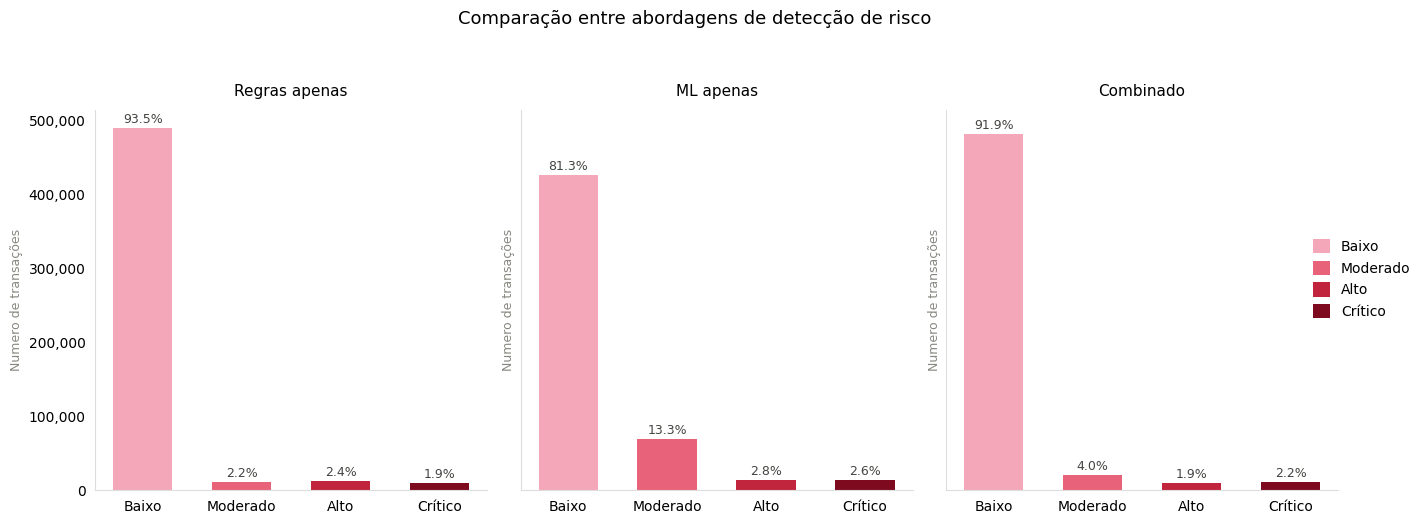

In [50]:
# Grafico comparativo dos 3 baselines
total_orders =len (df )

fig ,axes =plt .subplots (1 ,3 ,figsize =(14 ,5 ),sharey =True )
fig .patch .set_alpha (0 )

for ax ,(col ,label )in zip (
axes ,
[('risk_level_rules_only','Regras apenas'),
('risk_level_ml_only','ML apenas'),
('risk_level','Combinado')]
):

    ax .set_facecolor ('none')

    vc =df [col ].value_counts ().reindex (RISK_LEVELS ).fillna (0 )
    bars =ax .bar (vc .index ,vc .values ,color =[RISK_COLORS [lvl ]for lvl in vc .index ],width =0.6 )

    ax .set_title (label ,fontsize =11 ,fontweight ='500',pad =10 )
    ax .set_ylabel ('Numero de transações',fontsize =9 ,color ='#888780')
    ax .grid (False )

    for spine in ax .spines .values ():
        spine .set_visible (False )
    ax .spines ['bottom'].set_visible (True )
    ax .spines ['bottom'].set_color ('#dddddd')
    ax .spines ['left'].set_visible (True )
    ax .spines ['left'].set_color ('#dddddd')

    ax .tick_params (left =False ,bottom =False )
    ax .yaxis .set_major_formatter (mticker .FuncFormatter (lambda x ,_ :f'{int (x ):,}'))

    for bar ,val in zip (bars ,vc .values ):
        pct =val /total_orders *100 
        if pct >=1.0 :
            ax .text (
            bar .get_x ()+bar .get_width ()/2 ,
            bar .get_height ()+total_orders *0.005 ,
            f'{pct :.1f}%',
            ha ='center',va ='bottom',
            fontsize =9 ,
            color ='#444441',
            )

legend_handles =[Patch (facecolor =RISK_COLORS [lvl ],label =lvl ,linewidth =0 )for lvl in RISK_LEVELS ]

fig .legend (
handles =legend_handles ,
loc ='center right',
bbox_to_anchor =(1.02 ,0.5 ),
frameon =False ,
fontsize =10 ,
handlelength =1.2 ,
handleheight =1.2 ,
)

fig .text (0.5 ,1.01 ,'Comparação entre abordagens de deteção de risco',fontsize =13 ,fontweight ='500',ha ='center')

plt .tight_layout (rect =[0 ,0 ,0.97 ,0.92 ])

if CONFIG ['save_figures']:
    plt .savefig (
    f'{CONFIG ["output_prefix"]}_baselines.png',
    dpi =150 ,
    bbox_inches ='tight',
    transparent =True 
    )

plt .show ()


### Relação entre Regras e Modelo ML

Este gráfico mostra como o score de regras e o score de anomalia se combinam na segmentação final do risco.




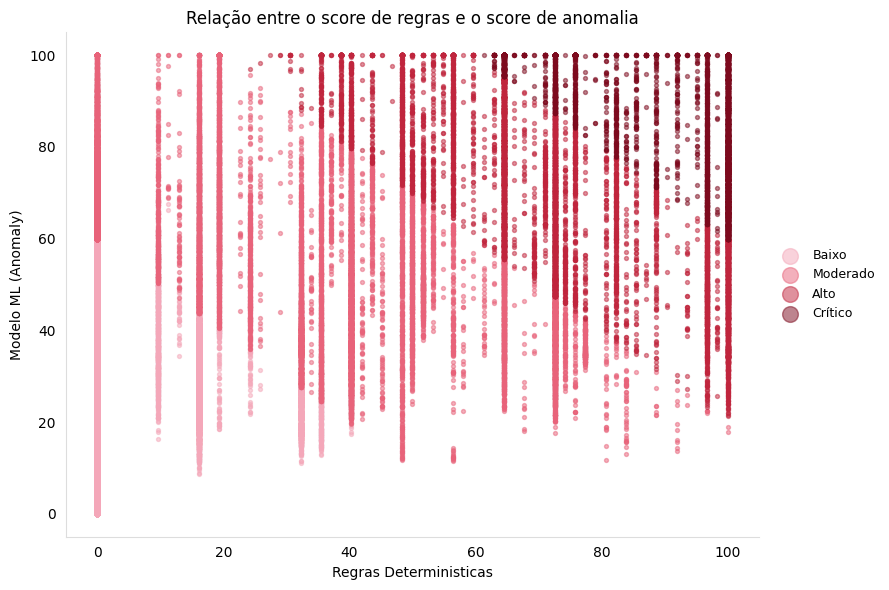

In [51]:
#Scatter: rules score vs ml anomaly score
fig ,ax =plt .subplots (figsize =(9 ,6 ))

for level ,color in RISK_COLORS .items ():
    mask =df ['risk_level']==level 
    ax .scatter (
    df .loc [mask ,'rules_score'],
    df .loc [mask ,'ml_anomaly_score'],
    c =color ,label =level ,alpha =0.5 ,s =8 ,rasterized =True ,)

ax .set_xlabel ('Regras Deterministicas')
ax .set_ylabel ('Modelo ML (Anomaly)')
ax .set_title ('Relação entre o score de regras e o score de anomalia')

ax .grid (False )
ax .spines ['top'].set_visible (False )
ax .spines ['right'].set_visible (False )
ax .spines ['left'].set_color ('#dddddd')
ax .spines ['bottom'].set_color ('#dddddd')
ax .tick_params (left =False ,bottom =False )

ax .legend (
markerscale =4 ,
fontsize =9 ,
frameon =False ,
bbox_to_anchor =(1.01 ,0.5 ),
loc ='center left',)

plt .tight_layout ()

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_scatter.png',dpi =150 ,bbox_inches ='tight')

plt .show ()



## 15. Análise Temporal

A análise temporal compara os segmentos de treino e teste após o cálculo do score final, observando estabilidade do score, percentagem de casos de risco elevado e comportamento do modelo em diferentes períodos.

Este diagnóstico é importante para avaliar robustez, drift temporal e consistência da solução fora do contexto de treino.

In [52]:
#Diagnóstico temporal após o cálculo do score final
if 'split_date'in globals ()and 'final_test_date'in globals ():
    df_train_analysis =df [df ['createdAt']<split_date ].copy ()
    df_validation_analysis =df [(df ['createdAt']>=split_date )&(df ['createdAt']<final_test_date )].copy ()
    df_test_analysis =df [df ['createdAt']>=final_test_date ].copy ()

    temporal_compare_df =pd .DataFrame ([
    {'segmento':'Treino','período':f'< {validation_month }','n_transações':len (df_train_analysis ),'score_medio':round (df_train_analysis ['risk_score'].mean (),2 ),'pct_alto_critico':round (df_train_analysis ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),'pct_anomalias_ml':round (df_train_analysis ['ml_is_anomaly'].mean ()*100 ,2 )},
    {'segmento':'Validação','período':f'{validation_month } a antes de {final_test_month }','n_transações':len (df_validation_analysis ),'score_medio':round (df_validation_analysis ['risk_score'].mean (),2 ),'pct_alto_critico':round (df_validation_analysis ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),'pct_anomalias_ml':round (df_validation_analysis ['ml_is_anomaly'].mean ()*100 ,2 )},
    {'segmento':'Teste final','período':f'>= {final_test_month }','n_transações':len (df_test_analysis ),'score_medio':round (df_test_analysis ['risk_score'].mean (),2 ),'pct_alto_critico':round (df_test_analysis ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),'pct_anomalias_ml':round (df_test_analysis ['ml_is_anomaly'].mean ()*100 ,2 )},
    ])
    print (f'Análise temporal: treino < {validation_month }, validação {validation_month }-{final_test_month }, teste final >= {final_test_month }')
    display (temporal_compare_df )
else :
    print ('Análise temporal detalhada disponível apenas quando existe split temporal de treino/validação/teste.')

Análise temporal: treino < 2025-09, validação 2025-09-2025-12, teste final >= 2025-12


,segmento,período,n_transações,score_medio,pct_alto_critico,pct_anomalias_ml
0,Treino,< 2025-09,345630,10.810,3.490,2.000
1,Validação,2025-09 a antes de 2025-12,132894,13.050,6.120,4.130
2,Teste final,>= 2025-12,45132,9.880,2.130,1.150


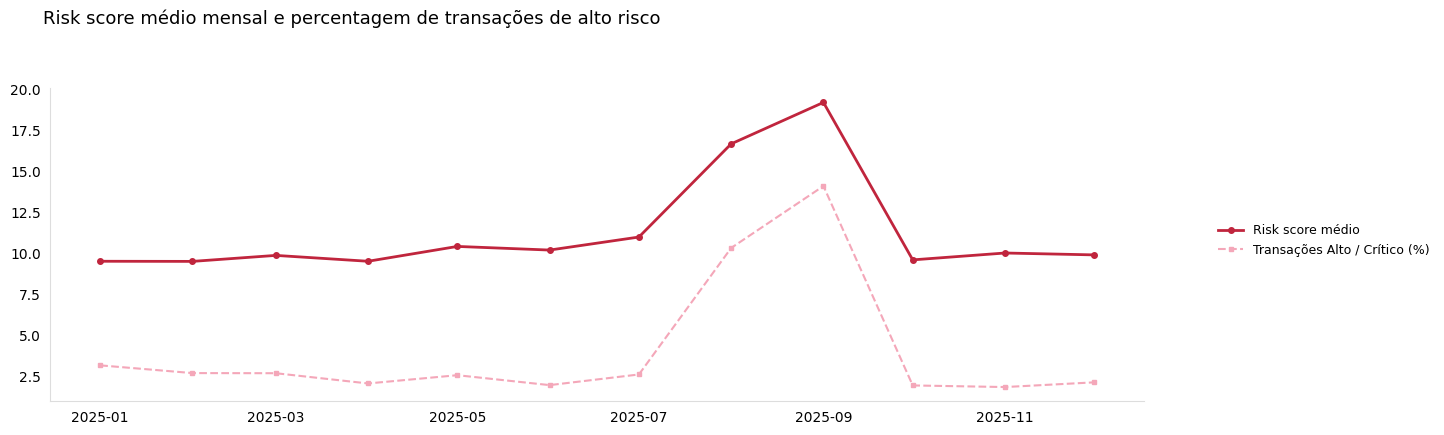

In [53]:
if 'year_month'in df .columns :
    df ['year_month_dt']=pd .to_datetime (df ['year_month'].astype (str ),format ='%Y-%m',errors ='coerce')
    monthly =df .groupby ('year_month_dt').agg (
    avg_risk =('risk_score','mean'),
    pct_high_risk =('risk_level',lambda x :x .isin (['Alto','Crítico']).mean ()*100 ),
    n_orders =('risk_score','count'),
    ).reset_index ()

    fig ,ax1 =plt .subplots (figsize =(12 ,4 ))
    ax1 .plot (monthly ['year_month_dt'],monthly ['avg_risk'],color ='#c0253d',linewidth =2 ,marker ='o',markersize =4 ,label ='Risk score médio')
    ax1 .plot (monthly ['year_month_dt'],monthly ['pct_high_risk'],color ='#f4a7b9',linewidth =1.5 ,linestyle ='--',marker ='s',markersize =3 ,label ='Transações Alto / Crítico (%)')

    ax1 .set_ylabel ('')
    ax1 .set_xlabel ('')
    ax1 .grid (False )
    ax1 .spines ['top'].set_visible (False )
    ax1 .spines ['right'].set_visible (False )
    ax1 .spines ['left'].set_color ('#dddddd')
    ax1 .spines ['bottom'].set_color ('#dddddd')
    ax1 .tick_params (left =False ,bottom =False )

    fig .text (0.04 ,1.04 ,'Risk score médio mensal e percentagem de transações de alto risco',fontsize =13 ,fontweight ='500')

    fig .legend (fontsize =9 ,frameon =False ,bbox_to_anchor =(1.01 ,0.5 ),loc ='center left')

    plt .tight_layout (rect =[0 ,0 ,0.97 ,0.93 ])

    if CONFIG ['save_figures']:
        plt .savefig (f'{CONFIG ["output_prefix"]}_temporal.png',dpi =150 ,bbox_inches ='tight')

    plt .show ()
else :
    print ('Visualização temporal indisponível: coluna year_month não encontrada.')

### Métricas Mensais e Drift

Em produção, esta secção mantém um resumo mensal compacto para acompanhar volume, risco, anomalias ML e exposição sinalizada. Em modo de teste, acrescenta cortes operacionais adicionais para análise de drift.




In [54]:
if 'year_month'in df .columns :
    _monthly_base =df .copy ()
    _monthly_base ['year_month_dt']=pd .to_datetime (_monthly_base ['year_month'].astype (str ),format ='%Y-%m',errors ='coerce')

    monthly_metrics =(
    _monthly_base .groupby ('year_month_dt')
    .apply (lambda g :pd .Series ({
    'n_transações':len (g ),
    'score_medio':round (g ['risk_score'].mean (),2 ),
    'score_mediana':round (g ['risk_score'].median (),2 ),
    'p95_risk_score':round (g ['risk_score'].quantile (0.95 ),2 ),
    'pct_moderado':round ((g ['risk_level']=='Moderado').mean ()*100 ,2 ),
    'pct_alto':round ((g ['risk_level']=='Alto').mean ()*100 ,2 ),
    'pct_critico':round ((g ['risk_level']=='Crítico').mean ()*100 ,2 ),
    'pct_alto_critico':round (g ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),
    'pct_ml_is_anomaly':round (g ['ml_is_anomaly'].mean ()*100 ,2 ),
    'hard_block_rate':round (g ['hard_block_rule'].mean ()*100 ,4 ),
    'valor_total_sinalizado':round (g .loc [g ['risk_level'].isin (['Alto','Crítico']),'total_amount'].sum (),2 ),
    'valor_medio_baixo':round (g .loc [g ['risk_level']=='Baixo','total_amount'].mean (),2 ),
    'valor_medio_moderado':round (g .loc [g ['risk_level']=='Moderado','total_amount'].mean (),2 ),
    'valor_medio_alto':round (g .loc [g ['risk_level']=='Alto','total_amount'].mean (),2 ),
    'valor_medio_critico':round (g .loc [g ['risk_level']=='Crítico','total_amount'].mean (),2 ),
    }))
    .reset_index ()
    )

    print ('Métricas mensais de risco e drift:')
    display (monthly_metrics )

    if CONFIG .get ('mode')=='test':
        if 'order_status'in df .columns :
            monthly_order_status =(
            _monthly_base .pivot_table (index ='year_month_dt',columns ='order_status',values ='risk_score',aggfunc ='mean')
            .round (2 )
            .reset_index ()
            )
            print ('\nScore médio por mês e order_status:')
            display (monthly_order_status )

        if 'payment_method_method'in df .columns :
            top_payment_methods =(
            _monthly_base ['payment_method_method'].fillna ('N/A').value_counts ().head (5 ).index .tolist ()
            )
            monthly_payment_method =(
            _monthly_base [_monthly_base ['payment_method_method'].fillna ('N/A').isin (top_payment_methods )]
            .pivot_table (index ='year_month_dt',columns ='payment_method_method',values ='risk_score',aggfunc ='mean')
            .round (2 )
            .reset_index ()
            )
            print ('\nScore médio por mês e método de pagamento (top 5):')
            display (monthly_payment_method )

        for _col ,_label in [
        ('is_guest','Score médio por mês e tipo de checkout'),
        ('cross_border_order','Score médio por mês e cross-border'),
        ]:
            if _col in df .columns :
                _tmp =(
                _monthly_base .pivot_table (index ='year_month_dt',columns =_col ,values ='risk_score',aggfunc ='mean')
                .round (2 )
                .reset_index ()
                )
                print (f'\n{_label }:')
                display (_tmp )
else :
    print ('Métricas mensais indisponíveis: coluna year_month não encontrada.')


Métricas mensais de risco e drift:


,year_month_dt,n_transações,score_medio,score_mediana,p95_risk_score,pct_moderado,pct_alto,pct_critico,pct_alto_critico,pct_ml_is_anomaly,hard_block_rate,valor_total_sinalizado,valor_medio_baixo,valor_medio_moderado,valor_medio_alto,valor_medio_critico
0,2025-01-01,46792.000,9.490,4.400,40.140,3.600,1.900,1.260,3.160,1.330,0.058,2025240.550,174.700,702.520,929.350,2030.430
1,2025-02-01,38027.000,9.480,4.800,36.600,3.710,1.530,1.160,2.690,1.180,0.011,1324496.560,164.510,643.670,898.220,1817.990
2,2025-03-01,42877.000,9.850,5.200,37.400,3.870,1.430,1.250,2.680,1.340,0.054,1478501.520,170.010,732.950,863.410,1767.650
3,2025-04-01,39769.000,9.490,5.600,34.200,3.900,1.400,0.660,2.060,0.830,0.010,1001682.970,167.390,712.540,852.900,2014.410
4,2025-05-01,47040.000,10.390,6.100,37.200,4.280,1.510,1.050,2.560,1.460,0.015,1325669.340,169.070,723.860,844.610,1465.410
5,2025-06-01,42995.000,10.170,6.200,35.600,4.480,1.270,0.680,1.960,1.000,0.002,1125127.100,170.170,775.590,963.800,2030.490
6,2025-07-01,45816.000,10.970,6.600,39.420,4.750,1.730,0.870,2.610,1.470,0.002,1357076.750,181.470,892.320,832.570,1740.040
7,2025-08-01,42314.000,16.630,6.800,82.300,4.540,3.220,7.080,10.300,7.430,0.009,1033286.360,175.340,652.760,365.480,178.680
8,2025-09-01,46201.000,19.150,7.100,82.300,3.930,4.620,9.450,14.070,10.210,0.009,658408.030,162.390,502.000,143.790,80.530
9,2025-10-01,39817.000,9.580,5.800,33.200,3.720,1.370,0.570,1.940,0.810,0.035,728902.170,155.750,546.420,613.240,1743.690



Score médio por mes e order_status:


order_status,year_month_dt,failed,success
0,2025-01-01,15.780,5.400
1,2025-02-01,15.360,5.760
2,2025-03-01,16.030,5.780
3,2025-04-01,14.560,6.080
4,2025-05-01,15.680,6.690
5,2025-06-01,15.000,6.660
6,2025-07-01,16.810,6.840
7,2025-08-01,28.580,6.550
8,2025-09-01,33.600,6.570
9,2025-10-01,14.370,6.620



Score médio por mes e método de pagamento (top 5):


payment_method_method,year_month_dt,CC,FLOAPAY4X,KLARNA,MB,MBWAY
0,2025-01-01,7.410,21.260,13.790,5.730,4.580
1,2025-02-01,8.060,19.900,14.070,5.540,4.590
2,2025-03-01,8.210,21.080,13.670,5.910,4.980
3,2025-04-01,7.840,18.580,14.030,6.010,5.220
4,2025-05-01,9.550,19.070,15.120,7.280,5.680
5,2025-06-01,9.000,17.890,15.310,6.930,5.660
6,2025-07-01,10.180,18.830,16.480,6.950,5.860
7,2025-08-01,51.500,19.720,14.280,6.450,5.460
8,2025-09-01,58.590,16.810,13.860,6.580,5.620
9,2025-10-01,9.100,16.880,14.710,6.800,5.870



Score médio por mes e tipo de checkout:


is_guest,year_month_dt,0,1
0,2025-01-01,9.430,10.790
1,2025-02-01,9.410,11.020
2,2025-03-01,9.780,11.460
3,2025-04-01,9.440,10.860
4,2025-05-01,10.360,11.240
5,2025-06-01,10.110,11.810
6,2025-07-01,10.960,11.070
7,2025-08-01,16.630,NaN
8,2025-09-01,19.150,NaN
9,2025-10-01,9.580,NaN



Score médio por mes e cross-border:


cross_border_order,year_month_dt,0.000,1.000
0,2025-01-01,9.480,16.250
1,2025-02-01,9.480,14.390
2,2025-03-01,9.840,13.860
3,2025-04-01,9.470,18.850
4,2025-05-01,10.380,14.380
5,2025-06-01,10.170,14.040
6,2025-07-01,10.950,17.970
7,2025-08-01,16.630,15.590
8,2025-09-01,19.160,17.400
9,2025-10-01,9.560,17.550


### Backtesting Rolling por Mês

Em modo de teste, esta secção repete a lógica de treino e scoring em janelas mensais crescentes para observar estabilidade fora de um único split temporal. A leitura principal é: treino acumulado até ao mês anterior e teste no mês seguinte.

O mês definido em `final_test_month` fica excluído do rolling backtest para continuar a funcionar como teste final cego.

In [55]:
if CONFIG .get ('mode')=='test'and 'year_month'in df .columns :
    rolling_months =sorted (pd .to_datetime (df ['year_month'].dropna ().astype (str ).unique (),format ='%Y-%m',errors ='coerce'))
    rolling_months =[m for m in rolling_months if pd .notna (m )]
    final_test_month =CONFIG .get ('final_test_month','2025-12')
    final_test_month_dt =pd .Timestamp (final_test_month +'-01')
    rolling_months =[m for m in rolling_months if m <final_test_month_dt ]
    proxy_label_col =CONFIG .get ('proxy_label_col','hard_block_rule')

    min_train_months =6 
    rolling_backtest_rows =[]

    if len (rolling_months )<=min_train_months :
        print ('Backtesting rolling indisponível: meses insuficientes para janela inicial de 6 meses antes do teste final.')
    else :
        for i in range (min_train_months ,len (rolling_months )):
            train_months =rolling_months [:i ]
            test_month =rolling_months [i ]
            df_train_roll =df [df ['year_month_dt'].isin (train_months )].copy ()
            df_test_roll =df [df ['year_month_dt']==test_month ].copy ()
            if len (df_train_roll )==0 or len (df_test_roll )==0 :
                continue 
            cfg_roll =_copy .deepcopy (CONFIG )
            cfg_roll .pop ('_rules_score_p1',None )
            cfg_roll .pop ('_rules_score_p99',None )
            df_train_roll ,_ =apply_rules (df_train_roll ,cfg_roll )
            df_train_roll ,pipe_roll ,medians_roll ,p1_roll ,p99_roll ,_ ,_ =fit_anomaly_model (df_train_roll ,ML_FEATURES ,cfg_roll )
            df_train_roll =combine_scores (df_train_roll ,cfg_roll )
            df_test_roll ,_ =apply_rules (df_test_roll ,cfg_roll )
            df_test_roll ,_ ,_ =apply_anomaly_model (df_test_roll ,ML_FEATURES ,pipe_roll ,medians_roll ,p1_roll ,p99_roll )
            df_test_roll =combine_scores (df_test_roll ,cfg_roll )
            row ={'treino_inicio':train_months [0 ].strftime ('%Y-%m'),'treino_fim':train_months [-1 ].strftime ('%Y-%m'),'teste_mes':test_month .strftime ('%Y-%m'),'n_treino':len (df_train_roll ),'n_teste':len (df_test_roll ),'score_medio_teste':round (df_test_roll ['risk_score'].mean (),2 ),'pct_alto_critico_teste':round (df_test_roll ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),'pct_ml_is_anomaly_teste':round (df_test_roll ['ml_is_anomaly'].mean ()*100 ,2 )}
            if proxy_label_col in df_test_roll .columns :
                y_roll =df_test_roll [proxy_label_col ].fillna (0 ).astype (int )
                y_pred_roll =(df_test_roll ['risk_score']>=30 ).astype (int )
                row [f'precision_proxy_{proxy_label_col }_t30']=round (precision_score (y_roll ,y_pred_roll ,zero_division =0 ),3 )
                row [f'recall_proxy_{proxy_label_col }_t30']=round (recall_score (y_roll ,y_pred_roll ,zero_division =0 ),3 )
            rolling_backtest_rows .append (row )
        rolling_backtest =pd .DataFrame (rolling_backtest_rows )
        print (f'Backtesting rolling mensal até antes do teste final ({final_test_month }); proxy={proxy_label_col }:')
        display (rolling_backtest )
else :
    print ('Backtesting rolling disponível apenas em modo testee com coluna year_month.')

rules_score calibrado: p1=0.000, p99=60.000
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 5,150  (2.0%)
rules_score calibrado: p1=0.000, p99=60.000
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 6,067  (2.0%)
rules_score calibrado: p1=0.000, p99=62.000
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 6,913  (2.0%)
rules_score calibrado: p1=0.000, p99=62.000
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 7,832  (2.0%)
rules_score calibrado: p1=0.000, p99=62.000
Isolation Forest treinado (contamination=0.02)
Anomalias detectadas no treino: 8,629  (2.0%)
Backtesting rolling mensal até antes do teste final (2025-12); proxy=hard_block_rule:


,treino_inicio,treino_fim,teste_mes,n_treino,n_teste,score_medio_teste,pct_alto_critico_teste,pct_ml_is_anomaly_teste,precision_proxy_hard_block_rule_t30,recall_proxy_hard_block_rule_t30
0,2025-01,2025-06,2025-07,257500,45816,12.610,3.490,2.430,0.000,1.000
1,2025-01,2025-07,2025-08,303316,42314,18.180,11.570,10.230,0.001,1.000
2,2025-01,2025-08,2025-09,345630,46201,19.150,14.070,10.210,0.000,1.000
3,2025-01,2025-09,2025-10,391831,39817,8.940,1.560,0.530,0.007,1.000
4,2025-01,2025-10,2025-11,431648,46876,9.530,1.650,0.710,0.006,1.000


### Drilldown de Drift: CC + Failed

Esta secção foca o segmento mais suspeito do drift de agosto e setembro de 2025: ordens com `payment_method_method == "CC"` e `order_status == "failed"`.

A leitura compara agosto e setembro com julho, outubro e novembro para perceber se o desvio vem de perfil de cliente, intensidade de falhas, ritmo de encomendas, valor ou concentração por merchant.

Resumo CC + failed por mes:


,mes,n_transações,n_users,score_medio,pct_alto_critico,pct_ml_is_anomaly,pct_guest,pct_first_order,account_age_median,prev_fail_1d_median,prev_fail_7d_median,prev_fail_30d_median,num_orders_24h_median,total_amount_median,total_amount_p95
0,2025-07,1463,935,12.720,3.490,2.190,4.780,34.650,111.000,0.000,0.000,0.000,0.000,61.690,1191.890
1,2025-08,4843,763,64.710,71.440,55.520,0.000,8.470,4.000,285.000,309.000,309.000,285.000,20.290,321.970
2,2025-09,7490,725,70.010,78.650,59.070,0.000,5.010,0.000,271.000,310.000,310.000,271.000,19.040,111.980
3,2025-10,1079,724,11.030,2.220,1.580,0.000,35.500,214.000,0.000,0.000,0.000,0.000,47.450,1322.800
4,2025-11,1363,861,12.340,2.790,1.980,0.000,35.000,182.000,0.000,0.000,0.000,0.000,59.980,1325.100



Distribuição de total_amount no segmento CC + failed:


,year_month_dt,count,mean,median,min,p75,p95,max
0,2025-07,1463,279.280,61.690,5.000,299.980,1191.890,4840.000
1,2025-08,4843,69.500,20.290,5.330,20.290,321.970,3537.000
2,2025-09,7490,47.840,19.040,6.100,23.000,111.980,3235.140
3,2025-10,1079,266.880,47.450,6.680,218.740,1322.800,8800.000
4,2025-11,1363,278.870,59.980,4.920,256.500,1325.100,6054.000



Top merchants / sellers / stores dentro de CC + failed:

Top store_id:


,year_month_dt,store_id,n_transações,n_users,score_medio,pct_alto_critico
173,2025-07-01,s-13259,70,51,25.140,5.710
220,2025-07-01,s-7740,42,33,11.140,0.000
17,2025-07-01,s-10534,41,33,7.510,0.000
155,2025-07-01,s-13103,39,30,22.120,10.260
20,2025-07-01,s-10601,35,25,7.630,0.000
71,2025-07-01,s-11808,29,26,7.600,0.000
120,2025-07-01,s-12771,26,22,12.390,3.850
174,2025-07-01,s-13264,26,21,8.790,0.000
124,2025-07-01,s-12807,24,19,9.240,0.000
215,2025-07-01,s-5564,22,18,23.120,13.640



Top regras no segmento CC + failed por mes:


,mes,rule,fire_rate_%,n_fired
7,2025-07,rule_payment_failures_24h,2.600,38
17,2025-07,rule_multi_merchant_24h,2.320,34
3,2025-07,rule_unusual_amount_zscore,1.780,26
4,2025-07,rule_unusual_amount_category,1.710,25
10,2025-07,rule_first_order_new_category_highval,1.230,18
16,2025-07,rule_mp_low_commission_highval,1.230,18
5,2025-07,rule_above_cohort_p95_highval,1.160,17
1,2025-07,rule_new_account_freq_failures,1.090,16
11,2025-07,rule_mp_new_account_highval,0.680,10
18,2025-07,rule_merchant_high_cancel_rate_burst,0.680,10


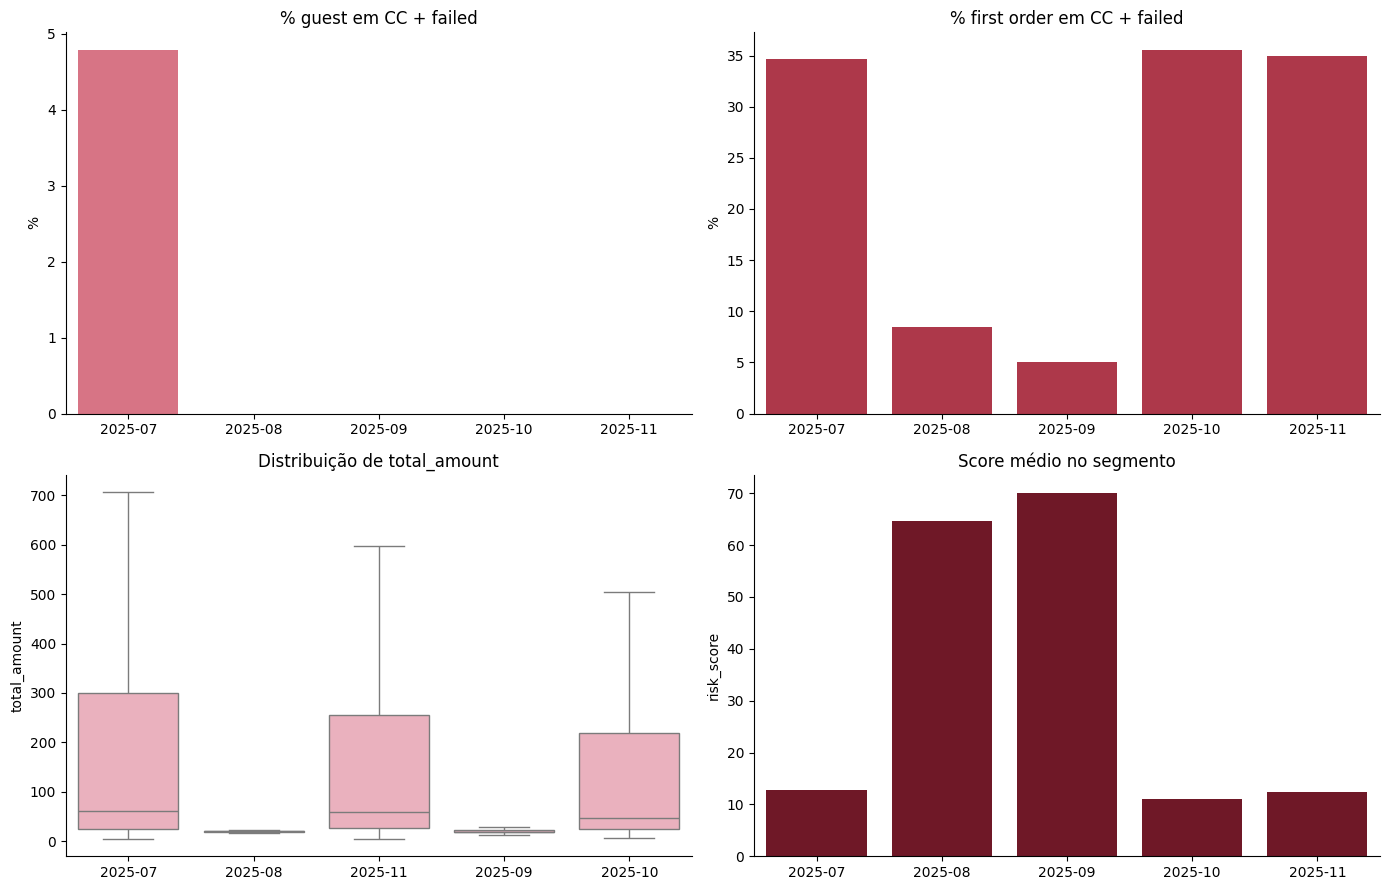

In [56]:
comparison_months =pd .to_datetime (['2025-07-01','2025-08-01','2025-09-01','2025-10-01','2025-11-01'])

if 'year_month_dt'in df .columns :
    df_cc_failed =df [
    df ['year_month_dt'].isin (comparison_months )
    &(df .get ('payment_method_method',pd .Series ('',index =df .index ))=='CC')
    &(df .get ('order_status',pd .Series ('',index =df .index ))=='failed')
    ].copy ()

    if len (df_cc_failed )==0 :
        print ('Análise CC + failed indisponível: segmento não encontrado para os meses selecionados.')
    else :
        print ('Resumo CC + failed por mes:')
        summary_rows =[]
        for month in comparison_months :
            g =df_cc_failed [df_cc_failed ['year_month_dt']==month ].copy ()
            if len (g )==0 :
                continue 
            summary_rows .append ({
            'mes':month .strftime ('%Y-%m'),
            'n_transações':len (g ),
            'n_users':g ['customer_on_purchase_userId'].astype (str ).nunique ()if 'customer_on_purchase_userId'in g .columns else np .nan ,
            'score_medio':round (g ['risk_score'].mean (),2 ),
            'pct_alto_critico':round (g ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),
            'pct_ml_is_anomaly':round (g ['ml_is_anomaly'].mean ()*100 ,2 ),
            'pct_guest':round (g .get ('is_guest',pd .Series (0 ,index =g .index )).mean ()*100 ,2 ),
            'pct_first_order':round (g .get ('is_first_order',pd .Series (0 ,index =g .index )).mean ()*100 ,2 ),
            'account_age_median':round (g .get ('account_age_days',pd .Series (np .nan ,index =g .index )).median (),1 ),
            'prev_fail_1d_median':round (g .get ('prev_failures_1d',pd .Series (np .nan ,index =g .index )).median (),1 ),
            'prev_fail_7d_median':round (g .get ('prev_failures_7d',pd .Series (np .nan ,index =g .index )).median (),1 ),
            'prev_fail_30d_median':round (g .get ('prev_failures_30d',pd .Series (np .nan ,index =g .index )).median (),1 ),
            'num_orders_24h_median':round (g .get ('num_orders_24h',pd .Series (np .nan ,index =g .index )).median (),1 ),
            'total_amount_median':round (g .get ('total_amount',pd .Series (np .nan ,index =g .index )).median (),2 ),
            'total_amount_p95':round (g .get ('total_amount',pd .Series (np .nan ,index =g .index )).quantile (0.95 ),2 ),
            })
        cc_failed_summary =pd .DataFrame (summary_rows )
        display (cc_failed_summary )

        print ('\nDistribuição de total_amount no segmento CC + failed:')
        amount_dist =(
        df_cc_failed .groupby ('year_month_dt')['total_amount']
        .agg (['count','mean','median','min',lambda x :x .quantile (0.75 ),lambda x :x .quantile (0.95 ),'max'])
        .rename (columns ={'<lambda_0>':'p75','<lambda_1>':'p95'})
        .reset_index ()
        )
        amount_dist ['year_month_dt']=amount_dist ['year_month_dt'].dt .strftime ('%Y-%m')
        display (amount_dist .round (2 ))

        print ('\nTop merchants / sellers / stores dentro de CC + failed:')
        entity_cols =[
        ('store_id','store_id'),
        ('store_name','store_name'),
        ('merchant_id','merchant_id'),
        ('seller_id','seller_id'),
        ]
        for col_name ,label in entity_cols :
            if col_name in df_cc_failed .columns :
                top_entities =(
                df_cc_failed .groupby (['year_month_dt',col_name ])
                .agg (
                n_transações =('risk_score','count'),
                n_users =('customer_on_purchase_userId',lambda x :x .astype (str ).nunique ())if 'customer_on_purchase_userId'in df_cc_failed .columns else ('risk_score','count'),
                score_medio =('risk_score','mean'),
                pct_alto_critico =('risk_level',lambda x :x .isin (['Alto','Crítico']).mean ()*100 ),
                )
                .reset_index ()
                .sort_values (['year_month_dt','n_transações','score_medio'],ascending =[True ,False ,False ])
                )
                print (f'\nTop {label }:')
                display (top_entities .groupby ('year_month_dt').head (10 ).round (2 ))

        print ('\nTop regras no segmento CC + failed por mes:')
        cc_rule_rows =[]
        cc_rule_cols =[c for c in df_cc_failed .columns if c .startswith ('rule_')]
        for month in comparison_months :
            g =df_cc_failed [df_cc_failed ['year_month_dt']==month ].copy ()
            if len (g )==0 :
                continue 
            for r in cc_rule_cols :
                fire_rate =g [r ].mean ()*100 
                if fire_rate ==0 :
                    continue 
                cc_rule_rows .append ({
                'mes':month .strftime ('%Y-%m'),
                'rule':r ,
                'fire_rate_%':fire_rate ,
                'n_fired':int (g [r ].sum ()),
                })
        cc_rule_df =pd .DataFrame (cc_rule_rows )
        if len (cc_rule_df ):
            display (cc_rule_df .sort_values (['mes','fire_rate_%'],ascending =[True ,False ]).groupby ('mes').head (12 ).round (2 ))

        fig ,axes =plt .subplots (2 ,2 ,figsize =(14 ,9 ))
        plot_df =df_cc_failed .copy ()
        plot_df ['mes']=plot_df ['year_month_dt'].dt .strftime ('%Y-%m')

        sns .barplot (data =cc_failed_summary ,x ='mes',y ='pct_guest',color ='#e8637a',ax =axes [0 ,0 ])
        axes [0 ,0 ].set_title ('% guest em CC + failed')
        axes [0 ,0 ].set_xlabel ('')
        axes [0 ,0 ].set_ylabel ('%')

        sns .barplot (data =cc_failed_summary ,x ='mes',y ='pct_first_order',color ='#c0253d',ax =axes [0 ,1 ])
        axes [0 ,1 ].set_title ('% first order em CC + failed')
        axes [0 ,1 ].set_xlabel ('')
        axes [0 ,1 ].set_ylabel ('%')

        sns .boxplot (data =plot_df ,x ='mes',y ='total_amount',color ='#f4a7b9',ax =axes [1 ,0 ],showfliers =False )
        axes [1 ,0 ].set_title ('Distribuição de total_amount')
        axes [1 ,0 ].set_xlabel ('')
        axes [1 ,0 ].set_ylabel ('total_amount')

        sns .barplot (data =cc_failed_summary ,x ='mes',y ='score_medio',color ='#7d0a1e',ax =axes [1 ,1 ])
        axes [1 ,1 ].set_title ('Score médio no segmento')
        axes [1 ,1 ].set_xlabel ('')
        axes [1 ,1 ].set_ylabel ('risk_score')

        for ax in axes .flat :
            ax .grid (False )
            ax .spines ['top'].set_visible (False )
            ax .spines ['right'].set_visible (False )

        plt .tight_layout ()
        if CONFIG ['save_figures']:
            plt .savefig (f'{CONFIG ["output_prefix"]}_cc_failed_drift.png',dpi =150 ,bbox_inches ='tight')
        plt .show ()
else :
    print ('Análise CC + failed indisponível: coluna year_month_dt não encontrada.')

## 16. Análise de Leakage

Antes de interpretar os resultados, importa verificar se as features históricas foram construídas sem utilizar informação futura.




In [57]:
print ('\nLeakage check manual  amostra de 3 utilizadores')
sample_users =df ['user_key'].dropna ().drop_duplicates ().sample (min (3 ,df ['user_key'].nunique ()),random_state =42 )

cols_leak =[
'user_key','customer_on_purchase_userId','createdAt','total_amount',
'prev_total_orders','prev_avg_order_amount','order_amount_vs_avg',
'prev_failures_1d','prev_failures_7d','prev_failures_30d',
'payment_method_method','prev_unique_payment_methods','is_new_payment_method'
]

cols_leak =[c for c in cols_leak if c in df .columns ]

display (df [df ['user_key'].isin (sample_users )][cols_leak ].sort_values (['user_key','createdAt']))


Leakage check manual  amostra de 3 utilizadores


,user_key,customer_on_purchase_userId,createdAt,total_amount,prev_total_orders,prev_avg_order_amount,order_amount_vs_avg,prev_failures_1d,prev_failures_7d,prev_failures_30d,payment_method_method,prev_unique_payment_methods,is_new_payment_method
79571,5fdfe785-0aaf-4e5a-b620-4a719aa2d428,5fdfe785-0aaf-4e5a-b620-4a719aa2d428,2025-07-08 09:59:21+00:00,83.000,0,NaN,1.000,0.000,0.000,0.000,MBWAY,0,0
231488,94cbf8cf-7e70-4b6b-8b47-014b2dddca0c,94cbf8cf-7e70-4b6b-8b47-014b2dddca0c,2025-02-17 16:55:08+00:00,79.950,0,NaN,1.000,0.000,0.000,0.000,MBWAY,0,0
480384,de61699d-1c1c-4455-a477-847c3b76893d,de61699d-1c1c-4455-a477-847c3b76893d,2025-02-04 19:02:55+00:00,24.790,0,NaN,1.000,0.000,0.000,0.000,MBWAY,0,0


## 17. Validação das Regras

Nesta secção são avaliadas a frequência de ativação das regras, o lift nos casos sinalizados, a contribuição para o score final e alguns cenários sintéticos de teste.



In [58]:
#Frequência e ruido das regras
rule_cols =[c for c in df .columns if c .startswith ('rule_')]

rule_analysis =pd .DataFrame ({
'fired_count':df [rule_cols ].sum (),
'fire_rate_%':(df [rule_cols ].mean ()*100 ).round (2 ),
'avg_risk_when_fired':[df .loc [df [r ]==1 ,'risk_score'].mean ()for r in rule_cols ],
'weight':[CONFIG ['rule_weights'].get (r ,0 )for r in rule_cols ],
}).sort_values ('fired_count',ascending =False )

never =rule_analysis [rule_analysis ['fired_count']==0 ]
noisy =rule_analysis [rule_analysis ['fire_rate_%']>5 ]

print ('Regras que nunca disparam:')
display (never if len (never )else pd .DataFrame ({'info':['Nenhuma']}))

print ('Regras com taxa de disparo superior a 5%:')
display (noisy if len (noisy )else pd .DataFrame ({'info':['Nenhuma']}))

print ('Todas as regras por frequência:')
display (rule_analysis )

Regras que nunca disparam:


,fired_count,fire_rate_%,avg_risk_when_fired,weight
rule_freq_guest_highval,0,0.000,NaN,25
rule_cart_price_manipulation,0,0.000,NaN,30
rule_cart_stock_exceeded,0,0.000,NaN,10
rule_seller_cancellations,0,0.000,NaN,18


Regras com taxa de disparo superior a 5%:


,info
0,Nenhuma


Todas as regras por frequência:


,fired_count,fire_rate_%,avg_risk_when_fired,weight
rule_payment_failures_24h,22628,4.320,70.399,25
rule_new_account_freq_failures,12826,2.450,79.979,15
rule_multi_merchant_24h,8972,1.710,59.774,20
rule_unusual_amount_zscore,6478,1.240,37.887,10
rule_unusual_amount_category,5318,1.020,69.052,12
rule_burst_orders_2min,5024,0.960,81.329,22
rule_above_cohort_p95_highval,3440,0.660,81.803,12
rule_first_order_new_category_highval,3304,0.630,67.552,20
rule_merchant_high_cancel_rate_burst,3174,0.610,52.298,6
rule_mp_new_account_highval,2787,0.530,80.986,28


Transações totais:  523,656
Alto + Crítico (flagged): 21,165  (4.04%)
Alto:    9,841  (1.88%)
Crítico: 11,324  (2.16%)



,rule,global_%,flagged_%,lift,n_flagged
5,payment_failures_24h,4.321,73.499,17.009,15556
1,new_account_freq_failures,2.449,54.713,22.338,11580
24,multi_merchant_24h,1.713,22.977,13.410,4863
29,burst_orders_2min,0.959,19.216,20.029,4067
11,unusual_amount_category,1.016,16.371,16.121,3465
12,above_cohort_p95_highval,0.657,14.893,22.670,3152
21,mp_low_commission_highval,0.521,12.284,23.572,2600
13,mp_new_account_highval,0.532,12.152,22.833,2572
10,first_order_new_category_highval,0.631,10.357,16.415,2192
22,bnpl_new_account,0.342,8.457,24.714,1790


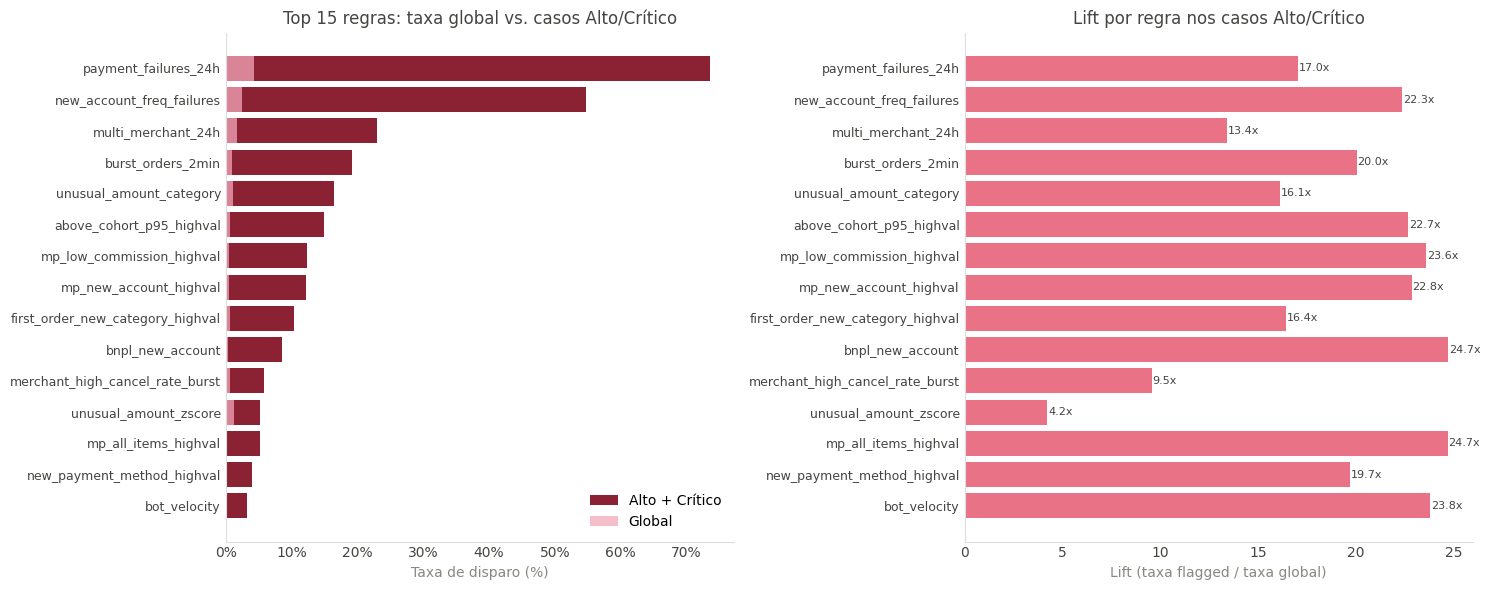

In [59]:
# Análise das regras nos casos de risco Alto + Crítico
flagged =df [df ['risk_level'].isin (['Alto','Crítico'])].copy ()
total =len (df )
n_flag =len (flagged )

print (f"Transações totais:  {total :,}")
print (f"Alto + Crítico (flagged): {n_flag :,}  ({n_flag /total *100 :.2f}%)")
print (f"Alto:    {(df ['risk_level']=='Alto').sum ():,}  ({(df ['risk_level']=='Alto').mean ()*100 :.2f}%)")
print (f"Crítico: {(df ['risk_level']=='Crítico').sum ():,}  ({(df ['risk_level']=='Crítico').mean ()*100 :.2f}%)")
print ()

rule_analysis_rows =[]
for r in RULE_COLS :
    if r not in df .columns :
        continue 
    rate_global =df [r ].mean ()*100 
    rate_flagged =flagged [r ].mean ()*100 if n_flag >0 else 0 
    lift =rate_flagged /rate_global if rate_global >0 else 0 
    rule_analysis_rows .append ({
    'rule':r .replace ('rule_',''),
    'global_%':rate_global ,
    'flagged_%':rate_flagged ,
    'lift':lift ,
    'n_flagged':int (flagged [r ].sum ()),
    })

ra =pd .DataFrame (rule_analysis_rows ).sort_values ('flagged_%',ascending =False )
display (ra )

TEXT_MAIN ='#444441'
TEXT_SUB ='#888780'
AXIS_LINE ='#dddddd'
PINK_LIGHT ='#f4a7b9'
PINK_MAIN ='#e8637a'
PINK_DARK ='#7d0a1e'

fig ,axes =plt .subplots (1 ,2 ,figsize =(15 ,6 ))

top15 =ra .head (15 )
x =range (len (top15 ))

# Painel 1
ax =axes [0 ]
ax .barh (list (x ),top15 ['flagged_%'],color =PINK_DARK ,alpha =0.9 ,label ='Alto + Crítico')
ax .barh (list (x ),top15 ['global_%'],color =PINK_LIGHT ,alpha =0.75 ,label ='Global')
ax .set_yticks (list (x ))
ax .set_yticklabels (top15 ['rule'],fontsize =9 ,color =TEXT_MAIN )
ax .invert_yaxis ()
ax .set_xlabel ('Taxa de disparo (%)',color =TEXT_SUB )
ax .set_title ('Top 15 regras: taxa global vs. casos Alto/Crítico',color =TEXT_MAIN ,fontweight ='500')
ax .legend (frameon =False )
ax .xaxis .set_major_formatter (mticker .FormatStrFormatter ('%.0f%%'))
ax .grid (False )

for spine in ax .spines .values ():
    spine .set_visible (False )
ax .spines ['bottom'].set_visible (True )
ax .spines ['bottom'].set_color (AXIS_LINE )
ax .spines ['left'].set_visible (True )
ax .spines ['left'].set_color (AXIS_LINE )
ax .tick_params (axis ='both',length =0 ,colors =TEXT_MAIN )

# Painel 2
ax2 =axes [1 ]
bars =ax2 .barh (list (x ),top15 ['lift'],color =PINK_MAIN ,alpha =0.9 )
ax2 .set_yticks (list (x ))
ax2 .set_yticklabels (top15 ['rule'],fontsize =9 ,color =TEXT_MAIN )
ax2 .invert_yaxis ()
ax2 .set_xlabel ('Lift (taxa flagged / taxa global)',color =TEXT_SUB )
ax2 .set_title ('Lift por regra nos casos Alto/Crítico',color =TEXT_MAIN ,fontweight ='500')
ax2 .grid (False )

for bar ,val in zip (bars ,top15 ['lift']):
    ax2 .text (
    bar .get_width ()+0.05 ,
    bar .get_y ()+bar .get_height ()/2 ,
    f'{val :.1f}x',
    va ='center',
    fontsize =8 ,
    color =TEXT_MAIN 
    )

for spine in ax2 .spines .values ():
    spine .set_visible (False )
ax2 .spines ['bottom'].set_visible (True )
ax2 .spines ['bottom'].set_color (AXIS_LINE )
ax2 .spines ['left'].set_visible (True )
ax2 .spines ['left'].set_color (AXIS_LINE )
ax2 .tick_params (axis ='both',length =0 ,colors =TEXT_MAIN )

plt .tight_layout ()
if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_lift_regras.png',dpi =150 ,bbox_inches ='tight')
plt .show ()


Contribuição de cada regra para o score total (top 15):


,weight,fired_count,contrib_mean,contrib_total,contrib_pct
rule_payment_failures_24h,25,22628,1.080,565700,34.764
rule_new_account_freq_failures,15,12826,0.367,192390,11.823
rule_multi_merchant_24h,20,8972,0.343,179440,11.027
rule_burst_orders_2min,22,5024,0.211,110528,6.792
rule_mp_new_account_highval,28,2787,0.149,78036,4.796
rule_first_order_new_category_highval,20,3304,0.126,66080,4.061
rule_unusual_amount_zscore,10,6478,0.124,64780,3.981
rule_unusual_amount_category,12,5318,0.122,63816,3.922
rule_mp_low_commission_highval,23,2729,0.120,62767,3.857
rule_above_cohort_p95_highval,12,3440,0.079,41280,2.537


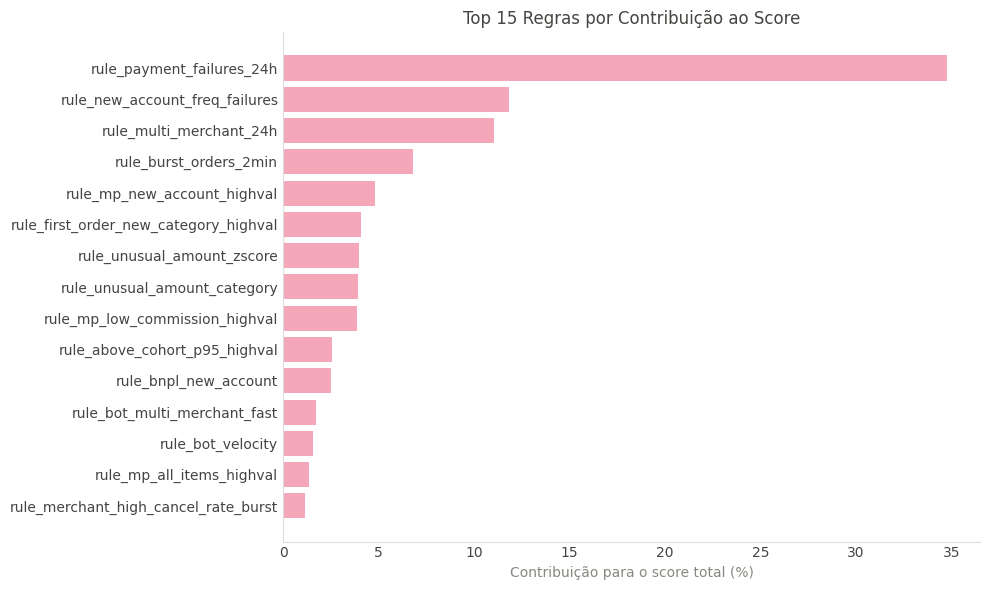

In [60]:
# Contribuição de cada regra para o score final
weights =CONFIG ['rule_weights']
total_scored =max ((df [rule_cols ]*pd .Series ({r :weights .get (r ,0 )for r in rule_cols })).sum ().sum (),1 )

contrib =pd .DataFrame ({
'weight':[weights .get (r ,0 )for r in rule_cols ],
'fired_count':df [rule_cols ].sum ().values ,
'contrib_mean':[(df [r ]*weights .get (r ,0 )).mean ()for r in rule_cols ],
'contrib_total':[(df [r ]*weights .get (r ,0 )).sum ()for r in rule_cols ],
'contrib_pct':[(df [r ]*weights .get (r ,0 )).sum ()/total_scored *100 for r in rule_cols ],
},index =rule_cols ).sort_values ('contrib_total',ascending =False )

print ('Contribuição de cada regra para o score total (top 15):')
display (contrib .head (15 ).round (3 ))

TEXT_MAIN ='#444441'
TEXT_SUB ='#888780'
AXIS_LINE ='#dddddd'
PINK_LIGHT ='#f4a7b9'
PINK_MAIN ='#e8637a'
PINK_DARK ='#c0253d'

top =contrib .head (15 )

fig ,ax =plt .subplots (figsize =(10 ,6 ))

bars =ax .barh (
top .index [::-1 ],
top ['contrib_pct'][::-1 ],
color =PINK_LIGHT ,
edgecolor ='none'
)

ax .set_xlabel ('Contribuição para o score total (%)',color =TEXT_SUB )
ax .set_title ('Top 15 Regras por Contribuição ao Score',color =TEXT_MAIN ,fontweight ='500')

ax .grid (False )

for spine in ax .spines .values ():
    spine .set_visible (False )
ax .spines ['bottom'].set_visible (True )
ax .spines ['bottom'].set_color (AXIS_LINE )
ax .spines ['left'].set_visible (True )
ax .spines ['left'].set_color (AXIS_LINE )

ax .tick_params (axis ='both',length =0 ,colors =TEXT_MAIN )

plt .tight_layout ()
plt .show ()


### Recomendações de Ajuste de Pesos

Em modo de teste, esta secção aplica bandas simples de decisão com base em lift, taxa de disparo e contributo total para o score. O objetivo é sinalizar regras para revisão, não reescrever automaticamente a calibração.




In [61]:
if CONFIG .get ('mode')=='test':
    rule_reco =ra .copy ()
    rule_reco ['rule_key']='rule_'+rule_reco ['rule']
    rule_reco =rule_reco .merge (
    rule_analysis [['fired_count','fire_rate_%']],
    left_on ='rule_key',
    right_index =True ,
    how ='left'
    )
    rule_reco =rule_reco .merge (
    contrib [['contrib_total','contrib_pct']],
    left_on ='rule_key',
    right_index =True ,
    how ='left'
    )
    rule_reco ['current_weight']=rule_reco ['rule_key'].map (lambda r :CONFIG ['rule_weights'].get (r ,0 ))

    suggested_change =[]
    suggested_reason =[]
    suggested_bucket =[]

    for _ ,row in rule_reco .iterrows ():
        lift =row ['lift']
        fire_rate =row ['fire_rate_%']
        contrib_pct =row ['contrib_pct']if pd .notna (row ['contrib_pct'])else 0 
        fired =row ['fired_count']if pd .notna (row ['fired_count'])else 0 

        change =0 
        bucket ='Manter'
        reason ='Faixa intermédia ou sem evidência suficiente para ajuste.'

        if fired ==0 or fire_rate ==0 :
            bucket ='Regra morta'
            reason ='Não ajustar antes de confirmar se a feature existe e se a regra deve continuar ativa.'
        elif lift <4 and fire_rate >0.5 :
            if contrib_pct >=10 :
                change =-15 
                bucket ='Baixar com cautela'
                reason ='Lift fraco, firing relativamente alto e contributo relevante para o score.'
            else :
                change =-20 
                bucket ='Baixar'
                reason ='Lift fraco com firing relativamente alto.'
        elif 4 <=lift <8 :
            if fire_rate >1.0 and contrib_pct >5 :
                change =-10 
                bucket ='Ajuste ligeiro'
                reason ='Lift intermédio com alguma pressão operacional; reduzir ligeiramente se necessário.'
            else :
                bucket ='Manter'
                reason ='Lift intermédio; observar antes de mexer mais.'
        elif lift >=20 and fire_rate <0.05 :
            change =5 
            bucket ='Subir muito ligeiramente'
            reason ='Lift alto mas amostra frágil; mexer pouco.'
        elif lift >=15 and fire_rate <1 :
            if contrib_pct >=10 :
                change =10 
                bucket ='Subir ligeiramente'
                reason ='Lift forte, firing controlado, mas a regra já pesa bastante no score total.'
            elif fire_rate <0.5 and contrib_pct <5 :
                change =20 
                bucket ='Subir'
                reason ='Lift forte e firing controlado com contributo ainda moderado.'
            else :
                change =15 
                bucket ='Subir'
                reason ='Lift forte e firing controlado.'

        suggested_change .append (change )
        suggested_bucket .append (bucket )
        suggested_reason .append (reason )

    rule_reco ['suggested_change_pct']=suggested_change 
    rule_reco ['suggested_bucket']=suggested_bucket 
    rule_reco ['suggested_reason']=suggested_reason 
    rule_reco ['suggested_weight']=(rule_reco ['current_weight']*(1 +rule_reco ['suggested_change_pct']/100 )).round (1 )

    focus_rules ={
    'above_cohort_p95_highval':'Observar para subida ligeira.',
    'mp_low_commission_highval':'Observar para subida ligeira.',
    'mp_new_account_highval':'Observar para subida ligeira.',
    'bnpl_new_account':'Observar para subida ligeira.',
    'retry_fast':'Lift forte mas amostra muito pequena; não subir agressivamente.',
    'card_testing':'Lift forte mas amostra muito pequena; não subir agressivamente.',
    }
    rule_reco ['manual_focus']=rule_reco ['rule'].map (focus_rules ).fillna ('')

    rule_reco_display =rule_reco [[
    'rule','global_%','flagged_%','lift','fire_rate_%',
    'contrib_pct','current_weight','suggested_change_pct',
    'suggested_weight','suggested_bucket','suggested_reason','manual_focus'
    ]].sort_values (['suggested_change_pct','lift'],ascending =[False ,False ])

    print ('Recomendações de ajuste de pesos por bandas:')
    display (rule_reco_display .round (3 ))
else :
    print ('Recomendações de ajuste de pesos disponíveis apenas em modo testee.')




Recomendações de ajuste de pesos por bandas:


,rule,global_%,flagged_%,lift,fire_rate_%,contrib_pct,current_weight,suggested_change_pct,suggested_weight,suggested_bucket,suggested_reason,manual_focus
22,bnpl_new_account,0.342,8.457,24.714,0.340,2.533,23,20,27.600,Subir,Lift forte e firing controlado com contributo ...,Observar para subida ligeira.
14,mp_all_items_highval,0.208,5.122,24.673,0.210,1.336,20,20,24.000,Subir,Lift forte e firing controlado com contributo ...,
3,freq_highval_new_account,0.054,1.318,24.392,0.050,0.261,15,20,18.000,Subir,Lift forte e firing controlado com contributo ...,
31,bot_velocity,0.138,3.279,23.782,0.140,1.553,35,20,42.000,Subir,Lift forte e firing controlado com contributo ...,
6,payment_failures_30d,0.051,1.110,21.695,0.050,0.115,7,20,8.400,Subir,Lift forte e firing controlado com contributo ...,
18,name_mismatch_mp_highval,0.082,1.663,20.254,0.080,0.529,20,20,24.000,Subir,Lift forte e firing controlado com contributo ...,
8,new_payment_method_highval,0.198,3.898,19.665,0.200,0.638,10,20,12.000,Subir,Lift forte e firing controlado com contributo ...,
26,user_merchant_concentration,0.078,1.375,17.647,0.080,0.376,15,20,18.000,Subir,Lift forte e firing controlado com contributo ...,
9,amount_above_prev_max,0.110,1.914,17.427,0.110,0.707,20,20,24.000,Subir,Lift forte e firing controlado com contributo ...,
32,bot_multi_merchant_fast,0.181,2.929,16.198,0.180,1.746,30,20,36.000,Subir,Lift forte e firing controlado com contributo ...,


### Frequência e Contribuição das Regras

As tabelas e o gráfico seguintes mostram quais as regras com maior ativação, maior contributo para o score e maior relevância.



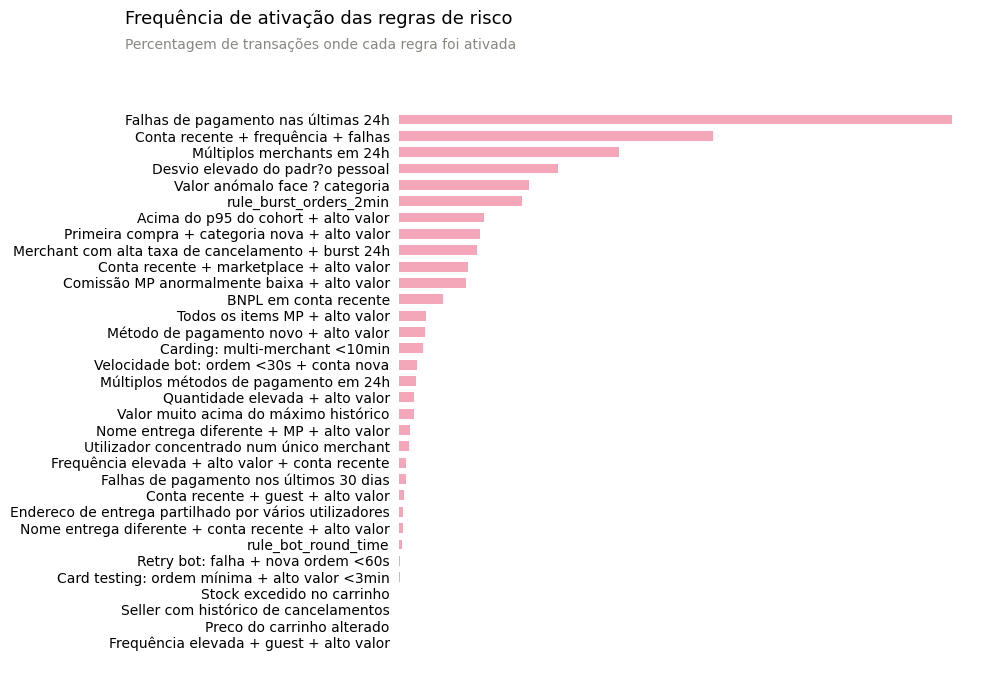

In [62]:
rule_act =pd .DataFrame ({
'regra':RULE_COLS ,
'peso':[CONFIG ['rule_weights'][r ]for r in RULE_COLS ],
'ativações':[int (df [r ].sum ())for r in RULE_COLS ],
'pct':[df [r ].mean ()*100 for r in RULE_COLS ],
}).sort_values ('pct',ascending =True )

rule_act ['label']=[RULE_LABELS .get (r ,r )for r in rule_act ['regra']]

fig ,ax =plt .subplots (figsize =(10 ,7 ))
ax .barh (rule_act ['label'],rule_act ['pct'],color ='#f4a7b9',height =0.6 )

fig .text (0.13 ,0.97 ,'Frequência de ativação das regras de risco',fontsize =13 ,fontweight ='500',va ='top')
fig .text (0.13 ,0.93 ,'Percentagem de transações onde cada regra foi ativada',fontsize =10 ,color ='#888780',va ='top')

ax .set_title ('')
ax .set_xlabel ('')
ax .grid (False )
for spine in ax .spines .values ():
    spine .set_visible (False )
ax .tick_params (left =False ,bottom =False )
ax .xaxis .set_ticklabels ([])

plt .subplots_adjust (top =0.88 )
plt .tight_layout (rect =[0 ,0 ,1 ,0.88 ])

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_regras.png',dpi =150 ,bbox_inches ='tight')

plt .show ()

In [63]:
exclude_cols =set (rule_cols )|{
'risk_score','rules_score','rules_score_raw',
'ml_anomaly_score','ml_is_anomaly',
'hard_block_rule'
}

num_cols =[
c for c in df .select_dtypes (include ='number').columns 
if c not in exclude_cols 
]

baseline =df [num_cols ].median ().to_dict ()

casos =[
{
'descrição':'Conta recente + alto valor + falhas 24h + frequência',
'account_age_days':1 ,
'is_high_value_order':1 ,
'num_orders_24h':6 ,
'prev_failures_1d':10 ,
'prev_failures_7d':12 ,
},
{
'descrição':'Guest checkout + alto valor + conta recente',
'is_guest':1 ,
'is_high_value_order':1 ,
'email_pattern_score':0.8 ,
'account_age_days':3 ,
},
{
'descrição':'Burst de atividade + multi-merchant + alto valor',
'num_orders_24h':8 ,
'distinct_merchants_24h':5 ,
'seconds_since_prev_order':30 ,
'is_high_value_order':1 ,
'account_age_days':2 ,
},
{
'descrição':'Método de pagamento novo + alto valor + conta recente',
'is_new_payment_method':1 ,
'is_high_value_order':1 ,
'account_age_days':10 ,
'prev_total_orders':3 ,
},
{
'descrição':'Cliente leal com comportamento normal',
'prev_total_orders':200 ,
'account_age_days':1000 ,
'is_high_value_order':0 ,
'prev_failures_1d':0 ,
'prev_failures_7d':0 ,
'prev_failures_30d':0 ,
'num_orders_24h':1 ,
'is_guest':0 ,
'email_pattern_score':0.0 ,
},
]

rows =[]
for caso in casos :
    row =_copy .copy (baseline )
    row .update ({k :v for k ,v in caso .items ()if k !='descrição'})
    rows .append (row )

df_synth =pd .DataFrame (rows ).fillna (0 )

for col in [
'user_key',
'order_id',
'customer_on_purchase_email',
'payment_method_method',
'billing_address_country',
'delivery_address_country',
'store_id',
'categoria_pai',
]:
    if col not in df_synth .columns :
        df_synth [col ]='test'

if 'createdAt'not in df_synth .columns :
    df_synth ['createdAt']=pd .Timestamp ('2025-06-01',tz ='UTC')

fallback_defaults ={
'prev_failures_1d':0 ,
'prev_failures_3d':0 ,
'prev_failures_7d':0 ,
'prev_failures_30d':0 ,
'distinct_merchants_24h':1 ,
'num_orders_24h':0 ,
'is_guest':0 ,
'is_high_value_order':0 ,
'email_pattern_score':0.0 ,
'account_age_days':365 ,
'prev_total_orders':1 ,
'is_new_payment_method':0 ,
'seconds_since_prev_order':9999 ,
}
for col ,default in fallback_defaults .items ():
    if col not in df_synth .columns :
        df_synth [col ]=default 

_config_synth =_copy .deepcopy (CONFIG )
df_synth ,_ =apply_rules (df_synth ,_config_synth )

print ('Resultados dos casos sinteticos (regras):\n')

r_cols =[c for c in df_synth .columns if c .startswith ('rule_')]

for i ,caso in enumerate (casos ):
    row =df_synth .iloc [i ]
    regras =[r for r in r_cols if row .get (r ,0 )==1 ]
    print (f'  {caso ["descrição"]}')
    print (f'    rules_score={row ["rules_score"]:.1f}')
    print (f'    regras ativas ({len (regras )}): {regras }\n')

Resultados dos casos sinteticos (regras):

  Conta recente + alto valor + falhas 24h + frequência
    rules_score=100.0
    regras ativas (4): ['rule_new_account_freq_failures', 'rule_freq_highval_new_account', 'rule_payment_failures_24h', 'rule_mp_new_account_highval']

  Guest checkout + alto valor + conta recente
    rules_score=40.3
    regras ativas (1): ['rule_new_account_guest_highval']

  Burst de atividade + multi-merchant + alto valor
    rules_score=100.0
    regras ativas (4): ['rule_freq_highval_new_account', 'rule_multi_merchant_24h', 'rule_burst_orders_2min', 'rule_bot_multi_merchant_fast']

  Método de pagamento novo + alto valor + conta recente
    rules_score=16.1
    regras ativas (1): ['rule_new_payment_method_highval']

  Cliente leal com comportamento normal
    rules_score=0.0
    regras ativas (0): []



,n_ordens,valor_total,valor_medio,valor_mediano,score_medio,score_max
risk_level,,,,,,
Baixo,481385,81568053.600,169.440,43.920,6.920,29.900
Moderado,21106,14242152.760,674.790,383.690,42.380,59.900
Alto,9841,6215069.630,631.550,229.530,69.990,79.900
Crítico,11324,8038911.720,709.900,20.290,88.740,100.000


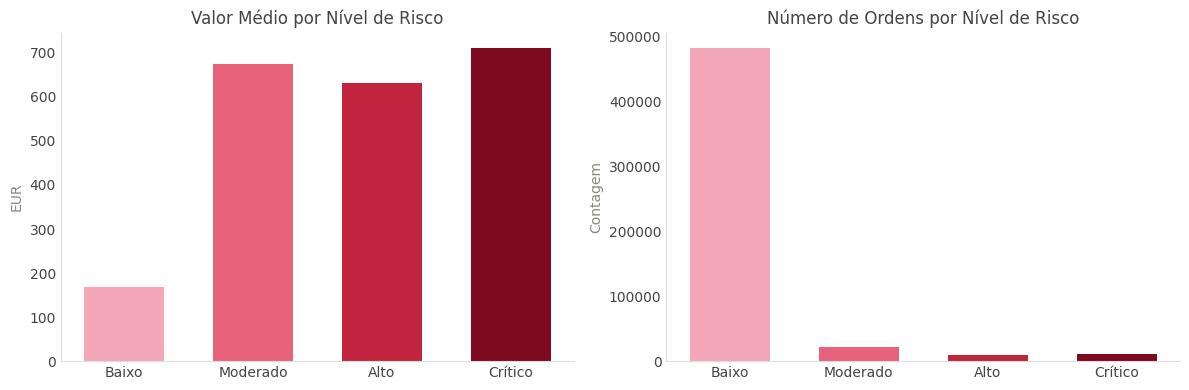

Ratio valor médio Alto/Baixo: 3.73x
  OK  transações de alto risco têm valor médio substancialmente maior.


In [64]:
# Score vs Valor em Risco por nível
order_map ={'Baixo':0 ,'Moderado':1 ,'Alto':2 ,'Crítico':3 }

risk_value =(
df .groupby ('risk_level')
.agg (
n_ordens =('order_id','count'),
valor_total =('total_amount','sum'),
valor_medio =('total_amount','mean'),
valor_mediano =('total_amount','median'),
score_medio =('risk_score','mean'),
score_max =('risk_score','max'),
).round (2 )
)

risk_value =risk_value .loc [[k for k in order_map if k in risk_value .index ]]
display (risk_value )

RISK_COLORS ={
'Baixo':'#f4a7b9',
'Moderado':'#e8637a',
'Alto':'#c0253d',
'Crítico':'#7d0a1e',
}

TEXT_MAIN ='#444441'
TEXT_SUB ='#888780'
AXIS_LINE ='#dddddd'

lvls =risk_value .index .tolist ()
cols_plot =[RISK_COLORS [lvl ]for lvl in lvls ]

fig ,axes =plt .subplots (1 ,2 ,figsize =(12 ,4 ))

# Painel 1
axes [0 ].bar (lvls ,risk_value ['valor_medio'],color =cols_plot ,width =0.62 )
axes [0 ].set_title ('Valor Médio por Nível de Risco',color =TEXT_MAIN ,fontweight ='500')
axes [0 ].set_ylabel ('EUR',color =TEXT_SUB )
axes [0 ].grid (False )

for spine in axes [0 ].spines .values ():
    spine .set_visible (False )
axes [0 ].spines ['bottom'].set_visible (True )
axes [0 ].spines ['bottom'].set_color (AXIS_LINE )
axes [0 ].spines ['left'].set_visible (True )
axes [0 ].spines ['left'].set_color (AXIS_LINE )
axes [0 ].tick_params (axis ='both',length =0 ,colors =TEXT_MAIN )

# Painel 2
axes [1 ].bar (lvls ,risk_value ['n_ordens'],color =cols_plot ,width =0.62 )
axes [1 ].set_title ('Número de Ordens por Nível de Risco',color =TEXT_MAIN ,fontweight ='500')
axes [1 ].set_ylabel ('Contagem',color =TEXT_SUB )
axes [1 ].grid (False )

for spine in axes [1 ].spines .values ():
    spine .set_visible (False )
axes [1 ].spines ['bottom'].set_visible (True )
axes [1 ].spines ['bottom'].set_color (AXIS_LINE )
axes [1 ].spines ['left'].set_visible (True )
axes [1 ].spines ['left'].set_color (AXIS_LINE )
axes [1 ].tick_params (axis ='both',length =0 ,colors =TEXT_MAIN )

plt .tight_layout ()
plt .show ()

if 'Baixo'in risk_value .index and 'Alto'in risk_value .index :
    ratio =risk_value .loc ['Alto','valor_medio']/risk_value .loc ['Baixo','valor_medio']
    print (f'Ratio valor médio Alto/Baixo: {ratio :.2f}x')
    if ratio <1.5 :
        print ('  AVISO: ratio baixo  thresholds de valor podem estar mal calibrados.')
    else :
        print ('  OK  transações de alto risco têm valor médio substancialmente maior.')


## 18. Métricas com Labels Proxy

Na ausência de labels de fraude confirmadas para todo o universo analisado, utiliza-se `hard_block_rule == 1` como proxy operacional de comportamento muito suspeito. Esta apróximação não substitui validação humana, mas permite obter uma leitura preliminar de precisão, recall, lift e sensibilidade a thresholds usando a regra de bloqueio forte como referência.

Os resultados desta secção devem ser interpretados como apoio à calibração e não como medida final de desempenho do sistema. 

A métrica proxy é útil para comparação relativa de thresholds, mas não deve ser apresentada como taxa real de fraude confirmada.

In [65]:
# Label proxy: hard block rule
PROXY_LABEL_COL =CONFIG .get ('proxy_label_col','hard_block_rule')
if PROXY_LABEL_COL in df .columns :
    y_proxy =df [PROXY_LABEL_COL ].fillna (0 ).astype (int )
else :
    y_proxy =pd .Series (0 ,index =df .index )

n_pos =int (y_proxy .sum ())
print (f'Label proxy ({PROXY_LABEL_COL }): {n_pos :,} transações ({n_pos /len (df )*100 :.1f}% do total)')
print ()

rows_pr =[]
for t in [30 ,40 ,50 ,60 ,70 ,80 ,90 ]:
    y_pred =(df ['risk_score']>=t ).astype (int )
    if y_pred .sum ()==0 :
        continue 
    p =precision_score (y_proxy ,y_pred ,zero_division =0 )
    r =recall_score (y_proxy ,y_pred ,zero_division =0 )
    f1v =f1_score (y_proxy ,y_pred ,zero_division =0 )
    tn ,fp ,fn ,tp =confusion_matrix (y_proxy ,y_pred ,labels =[0 ,1 ]).ravel ()
    fpr =fp /(fp +tn )if (fp +tn )>0 else 0 
    pct =y_pred .mean ()*100 
    vol =df .loc [df ['risk_score']>=t ,'total_amount'].sum ()/1000 
    rows_pr .append ({'Threshold':t ,'Precision':round (p ,3 ),'Recall':round (r ,3 ),'F1':round (f1v ,3 ),'FPR':round (fpr ,3 ),'Sinalizadas%':round (pct ,1 ),'Volume_kEUR':round (vol ,1 )})
display (pd .DataFrame (rows_pr ))

Label proxy (hard_block_rule): 126 transações (0.0% do total)



,Threshold,Precision,Recall,F1,FPR,Sinalizadas%,Volume_kEUR
0,30,0.003,1.000,0.006,0.081,8.100,28496.100
1,40,0.004,1.000,0.008,0.061,6.100,21100.200
2,50,0.005,1.000,0.009,0.051,5.100,17395.100
3,60,0.006,1.000,0.012,0.040,4.000,14254.000
4,70,0.008,1.000,0.015,0.031,3.100,11337.700
5,80,0.011,1.000,0.022,0.021,2.200,8038.900
6,90,0.030,1.000,0.058,0.008,0.800,3549.000


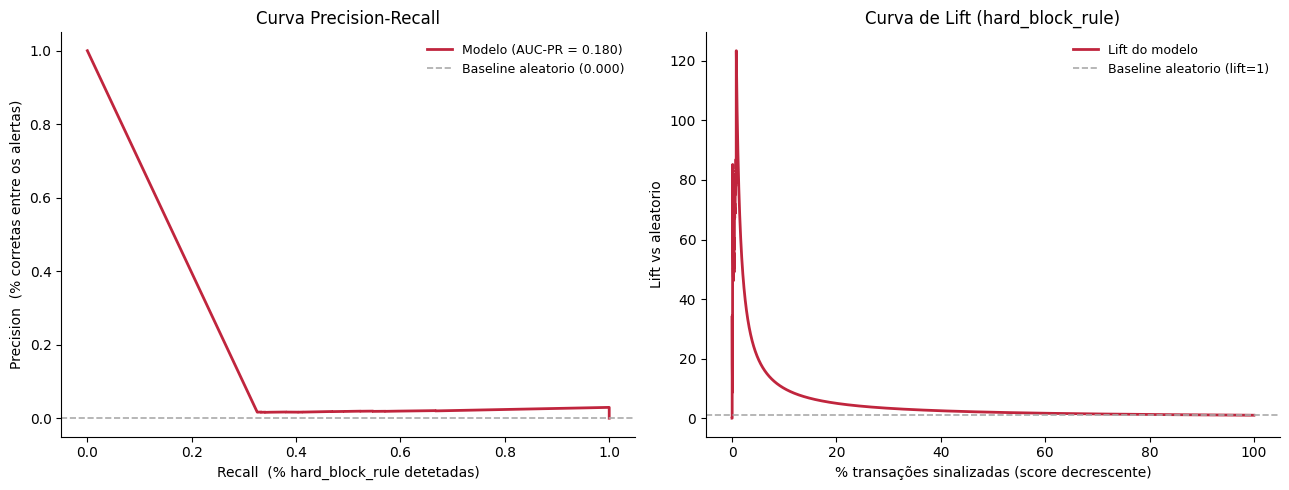

AUC-PR: 0.1801  (baseline = 0.0002  | lift max disponível = 4156.0x)


In [94]:
# Curva Precision-Recall e Curva de Lift
if y_proxy.sum() > 0:
    y_scores_norm = df['risk_score'].values / 100
    prec_vals, rec_vals, _ = precision_recall_curve(y_proxy, y_scores_norm)
    pr_auc = auc(rec_vals, prec_vals)

    n_total = len(df)
    n_proxy = int(y_proxy.sum())

    df_lift = (
        df.assign(_y=y_proxy.values)
        .sort_values('risk_score', ascending=False)
        .reset_index(drop=True)
    )
    df_lift['_cum_proxy'] = df_lift['_y'].cumsum()
    df_lift['_pct_pop'] = (df_lift.index + 1) / n_total
    df_lift['_lift'] = (df_lift['_cum_proxy'] / n_proxy) / df_lift['_pct_pop']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    baseline_p = y_proxy.mean()

    ax1.plot(
        rec_vals,
        prec_vals,
        color='#c0253d',
        linewidth=2,
        label=f'Modelo (AUC-PR = {pr_auc:.3f})'
    )
    ax1.axhline(
        baseline_p,
        linestyle='--',
        color='#aaa',
        linewidth=1.2,
        label=f'Baseline aleatorio ({baseline_p:.3f})'
    )
    ax1.set_xlabel(f'Recall  (% {PROXY_LABEL_COL} detetadas)')
    ax1.set_ylabel('Precision  (% corretas entre os alertas)')
    ax1.set_title('Curva Precision-Recall', fontweight='500')
    ax1.legend(fontsize=9, frameon=False)
    ax1.grid(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2.plot(
        df_lift['_pct_pop'] * 100,
        df_lift['_lift'],
        color='#c0253d',
        linewidth=2,
        label='Lift do modelo'
    )
    ax2.axhline(
        1,
        linestyle='--',
        color='#aaa',
        linewidth=1.2,
        label='Baseline aleatorio (lift=1)'
    )
    ax2.set_xlabel('% transações sinalizadas (score decrescente)')
    ax2.set_ylabel('Lift vs aleatorio')
    ax2.set_title(f'Curva de Lift ({PROXY_LABEL_COL})', fontweight='500')
    ax2.legend(fontsize=9, frameon=False)
    ax2.grid(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()

    if CONFIG['save_figures']:
        plt.savefig(f'{CONFIG["output_prefix"]}_pr_lift.png', dpi=150, bbox_inches='tight')

    plt.show()

    print(f'AUC-PR: {pr_auc:.4f}  (baseline = {baseline_p:.4f}  | lift max disponível = {1 / baseline_p:.1f}x)')
else:
    print(f'Curvas PR/lift indisponíveis: a proxy {PROXY_LABEL_COL} não tem positivos.')


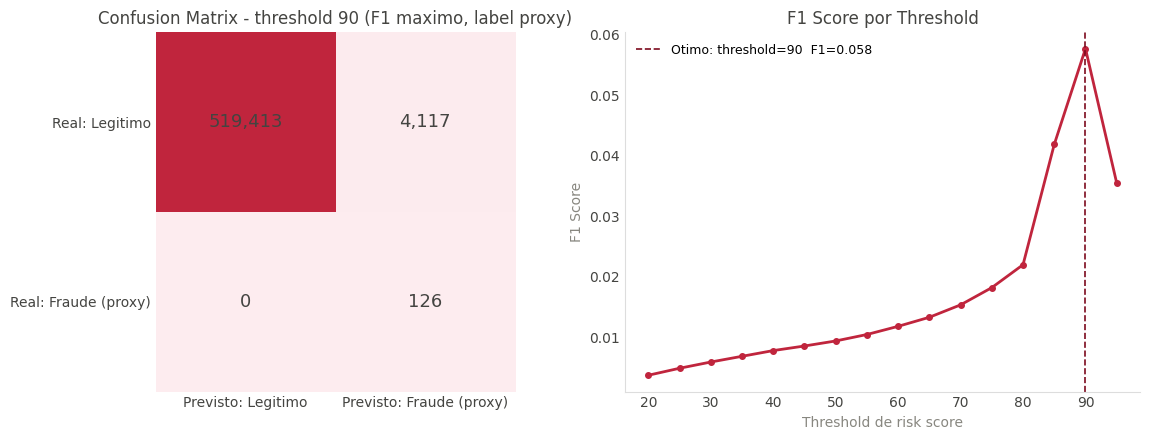

: 

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

thresholds_sweep = list(range(20, 96, 5))
f1s_sweep = [
    f1_score(y_proxy, (df['risk_score'] >= t).astype(int), zero_division=0)
    for t in thresholds_sweep
]
best_t = thresholds_sweep[int(np.argmax(f1s_sweep))]
y_pred_best = (df['risk_score'] >= best_t).astype(int)

cm = confusion_matrix(y_proxy, y_pred_best)
tn, fp, fn, tp = cm.ravel()

TEXT_MAIN = '#444441'
TEXT_SUB = '#888780'
PINK_MAIN = '#c0253d'
PINK_DARK = '#7d0a1e'
AXIS_LINE = '#dddddd'

pink_cm = LinearSegmentedColormap.from_list(
    'custom_pink',
    ['#fdecef', '#f7c6d0', '#e8637a', '#c0253d']
)

fig, (ax_cm, ax_f1) = plt.subplots(1, 2, figsize=(12, 4.5))

im = ax_cm.imshow(
    cm,
    cmap=pink_cm,
    aspect='equal',
    interpolation='none'
)

ax_cm.grid(False)
ax_cm.minorticks_off()

ax_cm.set_xticks([0, 1])
ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Previsto: Legitimo', 'Previsto: Fraude (proxy)'], color=TEXT_MAIN)
ax_cm.set_yticklabels(['Real: Legitimo', 'Real: Fraude (proxy)'], color=TEXT_MAIN)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(
            j,
            i,
            f'{cm[i, j]:,}',
            ha='center',
            va='center',
            fontsize=13,
            fontweight='500',
            color=TEXT_MAIN
        )

ax_cm.set_title(
    f'Confusion Matrix - threshold {best_t} (F1 máximo, label proxy)',
    fontweight='500',
    color=TEXT_MAIN
)
ax_cm.set_xlabel('')
ax_cm.set_ylabel('')
ax_cm.tick_params(axis='both', which='both', length=0, colors=TEXT_MAIN)

for spine in ax_cm.spines.values():
    spine.set_visible(False)

# Curva F1
ax_f1.plot(
    thresholds_sweep,
    f1s_sweep,
    color=PINK_MAIN,
    linewidth=2,
    marker='o',
    markersize=4
)
ax_f1.axvline(
    best_t,
    linestyle='--',
    color=PINK_DARK,
    linewidth=1.2,
    label=f'Otimo: threshold={best_t}  F1={max(f1s_sweep):.3f}'
)

ax_f1.set_xlabel('Threshold de risk score', color=TEXT_SUB)
ax_f1.set_ylabel('F1 Score', color=TEXT_SUB)
ax_f1.set_title('F1 Score por Threshold', fontweight='500', color=TEXT_MAIN)
ax_f1.legend(fontsize=9, frameon=False)
ax_f1.grid(False)
ax_f1.minorticks_off()

for spine in ax_f1.spines.values():
    spine.set_visible(False)

ax_f1.spines['bottom'].set_visible(True)
ax_f1.spines['bottom'].set_color(AXIS_LINE)
ax_f1.spines['left'].set_visible(True)
ax_f1.spines['left'].set_color(AXIS_LINE)
ax_f1.tick_params(axis='both', which='both', length=0, colors=TEXT_MAIN)

plt.tight_layout()

if CONFIG['save_figures']:
    plt.savefig(f'{CONFIG["output_prefix"]}_confusion.png', dpi=150, bbox_inches='tight')

plt.show()


In [68]:
# Validação por proxy
if PROXY_LABEL_COL in df .columns :
    print (f'Score médio por {PROXY_LABEL_COL }:')
    display (df .groupby (PROXY_LABEL_COL )['risk_score'].describe ().round (2 ))
    print (f'\nDistribuicao de nível de risco por {PROXY_LABEL_COL }:')
    cross =df .groupby (['risk_level',PROXY_LABEL_COL ]).size ().unstack (fill_value =0 )
    cross_pct =cross .div (cross .sum (axis =0 ),axis =1 ).mul (100 ).round (1 )
    display (cross )
    display (cross_pct .rename (columns =lambda c :f'{PROXY_LABEL_COL }={c } (%)'))
else :
    print (f'Validação por proxy indisponível: coluna {PROXY_LABEL_COL } não encontrada.')

Score médio por hard_block_rule:


,count,mean,std,min,25%,50%,75%,max
hard_block_rule,,,,,,,,
0,523530.000,11.280,17.030,0.000,2.300,6.000,11.900,100.000
1,126.000,94.680,4.350,90.000,90.000,94.100,100.000,100.000



Distribuicao de nível de risco por hard_block_rule:


hard_block_rule,0,1
risk_level,,
Alto,9841,0
Baixo,481385,0
Crítico,11198,126
Moderado,21106,0


hard_block_rule,hard_block_rule=0 (%),hard_block_rule=1 (%)
risk_level,,
Alto,1.900,0.000
Baixo,91.900,0.000
Crítico,2.100,100.000
Moderado,4.000,0.000


### Diagnóstico do Peso do ML e Thresholds Recentes

Em modo de teste, este bloco verifica se o ML está a contribuir de forma material para o score final. 

Resume amplitude do `ml_anomaly_score`, percentis por nível de risco, correlação com o score final e quantas transações mudam de nível quando o peso do ML sobe ou desce.




In [69]:
if CONFIG .get ('mode')=='test':
    print ('Amplitude real do ml_anomaly_score:')
    display (df ['ml_anomaly_score'].describe (percentiles =[0.01 ,0.05 ,0.25 ,0.5 ,0.75 ,0.95 ,0.99 ]).round (3 ).to_frame ('ml_anomaly_score'))

    ml_by_risk =(
    df .groupby ('risk_level')['ml_anomaly_score']
    .agg (['count','mean','median',lambda x :x .quantile (0.95 ),'min','max'])
    .rename (columns ={'<lambda_0>':'p95'})
    )
    print ('\nPercentis do score ML por nível de risco:')
    display (ml_by_risk .round (3 ))

    corr_cols =[c for c in ['rules_score','ml_anomaly_score','risk_score']if c in df .columns ]
    if len (corr_cols )>=2 :
        print ('\nCorrelação entre scores:')
        display (df [corr_cols ].corr ().round (3 ))

    base_w_rules =CONFIG ['scoring']['w_rules']
    base_w_ml =CONFIG ['scoring']['w_ml']
    base_total =base_w_rules +base_w_ml 

    weight_scenarios =[]
    for mult ,label in [(0.8 ,'ML -20%'),(1.0 ,'Base'),(1.2 ,'ML +20%')]:
        cfg_alt =_copy .deepcopy (CONFIG )
        alt_w_ml =base_w_ml *mult 
        scale =base_total /(base_w_rules +alt_w_ml )
        cfg_alt ['scoring']['w_rules']=round (base_w_rules *scale ,6 )
        cfg_alt ['scoring']['w_ml']=round (alt_w_ml *scale ,6 )

        df_alt =combine_scores (df .copy (),cfg_alt )
        changed_pct =np .nan if label =='Base'else (df_alt ['risk_level']!=df ['risk_level']).mean ()*100 

        weight_scenarios .append ({
        'cenario':label ,
        'w_rules':cfg_alt ['scoring']['w_rules'],
        'w_ml':cfg_alt ['scoring']['w_ml'],
        'score_medio':round (df_alt ['risk_score'].mean (),2 ),
        'pct_alto_critico':round (df_alt ['risk_level'].isin (['Alto','Crítico']).mean ()*100 ,2 ),
        'pct_nivel_alterado_vs_base':round (changed_pct ,2 )if not np .isnan (changed_pct )else 0.0 ,
        })

    ml_weight_scenarios =pd .DataFrame (weight_scenarios )
    print ('\nSensibilidade do nível final ao peso do ML:')
    display (ml_weight_scenarios )

    if 'createdAt'in df .columns and 'y_proxy'in globals ():
        created_dt =pd .to_datetime (df ['createdAt'],errors ='coerce')
        recent_cutoff =created_dt .max ()-pd .Timedelta (days =60 )
        recent_mask =created_dt >=recent_cutoff 

        recent_threshold_eval =[]
        for t in [20 ,30 ,40 ,50 ,60 ,70 ,80 ]:
            y_pred_recent =(df .loc [recent_mask ,'risk_score']>=t ).astype (int )
            y_recent =y_proxy .loc [recent_mask ]
            if y_pred_recent .sum ()==0 :
                continue 
            recent_threshold_eval .append ({
            'threshold':t ,
            'n_transações_recente':int (recent_mask .sum ()),
            'precision_proxy':round (precision_score (y_recent ,y_pred_recent ,zero_division =0 ),3 ),
            'recall_proxy':round (recall_score (y_recent ,y_pred_recent ,zero_division =0 ),3 ),
            'f1_proxy':round (f1_score (y_recent ,y_pred_recent ,zero_division =0 ),3 ),
            'pct_sinalizadas':round (y_pred_recent .mean ()*100 ,2 ),
            })

        recent_threshold_eval =pd .DataFrame (recent_threshold_eval )
        print ('\nThresholds no período recente (últimos 60 dias, label proxy):')
        display (recent_threshold_eval )
    else :
        print ('\nThresholds recentes indisponíveis: falta createdAt ou y_proxy.')
else :
    print ('Diagnóstico do peso do ML disponível apenas em modo testee.')


Amplitude real do ml_anomaly_score:


,ml_anomaly_score
count,523656.000
mean,18.394
std,20.106
min,0.000
1%,0.000
5%,0.600
25%,4.600
50%,12.100
75%,24.300
95%,61.900



Percentis do score ML por nível de risco:


,count,mean,median,p95,min,max
risk_level,,,,,,
Alto,9841,67.626,67.600,97.600,21.400,100.000
Baixo,481385,13.997,10.700,40.000,0.000,69.900
Crítico,11324,91.652,100.000,100.000,59.900,100.000
Moderado,21106,56.426,58.000,86.600,11.600,100.000



Correlação entre scores:


,rules_score,ml_anomaly_score,risk_score
rules_score,1.000,0.650,0.899
ml_anomaly_score,0.650,1.000,0.914
risk_score,0.899,0.914,1.000



Sensibilidade do nível final ao peso do ML:


,cenario,w_rules,w_ml,score_medio,pct_alto_critico,pct_nivel_alterado_vs_base
0,ML -20%,0.556,0.444,10.550,4.070,0.900
1,Base,0.500,0.500,11.300,4.040,0.000
2,ML +20%,0.455,0.545,11.910,4.050,0.880



Thresholds no período recente (últimos 60 dias, label proxy):


,threshold,n_transações_recente,precision_proxy,recall_proxy,f1_proxy,pct_sinalizadas
0,20,90852,0.004,1.000,0.008,10.720
1,30,90852,0.007,1.000,0.014,5.770
2,40,90852,0.010,1.000,0.020,3.960
3,50,90852,0.014,1.000,0.027,2.920
4,60,90852,0.021,1.000,0.040,1.990
5,70,90852,0.030,1.000,0.059,1.350
6,80,90852,0.052,1.000,0.099,0.780


### Trade-Off Operacional por Threshold
 
 Esta análise mostra o impacto de diferentes thresholds no volume de transações sinalizadas e na exposição financeira associada, apoiando a escolha do ponto de corte operacional.



In [70]:
thresholds =list (range (0 ,101 ,5 ))
blocked_pct =[]
blocked_vol =[]

for t in thresholds :
    mask =df ['risk_score']>=t 
    blocked_pct .append (mask .mean ()*100 )
    blocked_vol .append (df .loc [mask ,'total_amount'].sum ()/1000 )

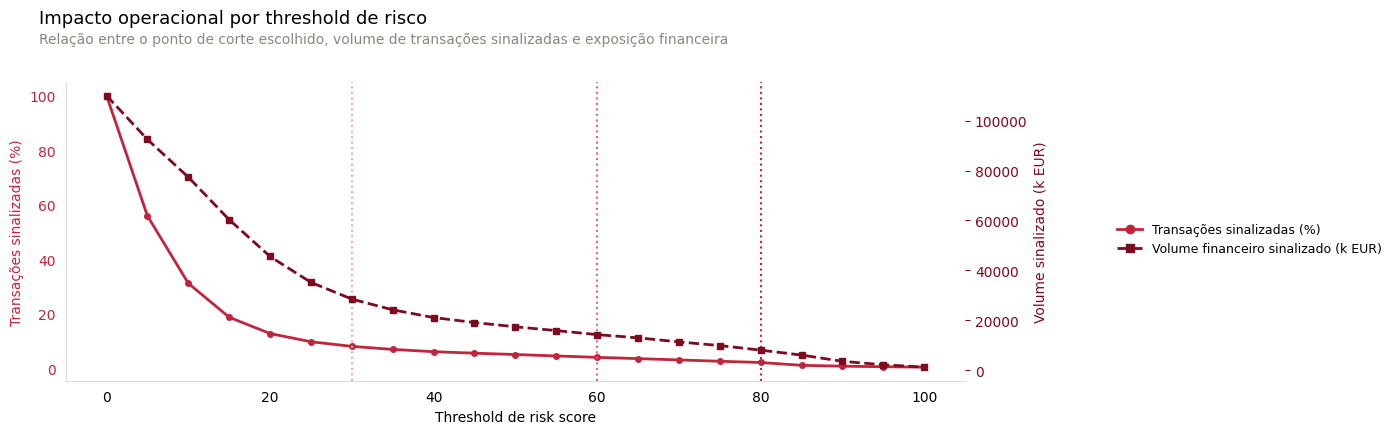

In [71]:
fig ,ax1 =plt .subplots (figsize =(11 ,4 ))
ax2 =ax1 .twinx ()

ax1 .plot (thresholds ,blocked_pct ,color ='#c0253d',linewidth =2 ,marker ='o',markersize =4 ,label ='Transações sinalizadas (%)')
ax2 .plot (thresholds ,blocked_vol ,color ='#7d0a1e',linewidth =2 ,marker ='s',markersize =4 ,linestyle ='--',label ='Volume financeiro sinalizado (k EUR)')

for thresh ,color in [(30 ,'#f4a7b9'),(60 ,'#e8637a'),(80 ,'#c0253d')]:
    ax1 .axvline (thresh ,color =color ,linestyle =':',alpha =1 ,linewidth =1.5 )

ax1 .set_xlabel ('Threshold de risk score')
ax1 .set_ylabel ('Transações sinalizadas (%)',color ='#c0253d')
ax2 .set_ylabel ('Volume sinalizado (k EUR)',color ='#7d0a1e')

ax1 .tick_params (axis ='y',colors ='#c0253d')
ax2 .tick_params (axis ='y',colors ='#7d0a1e')

for ax in [ax1 ,ax2 ]:
    ax .grid (False )
    ax .spines ['top'].set_visible (False )
    ax .spines ['left'].set_color ('#dddddd')
    ax .spines ['bottom'].set_color ('#dddddd')
    ax .spines ['right'].set_color ('#dddddd')
    ax .tick_params (left =False ,bottom =False )

fig .text (0.04 ,1.04 ,'Impacto operacional por threshold de risco',fontsize =13 ,fontweight ='500')
fig .text (0.04 ,0.99 ,'Relação entre o ponto de corte escolhido, volume de transações sinalizadas e exposição financeira',fontsize =10 ,color ='#888780')


legend_handles =[
Line2D ([0 ],[0 ],color ='#c0253d',linewidth =2 ,marker ='o',markersize =6 ,label ='Transações sinalizadas (%)'),
Line2D ([0 ],[0 ],color ='#7d0a1e',linewidth =2 ,marker ='s',markersize =6 ,linestyle ='--',label ='Volume financeiro sinalizado (k EUR)'),
]

fig .legend (
handles =legend_handles ,
fontsize =9 ,
frameon =False ,
bbox_to_anchor =(1.01 ,0.5 ),
loc ='center left',)

plt .tight_layout (rect =[0 ,0 ,0.97 ,0.93 ])

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_tradeoff.png',dpi =150 ,bbox_inches ='tight')

plt .show ()

In [72]:
tradeoff_table =pd .DataFrame ({
'Threshold':thresholds ,
'Transações sinalizadas (%)':blocked_pct ,
'Volume sinalizado (k EUR)':blocked_vol ,
})

display (tradeoff_table [tradeoff_table ['Threshold'].isin ([30 ,50 ,60 ,70 ,80 ,90 ])].round (1 ))

,Threshold,Transações sinalizadas (%),Volume sinalizado (k EUR)
6,30,8.100,28496.100
10,50,5.100,17395.100
12,60,4.000,14254.000
14,70,3.100,11337.700
16,80,2.200,8038.900
18,90,0.800,3549.000


## 19. Síntese Visual do Risco

Esta secção reúne apenas gráficos de síntese e leitura transversal. As análises temáticas detalhadas ficaram nas secções anteriores, junto das respetivas tabelas e métricas.




### Distribuição Global do Score

Primeiro observa-se a distribuição do score final e a classificação por nível de risco, para perceber a separação global entre segmentos.




C:\Users\Inês\AppData\Local\Temp\ipykernel_22604\3319359142.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes [0 ].legend (fontsize =9 ,frameon =False ,loc ='center right')# movida para não sobrepor


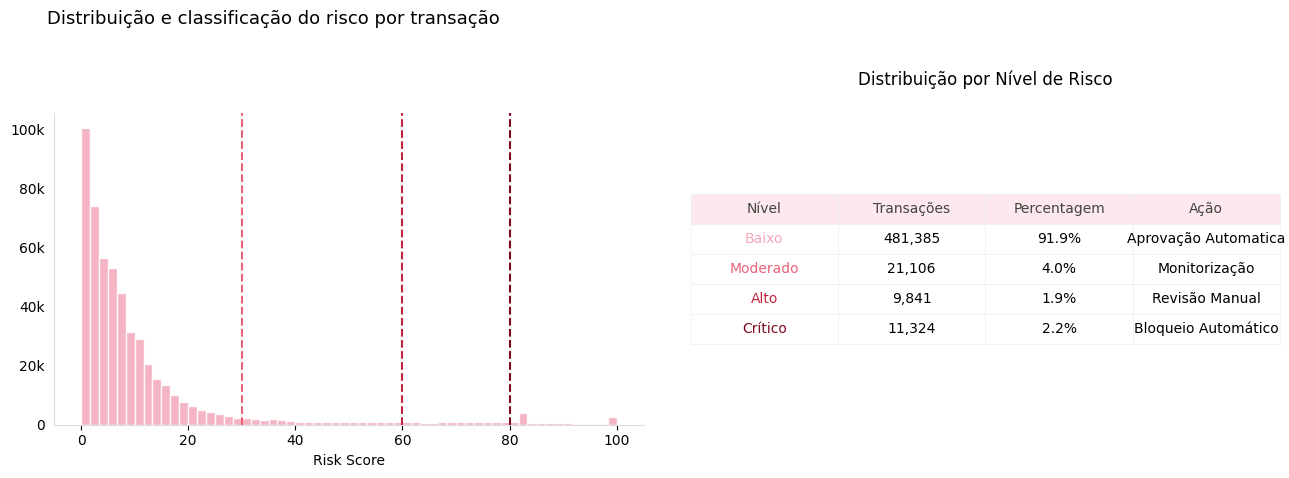

In [73]:
#Distribuição do risk score final
total_orders =len (df )

fig ,axes =plt .subplots (1 ,2 ,figsize =(13 ,4.5 ))

axes [0 ].hist (df ['risk_score'],bins =60 ,color ='#f4a7b9',edgecolor ='white',alpha =0.85 )

for thresh ,color in [
(30 ,'#e8637a'),
(60 ,'#c0253d'),
(80 ,'#7d0a1e')]:
    axes [0 ].axvline (thresh ,color =color ,linestyle ='--',linewidth =1.5 )

axes [0 ].set_xlabel ('Risk Score')
axes [0 ].set_ylabel ('')
axes [0 ].yaxis .set_major_formatter (plt .FuncFormatter (lambda x ,_ :f'{int (x /1000 )}k'if x >=1000 else str (int (x ))))
axes [0 ].grid (False )
axes [0 ].spines ['top'].set_visible (False )
axes [0 ].spines ['right'].set_visible (False )
axes [0 ].spines ['left'].set_color ('#dddddd')
axes [0 ].spines ['bottom'].set_color ('#dddddd')
axes [0 ].tick_params (left =False )
axes [0 ].legend (fontsize =9 ,frameon =False ,loc ='center right')# movida para não sobrepor

# Tabela
counts =df ['risk_level'].value_counts ().reindex (RISK_LEVELS ).fillna (0 )
axes [1 ].axis ('off')
table_data =[[lvl ,f'{int (counts [lvl ]):,}',f'{counts [lvl ]/total_orders *100 :.1f}%',ACTION_MAP [lvl ]]for lvl in RISK_LEVELS ]

table =axes [1 ].table (
cellText =table_data ,
colLabels =['Nível','Transações','Percentagem','Ação'],
cellLoc ='center',
loc ='center',)

table .auto_set_font_size (False )
table .set_fontsize (10 )
table .scale (1 ,2.0 )

for (row ,col ),cell in table .get_celld ().items ():
    cell .set_edgecolor ('#eeeeee')
    cell .set_linewidth (0.5 )
    if row ==0 :
        cell .set_facecolor ('#fce8ed')
        cell .set_text_props (fontweight ='500',color ='#444441')
    else :
        lvl =RISK_LEVELS [row -1 ]
        if col ==0 :
            cell .set_text_props (color =RISK_COLORS [lvl ],fontweight ='500')
        cell .set_facecolor ('white')

axes [1 ].set_title ('Distribuição por Nível de Risco',pad =20 )

fig .text (0.04 ,1.02 ,'Distribuição e classificação do risco por transação',fontsize =13 ,fontweight ='500')

plt .tight_layout (rect =[0 ,0 ,1 ,0.95 ])
plt .subplots_adjust (wspace =0.08 )

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_distribuição.png',dpi =150 ,bbox_inches ='tight')

plt .show ()

### Drivers e Segmentação do Risco

Os gráficos seguintes resumem os principais drivers do modelo e segmentam o risco por valor da encomenda e categoria, ajudando a fechar a leitura executiva do sistema.



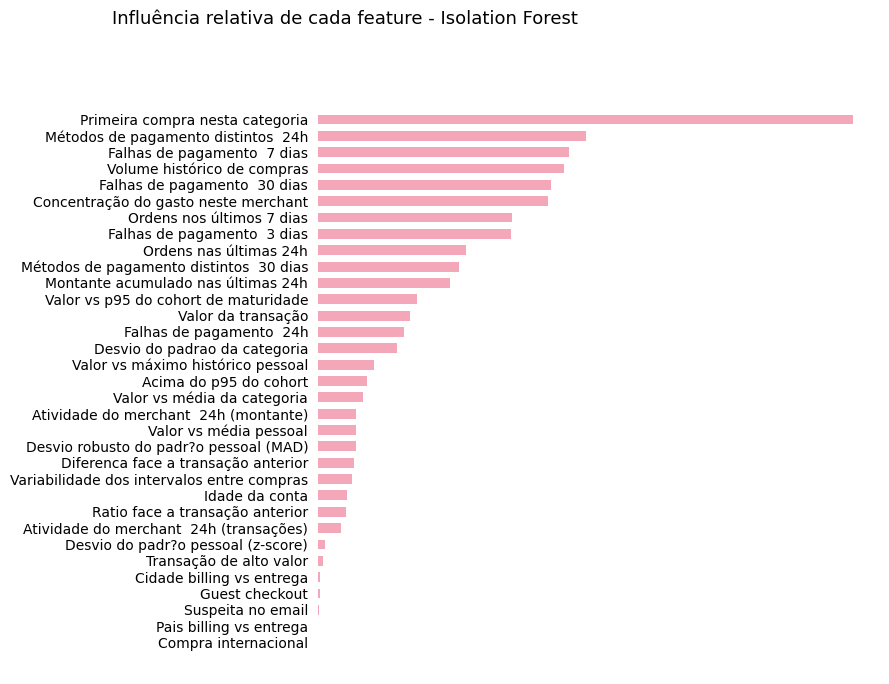

In [74]:
fi_plot =fi .sort_values ('sensitivity',ascending =True ).copy ()
fi_plot .index =[FEATURE_LABELS .get (i ,i )for i in fi_plot .index ]

fig ,ax =plt .subplots (figsize =(9 ,7 ))
ax .barh (fi_plot .index ,fi_plot ['sensitivity'],color ='#f4a7b9',height =0.6 )

fig .text (0.13 ,0.97 ,'Influência relativa de cada feature - Isolation Forest',fontsize =13 ,fontweight ='500',va ='top')

ax .set_title ('')
ax .set_xlabel ('')
ax .grid (False )
for spine in ax .spines .values ():
    spine .set_visible (False )
ax .tick_params (left =False ,bottom =False )
ax .xaxis .set_ticklabels ([])

plt .subplots_adjust (top =0.88 )
plt .tight_layout (rect =[0 ,0 ,1 ,0.88 ])

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_sensitivity.png',dpi =150 ,bbox_inches ='tight')

plt .show ()

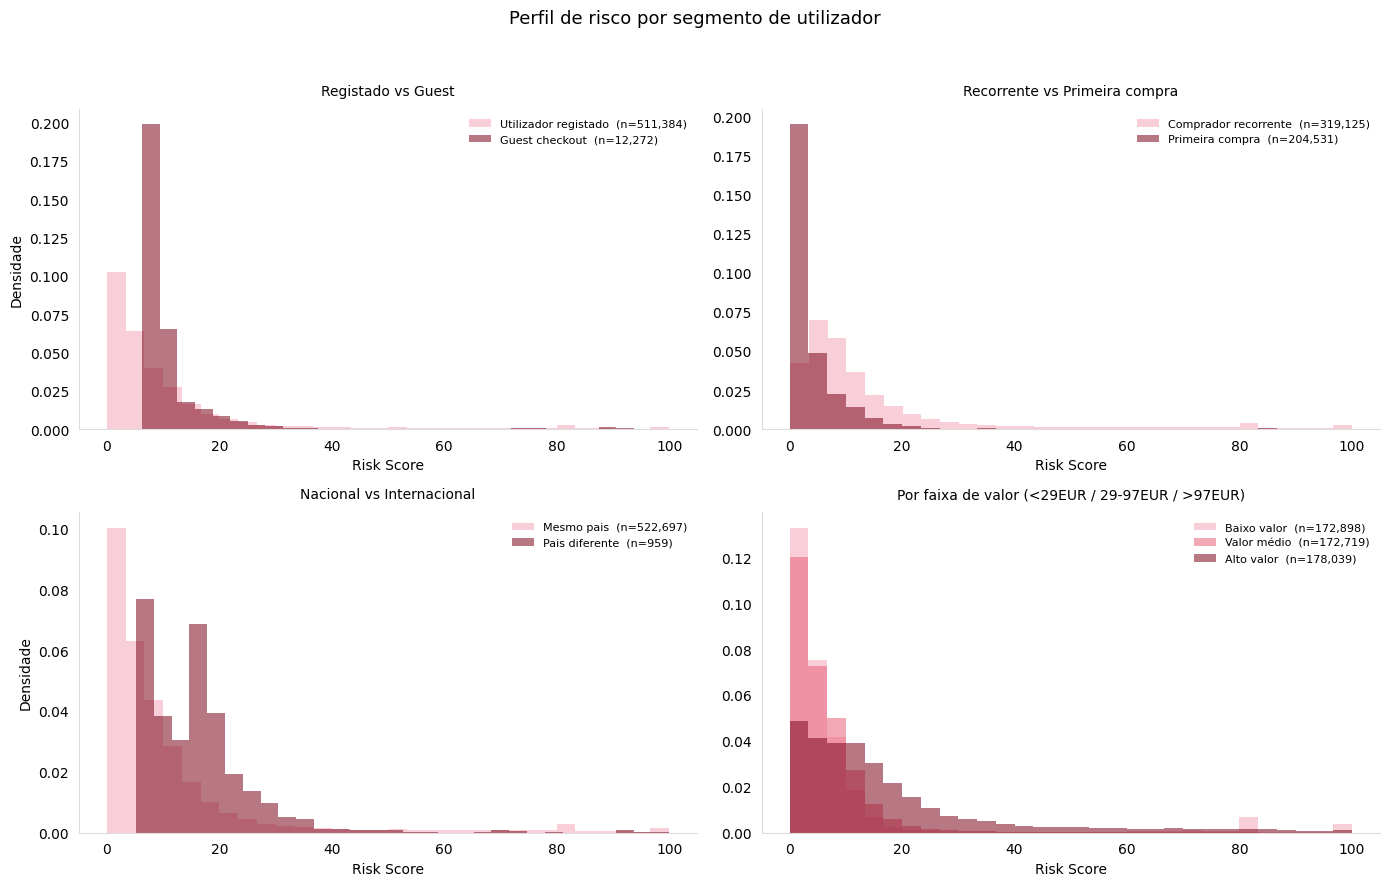

In [75]:
#Criar faixa de valor (tercis de total_amount)
_p33 =df ['total_amount'].quantile (0.33 )
_p66 =df ['total_amount'].quantile (0.66 )
df ['_value_tier']=pd .cut (df ['total_amount'],bins =[-float ('inf'),_p33 ,_p66 ,float ('inf')],labels =['Baixo valor','Valor médio','Alto valor']).astype (str ).replace ('nan',None )

fig ,axes =plt .subplots (2 ,2 ,figsize =(14 ,9 ))
axes =axes .flatten ()

segments =[
('is_guest',{0 :'Utilizador registado',1 :'Guest checkout'},
'Registado vs Guest',
{'Utilizador registado':'#f4a7b9','Guest checkout':'#7d0a1e'}),

('is_first_order',{0 :'Comprador recorrente',1 :'Primeira compra'},
'Recorrente vs Primeira compra',
{'Comprador recorrente':'#f4a7b9','Primeira compra':'#7d0a1e'}),

('cross_border_order',{0 :'Mesmo pais',1 :'País diferente'},
'Nacional vs Internacional',{'Mesmo pais':'#f4a7b9','País diferente':'#7d0a1e'}),

('_value_tier',
{'Baixo valor':'Baixo valor','Valor médio':'Valor médio','Alto valor':'Alto valor'},
f'Por faixa de valor (<{_p33 :.0f}EUR / {_p33 :.0f}-{_p66 :.0f}EUR / >{_p66 :.0f}EUR)',
{'Baixo valor':'#f4a7b9','Valor médio':'#e8637a','Alto valor':'#7d0a1e'}),
]

for idx ,(ax ,(col ,val_map ,title ,colors ))in enumerate (zip (axes ,segments )):
    if col not in df .columns :
        ax .set_visible (False )
        continue 

    for val ,label in val_map .items ():
        if isinstance (val ,str ):
            s =df [df [col ].astype (str )==val ]['risk_score']
        else :
            s =df [df [col ].fillna (-1 )==val ]['risk_score']
        if len (s )>0 :
            ax .hist (s ,bins =30 ,alpha =0.55 ,label =f'{label }  (n={len (s ):,})',
            color =colors [label ],density =True )

    ax .set_title (title ,fontsize =10 ,fontweight ='500',pad =10 )
    ax .set_xlabel ('Risk Score')
    ax .set_ylabel ('Densidade'if idx %2 ==0 else '')
    ax .grid (False )
    ax .spines ['top'].set_visible (False )
    ax .spines ['right'].set_visible (False )
    ax .spines ['left'].set_color ('#dddddd')
    ax .spines ['bottom'].set_color ('#dddddd')
    ax .tick_params (left =False ,bottom =False )
    ax .legend (fontsize =8 ,frameon =False ,loc ='upper right')

fig .suptitle ('Perfil de risco por segmento de utilizador',fontsize =13 ,fontweight ='500')
plt .tight_layout (rect =[0 ,0 ,1 ,0.95 ])

if CONFIG ['save_figures']:
    plt .savefig (f'{CONFIG ["output_prefix"]}_segmentos.png',dpi =150 ,bbox_inches ='tight')

plt .show ()

df =df .drop (columns =['_value_tier'],errors ='ignore')

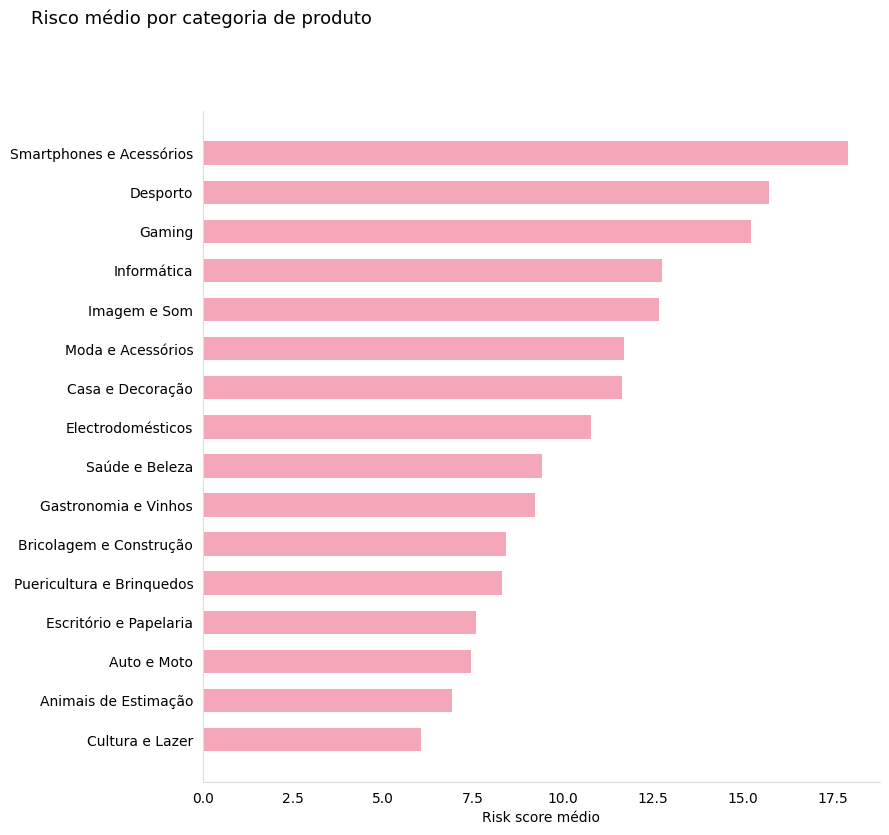

In [76]:
cat_col =next ((c for c in ['categoria_pai','categoria_pai_content']if c in df .columns ),None )

if cat_col :
    cat_risk =(
    df .groupby (cat_col )['risk_score']
    .agg (['mean','count'])
    .rename (columns ={'mean':'avg_risk','count':'n'})
    .query ('n >= 20')
    .sort_values ('avg_risk',ascending =True )
    )

    fig ,ax =plt .subplots (figsize =(9 ,max (4 ,len (cat_risk )*0.5 )))
    ax .barh (cat_risk .index ,cat_risk ['avg_risk'],color ='#f4a7b9',height =0.6 )

    ax .set_xlabel ('Risk score médio')
    ax .set_ylabel ('')

    ax .grid (False )
    ax .spines ['top'].set_visible (False )
    ax .spines ['right'].set_visible (False )
    ax .spines ['left'].set_color ('#dddddd')
    ax .spines ['bottom'].set_color ('#dddddd')
    ax .tick_params (left =False ,bottom =False )

    fig .text (0.04 ,1.02 ,'Risco médio por categoria de produto',fontsize =13 ,fontweight ='500')

    plt .tight_layout (rect =[0 ,0 ,1 ,0.93 ])

    if CONFIG ['save_figures']:
        plt .savefig (f'{CONFIG ["output_prefix"]}_categorias.png',dpi =150 ,bbox_inches ='tight')

    plt .show ()

## 20. Diagnóstico Final e Outputs Locais

Esta parte final fecha a análise antes da publicação operacional. A sequência passa por quatro passos: diagnóstico agregado, sanity checks, exemplos de casos mais suspeitos e geração dos ficheiros locais de apoio.

A ideia é separar claramente o que serve para validação analítica do que já segue para exportação e consumo operacional.


In [77]:
print_diagnostics (df )

 Total de transações analisadas       : 523,656

 Baixo          481,385  ( 91.9%)     81568.1 k EUR
 Moderado        21,106  (  4.0%)     14242.2 k EUR
 Alto             9,841  (  1.9%)      6215.1 k EUR
 Crítico         11,324  (  2.2%)      8038.9 k EUR

Aprovação automática : 91.9%
Revisão manual + bloqueio : 4.0%
Bloqueio automático : 2.2%
Hard block rules disparadas : 126
Anomalias detectadas pelo ML : 12,923  (2.5%)
Risk score médio : 11.3
Mediana do risk score : 6.0
Risk score p95 : 50.5


In [78]:
print ('Sanity Checks')

first_orders =df [df ['prev_total_orders']==0 ].copy ()
print ('\nPrimeiras ordens')
print (f'N primeiras ordens: {len (first_orders ):,}')
print (f'prev_avg_order_amount nulos: {first_orders ["prev_avg_order_amount"].isna ().mean ()*100 :.1f}%')
print (f'order_amount_vs_avg == 1: {(first_orders ["order_amount_vs_avg"]==1 ).mean ()*100 :.1f}%')
if 'prev_failures_1d'in first_orders .columns :
    print (f'prev_failures_1d == 0: {(first_orders ["prev_failures_1d"]==0 ).mean ()*100 :.1f}%')
if 'prev_failures_7d'in first_orders .columns :
    print (f'prev_failures_7d == 0: {(first_orders ["prev_failures_7d"]==0 ).mean ()*100 :.1f}%')
if 'prev_failures_30d'in first_orders .columns :
    print (f'prev_failures_30d == 0: {(first_orders ["prev_failures_30d"]==0 ).mean ()*100 :.1f}%')

Sanity Checks

Primeiras ordens
N primeiras ordens: 204,531
prev_avg_order_amount nulos: 100.0%
order_amount_vs_avg == 1: 100.0%
prev_failures_1d == 0: 100.0%
prev_failures_7d == 0: 100.0%
prev_failures_30d == 0: 100.0%


In [79]:
#Hard block rate
print (f' Hard block rate: {df ["hard_block_rule"].mean ()*100 :.2f}%')

 Hard block rate: 0.02%


In [80]:
#Top 20 transações mais suspeitas
cols_alert =[
'id_order_seller','createdAt','customer_on_purchase_userId',
'total_amount','risk_score','risk_level','recommended_action',
'rules_triggered_count','triggered_rules',
'account_age_days','is_guest','cross_border_order',
'prev_failures_1d','prev_failures_7d','prev_failures_30d',
'hard_block_rule',
]

cols_alert =[c for c in cols_alert if c in df .columns ]

print ('Top 20 Transações Mais Suspeitas')
display (df .nlargest (20 ,'risk_score')[cols_alert ])

Top 20 Transações Mais Suspeitas


,createdAt,customer_on_purchase_userId,total_amount,risk_score,risk_level,recommended_action,rules_triggered_count,triggered_rules,account_age_days,is_guest,cross_border_order,prev_failures_1d,prev_failures_7d,prev_failures_30d,hard_block_rule
4024,2025-02-08 12:36:11+00:00,78890bf5-a5b4-42df-8852-b883056569c1,2073.820,100.000,Crítico,Bloqueio Automático,4,Falhas de pagamento nas últimas 24h | Valor an...,187.000,0,0.000,8.000,8.000,8.000,0
4389,2025-03-19 12:14:37+00:00,741779e4-4516-4e44-b42b-aeeb5c5a81ef,2779.460,100.000,Crítico,Bloqueio Automático,4,Valor anómalo face à categoria | Acima do p95 ...,36.000,0,0.000,3.000,3.000,3.000,0
4405,2025-03-20 22:49:07+00:00,24f22d42-1f01-413b-bd57-64a647919892,2308.220,100.000,Crítico,Bloqueio Automático,4,Valor anómalo face à categoria | Acima do p95 ...,119.000,0,0.000,6.000,6.000,6.000,0
9540,2025-05-09 13:12:19+00:00,a7db5c06-c4ab-4c89-abe2-5e36f54553dd,184.700,100.000,Crítico,Bloqueio Automático,4,Desvio elevado do padrão pessoal | Falhas de p...,1622.000,0,0.000,10.000,10.000,10.000,0
14833,2025-03-30 01:09:02+00:00,2d640412-a7ca-4eb9-829e-8e8216994f82,2406.450,100.000,Crítico,Bloqueio Automático,5,Valor anómalo face à categoria | Acima do p95 ...,1.000,0,0.000,3.000,3.000,3.000,0
14911,2025-04-25 11:34:05+00:00,c029996d-9e3e-4a36-9e67-a6a82ac79c99,2596.580,100.000,Crítico,Bloqueio Automático,7,Conta recente + frequência + falhas | Frequênc...,2.000,0,0.000,12.000,12.000,12.000,0
14916,2025-04-25 14:16:43+00:00,c029996d-9e3e-4a36-9e67-a6a82ac79c99,1814.370,100.000,Crítico,Bloqueio Automático,5,Conta recente + frequência + falhas | Frequênc...,2.000,0,0.000,20.000,20.000,20.000,0
14917,2025-04-25 14:18:08+00:00,c029996d-9e3e-4a36-9e67-a6a82ac79c99,1814.370,100.000,Crítico,Bloqueio Automático,5,Conta recente + frequência + falhas | Frequênc...,2.000,0,0.000,21.000,21.000,21.000,0
14918,2025-04-25 14:19:50+00:00,c029996d-9e3e-4a36-9e67-a6a82ac79c99,1814.370,100.000,Crítico,Bloqueio Automático,5,Conta recente + frequência + falhas | Frequênc...,2.000,0,0.000,22.000,22.000,22.000,0
15348,2025-12-17 01:17:26+00:00,f76a6670-d3dc-416e-9bf6-72e819441f22,660.500,100.000,Crítico,Bloqueio Automático,5,Conta recente + frequência + falhas | Falhas d...,1.000,0,0.000,71.000,71.000,71.000,0


### Exportações Locais

Os blocos seguintes geram os artefactos locais usados para auditoria, análise detalhada e consumo em ferramentas externas.

In [81]:
export_outputs (df ,CONFIG )

Exportado: c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\analysis_charts\kk_fraude_full_results.xlsx  (523,656 linhas)
Exportado: c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\analysis_charts\kk_fraude_alerts.xlsx (21,165 alertas)
Exportado: c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\analysis_charts\kk_fraude_summary.xlsx
Exportado: c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\analysis_charts\kk_fraude_top50.xlsx


In [82]:
output_cols =[c for c in DASHBOARD_COLS if c in df .columns ]

if CONFIG ['mode']=='test':
    df_export =df [df ['createdAt']>=cutoff ][output_cols ].copy ()

    for col in df_export .select_dtypes (include =['datetimetz']).columns :
        df_export [col ]=df_export [col ].dt .tz_localize (None )

    df_export .to_parquet ('kk_fraude_resultados.parquet',index =False )
    print (f'Exportado: kk_fraude_resultados.parquet  ({len (df_export ):,} linhas, {len (df_export .columns )} colunas)')

else :
    PROD_DIR =CONFIG .get ('production_dir','production')

    df_export =df [output_cols ].copy ()
    for col in df_export .select_dtypes (include =['datetimetz']).columns :
        df_export [col ]=df_export [col ].dt .tz_localize (None )

    written_paths =_append_production_results_by_month (df_export ,CONFIG )
    print (f'[PRODUCTION] Guardado por mes em {len (written_paths )} ficheiro(s).')

    alerts =df [df ['risk_level'].isin (['Alto','Crítico'])][output_cols ].sort_values ('risk_score',ascending =False )
    if len (alerts )>0 :
        for col in alerts .select_dtypes (include =['datetimetz']).columns :
            alerts [col ]=alerts [col ].dt .tz_localize (None )
        alerts_path =os .path .join (PROD_DIR ,f'alerts_{pd .Timestamp .now ().strftime ("%Y%m%d_%H%M")}.xlsx')
        alerts .to_excel (alerts_path ,index =False )
        print (f'[PRODUCTION] {len (alerts ):,} alertas guardados: {alerts_path }')
    else :
        print ('[PRODUCTION] Sem novos alertas nesta execução.')

alerts_email =df [df ['risk_level'].isin (['Alto','Crítico'])].copy ()
alerts_email =alerts_email [[c for c in output_cols if c in alerts_email .columns ]]
run_label =pd .Timestamp .now ().strftime ('%Y-%m-%d %H:%M')+(' [TEST]'if CONFIG ['mode']=='test'else ' [PROD]')
send_alert_email (alerts_email ,CONFIG ,run_label =run_label )

Exportado: kk_fraude_resultados.parquet  (128,698 linhas, 25 colunas)
Email enviado para YOUR_EMAIL@example.com  (4637 no resumo, anexo: alerts_20260426_1426.xlsx)


In [83]:
# Export CSV para Looker Studio 
#Converte o output parquet para CSV (Looker Studio não le parquet diretamente)
#Ficheiro gerado: kk_fraude_looker.csv

_csv_path ='kk_fraude_looker.csv'
_df_csv =df_export .copy ()

#Formatar datas para string (Looker le melhor sem timezone)
for _c in _df_csv .select_dtypes (include =['datetime64[ns]','datetimetz']).columns :
    _df_csv [_c ]=_df_csv [_c ].dt .strftime ('%Y-%m-%d %H:%M:%S')

    #Converter triggered_rules (lista) para string separada por virgulas
if 'triggered_rules'in _df_csv .columns :
    _df_csv ['triggered_rules']=_df_csv ['triggered_rules'].apply (
    lambda x :', '.join (x )if isinstance (x ,list )else str (x )
    )

_df_csv .to_csv (_csv_path ,index =False ,encoding ='utf-8-sig')
print (f'CSV exportado: {_csv_path }  ({len (_df_csv ):,} linhas, {len (_df_csv .columns )} colunas)')
print (f'Importa no Looker Studio via: Adicionar dados > Carregar ficheiro > CSV')


CSV exportado: kk_fraude_looker.csv  (128,698 linhas, 25 colunas)
Importa no Looker Studio via: Adicionar dados > Carregar ficheiro > CSV


## 21. Publicação Operacional e Integração

Depois dos outputs locais, o notebook prepara os ficheiros auxiliares de monitorização e a publicação em Google Sheets. 

In [84]:
if 'monthly_metrics'in globals ():
    monthly_metrics .to_csv ('kk_fraude_monthly_metrics.csv',index =False ,encoding ='utf-8-sig')
    print (f'CSV exportado: kk_fraude_monthly_metrics.csv  ({len (monthly_metrics ):,} linhas, {len (monthly_metrics .columns )} colunas)')

if CONFIG .get ('mode')=='test'and 'ml_weight_scenarios'in globals ():
    ml_weight_scenarios .to_csv ('kk_fraude_ml_weight_scenarios.csv',index =False ,encoding ='utf-8-sig')
    print (f'CSV exportado: kk_fraude_ml_weight_scenarios.csv  ({len (ml_weight_scenarios ):,} linhas)')

if CONFIG .get ('mode')=='test'and 'recent_threshold_eval'in globals ()and isinstance (recent_threshold_eval ,pd .DataFrame ):
    recent_threshold_eval .to_csv ('kk_fraude_recent_thresholds.csv',index =False ,encoding ='utf-8-sig')
    print (f'CSV exportado: kk_fraude_recent_thresholds.csv  ({len (recent_threshold_eval ):,} linhas)')


CSV exportado: kk_fraude_monthly_metrics.csv  (12 linhas, 16 colunas)
CSV exportado: kk_fraude_ml_weight_scenarios.csv  (3 linhas)
CSV exportado: kk_fraude_recent_thresholds.csv  (7 linhas)


In [85]:
SHEETS_CREDENTIALS ='google_oauth_credentials.json'
SHEETS_TOKEN ='google_token.json'
SHEET_ID ='YOUR_GOOGLE_SHEET_ID'
SHEET_TAB ='fraud_results_dashboard_teste'if CONFIG .get ('mode')=='test'else 'fraud_results_dashboard'
REVIEW_EXPORT_TAB =get_review_tab_name (CONFIG )
DASHBOARD_SCOPE ='ultima_run_exportada'

try :
    import gspread 
    from gspread_dataframe import set_with_dataframe 
except ImportError :
    subprocess .check_call ([sys .executable ,'-m','pip','install','gspread','gspread-dataframe','-q'])
    import gspread 
    from gspread_dataframe import set_with_dataframe 

SCOPES =[
'https://www.googleapis.com/auth/spreadsheets',
'https://www.googleapis.com/auth/drive.file',
]

creds =None 
if os .path .exists (SHEETS_TOKEN ):
    try :
        with open (SHEETS_TOKEN ,'rb')as _t :
            creds =pickle .load (_t )
    except Exception :
        print ('[AUTH] Token local invalido ou placeholder. Sera necessario autenticar novamente.')
        creds =None 
if not creds or not creds .valid :
    if creds and creds .expired and creds .refresh_token :
        creds .refresh (Request ())
    else :
        flow =InstalledAppFlow .from_client_secrets_file (SHEETS_CREDENTIALS ,SCOPES )
        creds =flow .run_local_server (port =0 )
    with open (SHEETS_TOKEN ,'wb')as _t :
        pickle .dump (creds ,_t )

gc =gspread .authorize (creds )
sh =gc .open_by_key (SHEET_ID )

try :
    ws =sh .worksheet (SHEET_TAB )
    ws .clear ()
except gspread .exceptions .WorksheetNotFound :
    ws =sh .add_worksheet (title =SHEET_TAB ,rows =1 ,cols =1 )

_df_gs =df_export .copy ()

for _c in _df_gs .select_dtypes (include =['datetime64[ns]','datetimetz']).columns :
    _df_gs [_c ]=_df_gs [_c ].dt .strftime ('%Y-%m-%d %H:%M:%S')

if 'triggered_rules'in _df_gs .columns :
    _df_gs ['triggered_rules']=_df_gs ['triggered_rules'].apply (lambda x :', '.join (x )if isinstance (x ,list )else str (x ))

_run_ts =pd .Timestamp .now (tz ='Europe/Lisbon').strftime ('%Y-%m-%d %H:%M:%S %Z')
set_with_dataframe (ws ,_df_gs ,row =1 ,include_index =False )

print (f'Google Sheet atualizada: {len (_df_gs ):,} linhas, {len (_df_gs .columns )} colunas; atualizado em {_run_ts }')
print (f'Separador dashboard: {SHEET_TAB }')
print ('Dashboard exportada: última run/export atual')

_df_review =df .copy ()
_df_review ['risk_level']=_df_review ['risk_level'].apply (_normalise_risk_level_label )
_df_review =_df_review [_df_review ['risk_level'].isin (['Alto','Crítico'])].copy ()
write_alerts_to_review_sheet (_df_review ,gc ,SHEET_ID ,config =CONFIG )
print (f'Separador review manual: {REVIEW_EXPORT_TAB }')
print (f'Link: https://docs.google.com/spreadsheets/d/{SHEET_ID }')


Google Sheet atualizada: 42,761 linhas, 25 colunas
Separador dashboard: fraud_results_dashboard_teste
Janela exportada: últimos 30 dias
[REVIEW] Indice local inicializado a partir da sheet (21,408 casos).
[REVIEW] Todos os casos ja estao no índice local para 'fraud_review_teste'.
Separador review manual: fraud_review_teste
Link: https://docs.google.com/spreadsheets/d/YOUR_GOOGLE_SHEET_ID


## 22. Guia Operacional do Feedback Loop

Esta secção explica o ciclo completo para quem nunca usou o sistema: gerar artefactos em modo testeee, correr produção, rever casos no Google Sheets e incorporar essas decisões na próxima calibração.

### 1. Primeira configuração

O notebook deve ficar normalmente com `CONFIG['mode'] == 'test'`. Este modo serve para análise, validação, ajuste de pesos e geração dos artefactos que a produção vai usar.

Depois de correr o notebook em modo testeee, os artefactos ficam em `production/`: modelo Isolation Forest, medianas, percentis e ficheiros auxiliares. 
A produção operacional usa estes ficheiros; não recalcula pesos nem re-treina o modelo.

### 2. Correr produção

A produção deve ser executada pelo script, não por Run All do notebook. 
Exemplo para testar as últimas 24h ancoradas no máximo `createdAt` da amostra:

```powershell
cd "C:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod"
py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb" --ignore-last-run --first-run-hours 24
```

Em produção real, sem simular primeira execução, usar apenas:

```powershell
py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb"
```

Cada execução de produção faz scoring com os artefactos existentes, atualiza dashboard, escreve casos novos em `fraud_review`, atualiza `fraud_review_history` e sincroniza as decisões já preenchidas para `production/review_decisions_store/`. A produção não altera pesos nem o modelo.

### 3. Rever casos no Google Sheets

Os casos operacionais aparecem no separador `fraud_review`. As colunas a preencher manualmente são:

- `decision`: escolher `fraude_confirmada`, `falso_positivo` ou `inconclusivo`.
- `tipo_fraude`: opcional; usar `bot`, `card_testing`, `account_takeover`, `cartao_roubado`, `roubo_identidade` ou `outro`.
- `reviewer`: nome ou identificador de quem reviu.
- `notas`: comentario livre.

O separador tem dropdowns nas colunas principais. Mesmo assim, o codigo tambem normaliza entradas comuns como `fraude confirmada` para `fraude_confirmada`.

### 4. Sincronizar decisões sem correr produção

Para testar se as decisões foram lidas corretamente sem fazer scoring, usar:

```powershell
py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb" --sync-review-only
```

O output esperado inclui uma linha do tipo `[REVIEW] X decisões válidas no histórico anual`. Os ficheiros ficam em `production/review_decisions_store/review_decisions_YYYY.parquet`.

### 5. Incorporar feedback nos pesos

O ajuste de pesos acontece quando se corre o notebook em `mode='test'`. Antes de gerar novos artefactos, o notebook lê por defeito o separador real `fraud_review`, sincroniza o histórico e chama `update_weights_from_feedback(...)`.

Isto significa: preencher decisões em `fraud_review`, correr o notebook em modo testeee, validar os resultados, e só depois usar os novos artefactos em produção.

Para usar deliberadamente a review de teste, chamar explicitamente `review_source='test'`. Sem isso, a leitura de feedback usa sempre `fraud_review`.


In [86]:
# Feedback loop: comandos uteis
#
# Ler decisões reais de fraud_review e sincronizar para ficheiros anuais:
# df_reviews = read_review_decisions(gc, SHEET_ID, config=CONFIG)
#
# Ler deliberadamente a review de teste:
# df_reviews_teste = read_review_decisions(gc, SHEET_ID, config=CONFIG, review_source='test')
#
# Ajustar pesos manualmente com a review real:
# new_weights = update_weights_from_feedback(CONFIG, gc, SHEET_ID, review_source='production')
# CONFIG['rule_weights'] = new_weights
#
# Ajustar pesos manualmente com a review de teste:
# new_weights_teste = update_weights_from_feedback(CONFIG, gc, SHEET_ID, review_source='test')
#
# Sincronizar decisões sem correr scoring, no terminal:
# py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb" --sync-review-only
#
# Correr produção normal, no terminal:
# py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb"
#
# Correr produção sobre as últimas 24h da sample, no terminal:
# py -3.10 .\production\run_production.py --notebook ".\fraud_p2_kk.ipynb" --ignore-last-run --first-run-hours 24
#
# Alternativa ao preenchimento na sheet - registo manual pontual:
# save_review_decision('ORD-12345', 'fraude_confirmada', 'bot', 'ana.silva', 'conta 1 dia, 3 falhas em 30s')
# save_review_decision('ORD-99999', 'falso_positivo', analyst='joao.costa', notes='cliente confirmou por telefone')


## 23. Artefactos Gerados

Esta última secção funciona como inventário dos principais outputs produzidos pelo pipeline, separados entre artefactos de análise, ficheiros operacionais e publicações externas.

- `production/results_by_month/fraud_prod_results_YYYY_MM.parquet`: resultados de produção guardados por mês, com scores, níveis de risco e flags calculadas.
- `production/last_run.json`: timestamp da última execução processada, usado para identificar novas encomendas.
- `production/review_sent_index.parquet`: índice local dos casos já enviados para revisão manual, usado para evitar duplicados sem reler toda a sheet.
- Google Sheets de dashboard: separadores de dashboard e de revisão manual, em modo de teste ou produção, conforme a configuração ativa.
- Outputs de apoio ao feedback loop: casos sinalizados para revisão, decisões manuais e base para recalibração futura do sistema.

Estes artefactos permitem operar o pipeline de forma recorrente, mantendo rastreabilidade entre dados processados, alertas gerados, revisão humana e evolução futura do modelo.

In [92]:
df_reviews = read_review_decisions(gc, SHEET_ID, config=CONFIG)
df_reviews


[REVIEW] 22 decisões válidas no histórico anual: fraude=10  falso_positivo=3  inconclusivo=9


,user_id,order_id_flag,data_ordem_flag,score_total,nivel_risco,montante,regras_ativas,decision,tipo_fraude,reviewer,notas
0,e98db4e8-d294-4e1d-9742-3f85e9f11b42,5828-947809-5385-A,2025-12-30 10:15,94.800,Critico,3245.120,Metodo de pagamento novo + alto valor | Valor ...,falso_positivo,,,
1,74f5c34d-6a59-4bba-9236-4485a9cd6999,5828-903279-7585-A,2025-12-29 21:28,93.500,Critico,5990.000,Desvio elevado do padrão pessoal | Valor muito...,inconclusivo,,,
2,474a4b81-8747-48a1-a2b3-06c217e5b845,5828-974607-3364-A,2025-12-30 12:37,89.300,Critico,5544.000,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
3,c07c2914-9005-41d5-9f16-5896b1230a7d,5828-691149-0678-A,2025-12-31 18:26,88.900,Critico,2779.600,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
4,385929d5-3333-4eac-8f03-b68f96134634,5828-932593-8891-A,2025-12-29 19:21,88.600,Critico,2796.000,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
5,85d78c12-b3a4-493e-8b74-2b621a075b45,5828-900839-7464-A,2025-12-29 21:45,87.900,Critico,2285.670,Valor anómalo face à categoria | Acima do p95 ...,inconclusivo,,,
6,a94d9938-8ed6-41a2-a0fc-a27507a1d45d,5828-561094-1931-A,2025-12-30 20:10,86.800,Critico,2010.630,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
7,3b18638a-21ec-4e05-b92c-00d3ecca6e68,5828-516322-5623-A,2025-12-31 03:39,86.000,Critico,2447.970,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
8,f272ec74-f723-4adb-ba47-c671ffbf1f9c,5828-533607-9971-A,2025-12-30 22:20,84.400,Critico,1481.900,Primeira compra + categoria nova + alto valor ...,inconclusivo,,,
9,d874fabc-18ea-4af4-9f8a-d6b898dae731,5828-694013-8323-A,2025-12-31 19:14,82.000,Critico,1607.490,Valor anómalo face à categoria | Acima do p95 ...,inconclusivo,,,


In [93]:
new_weights = update_weights_from_feedback(CONFIG, gc, SHEET_ID, review_source='production')
new_weights


[REVIEW] 22 decisões válidas no histórico anual: fraude=10  falso_positivo=3  inconclusivo=9
[WEIGHTS] Pesos originais guardados em c:\Users\Inês\Desktop\PG ISAG\Projeto Final\Cod\production\original_weights.json
[WEIGHTS] Nenhum peso alterado (lift ~1.0 ou amostras insuficientes).


{'rule_new_account_guest_highval': 25,
 'rule_new_account_freq_failures': 15,
 'rule_freq_guest_highval': 25,
 'rule_freq_highval_new_account': 15,
 'rule_unusual_amount_zscore': 10,
 'rule_payment_failures_24h': 25,
 'rule_payment_failures_30d': 7,
 'rule_multi_payment_window': 8,
 'rule_new_payment_method_highval': 10,
 'rule_amount_above_prev_max': 20,
 'rule_first_order_new_category_highval': 20,
 'rule_unusual_amount_category': 12,
 'rule_above_cohort_p95_highval': 12,
 'rule_mp_new_account_highval': 28,
 'rule_mp_all_items_highval': 20,
 'rule_cart_price_manipulation': 30,
 'rule_cart_stock_exceeded': 10,
 'rule_bulk_highval': 15,
 'rule_name_mismatch_mp_highval': 20,
 'rule_name_mismatch_new_account_highval': 6,
 'rule_seller_cancellations': 18,
 'rule_mp_low_commission_highval': 23,
 'rule_bnpl_new_account': 23,
 'rule_card_testing': 23,
 'rule_multi_merchant_24h': 20,
 'rule_merchant_high_cancel_rate_burst': 6,
 'rule_user_merchant_concentration': 15,
 'rule_shared_delivery_ad